In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
import math
import re
from matplotlib.patches import Patch

In [2]:
# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)
project_root = os.path.abspath(os.path.join(".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src import utils, analytics, plotting

In [3]:
scenario_colors = {
    "NT": "#1f77b4",
    "GA": "#ff7f0e",
    "DE": "#2ca02c",
    "Average": "#7f7f7f",
}

# Define a consistent color palette for cost categories
category_colors = {
    "Invest Gen": "#b20000",  # dark red
    "Invest Bat": "#0072b2",  # blue
    "Invest Tx": "#009e73",  # green
    "Prod Cost": "#f0e442",  # yellow
    "CO₂ Cost": "#d55e00",  # orange
    "Load Shedding Cost": "#cc79a7",  # magenta
    "Curtailment Cost": "#56b4e9",  # light blue
}

In [4]:
ROOT_FOLDER = os.path.dirname(os.getcwd())
RUNS_FOLDER = os.path.join(ROOT_FOLDER, "runs")
SINGLE_RUNS_FOLDER = os.path.join(RUNS_FOLDER, "single_runs")
BATCH_RUNS_FOLDER = os.path.join(RUNS_FOLDER, "batch_runs")
TEST_BATCH_RUNS_FOLDER = os.path.join(BATCH_RUNS_FOLDER, "test")

In [5]:
# batch_name = "batch_128_4_4_4core_bat_and_no_bat_ef05"
# batch_folder = os.path.join(BATCH_RUNS_FOLDER, batch_name)

In [6]:
# batch_name = "batch_128_8_weeks_season_efs"
# batch_folder = os.path.join(BATCH_RUNS_FOLDER, batch_name)

In [7]:
batch_name = "batch_128_sv2_4_weeks_efs_ramping"
batch_folder = os.path.join(BATCH_RUNS_FOLDER, batch_name)

In [8]:
batch_folder = [os.path.join(batch_folder, f) for f in os.listdir(batch_folder)]
print(batch_folder)

['c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\batch_128_sv2_4_weeks_efs_ramping\\1_May22_Thu_h11_m56_s09-GTSEP_stochastic_v2-128_ES_PT', 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\batch_128_sv2_4_weeks_efs_ramping\\2_May22_Thu_h12_m18_s14-GTSEP_stochastic_v2-128_ES_PT', 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\batch_128_sv2_4_weeks_efs_ramping\\3_May22_Thu_h12_m42_s20-GTSEP_stochastic_v2-128_ES_PT']


In [9]:
results_folders_to_explore = batch_folder
# display_names = [f"results_{str(i)}" for i in range(len(results_folders_to_explore))]
# display_names = ["Base", "No Battery"]
# display_names = ["ef025", "ef050", "ef075"]
# display_names = ["Leakage", "No Leakage"]
display_names = ["ramp004", "ramp008", "ramp012"]
# display_names = test_display_names
MAX_COLUMNS = 2

# Alternatively explore all folders in a batch directory

In [10]:
assert len(results_folders_to_explore) == len(
    display_names
), "Number of folders and display names must match"

In [11]:
results_folders_to_explore

['c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\batch_128_sv2_4_weeks_efs_ramping\\1_May22_Thu_h11_m56_s09-GTSEP_stochastic_v2-128_ES_PT',
 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\batch_128_sv2_4_weeks_efs_ramping\\2_May22_Thu_h12_m18_s14-GTSEP_stochastic_v2-128_ES_PT',
 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\batch_128_sv2_4_weeks_efs_ramping\\3_May22_Thu_h12_m42_s20-GTSEP_stochastic_v2-128_ES_PT']

In [12]:
savefolder = os.path.join(
    ROOT_FOLDER, "data", "for_the_report", "results", "-".join(display_names)
)
os.makedirs(savefolder, exist_ok=True)

In [13]:
tables_folder = os.path.join(savefolder, "tables")
os.makedirs(tables_folder, exist_ok=True)
figures_folder = os.path.join(savefolder, "figures")
os.makedirs(figures_folder, exist_ok=True)

In [14]:
import yaml


input_data_list = []
decision_variables_list = []
model_info_list = []
generation_decision_variables_list = []
dual_variables_list = []
for folder in results_folders_to_explore:
    model_info_folder = os.path.join(folder, "model_info")
    model_info_path = os.path.join(model_info_folder, "model_info.csv")
    model_info = pd.read_csv(model_info_path)
    model_info_list.append(model_info)
    config_path = os.path.join(model_info_folder, "config.yaml")
    config = yaml.safe_load(open(config_path, "r"))
    input_data_folder = os.path.join(
        os.path.dirname(os.getcwd()), "data", "processed", config["data_folder_name"]
    )
    dual_variables_folder = os.path.join(folder, "dual_variables")
    years = config["years"]
    input_data = utils.load_multi_year_csv_files_with_week_from_folder(
        years=years, data_folder_path=input_data_folder
    )
    decision_variables_folder = os.path.join(folder, "decision_variables")
    input_data_list.append(input_data)
    decision_varables = utils.load_csv_files_from_folder_with_scenarios(
        decision_variables_folder
    )
    decision_variables_list.append(decision_varables)
    generation_decision_variable = decision_varables["generation"]
    generation_decision_variables_list.append(generation_decision_variable)
    dual_variables = utils.load_csv_files_from_folder_with_scenarios(
        dual_variables_folder
    )
    dual_variables_list.append(dual_variables)

In [15]:
def plot_total_time_by_case(model_info_list, case_labels, savefolder=None, fname=None):
    """
    Plots the total runtime (in seconds) for each case.
    """
    import matplotlib.pyplot as plt
    import os

    times = [df.loc[0, "Total Time (s)"] for df in model_info_list]
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.bar(case_labels, times)
    ax.set_ylabel("Total Time (s)", fontsize=16)
    ax.set_xticklabels(case_labels, fontsize=14)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([int(y) for y in ax.get_yticks()], fontsize=14)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()

    if savefolder:
        fname = fname or "total_runtime_by_case.png"
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")
    plt.show()


def plot_variables_constraints_by_case(
    model_info_list, case_labels, savefolder=None, fname=None
):
    """
    Plots number of variables and constraints for each case.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import os

    n_vars = [df.loc[0, "Number of Variables"] for df in model_info_list]
    n_cons = [df.loc[0, "Number of Constraints"] for df in model_info_list]

    ind = np.arange(len(case_labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 5))
    bars1 = ax.bar(ind - width / 2, n_vars, width, label="Variables")
    bars2 = ax.bar(ind + width / 2, n_cons, width, label="Constraints")

    ax.set_ylabel("Count", fontsize=16)
    ax.set_xticks(ind)
    ax.set_xticklabels(case_labels, fontsize=14)
    ax.legend(fontsize=16)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()

    if savefolder:
        fname = fname or "variables_constraints_by_case.png"
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")
    plt.show()

C:\Users\tinus\AppData\Local\Temp\ipykernel_6596\2895277814.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(case_labels, fontsize=14)


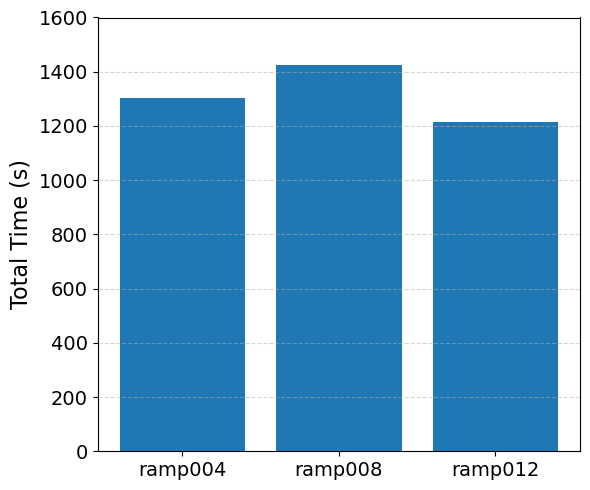

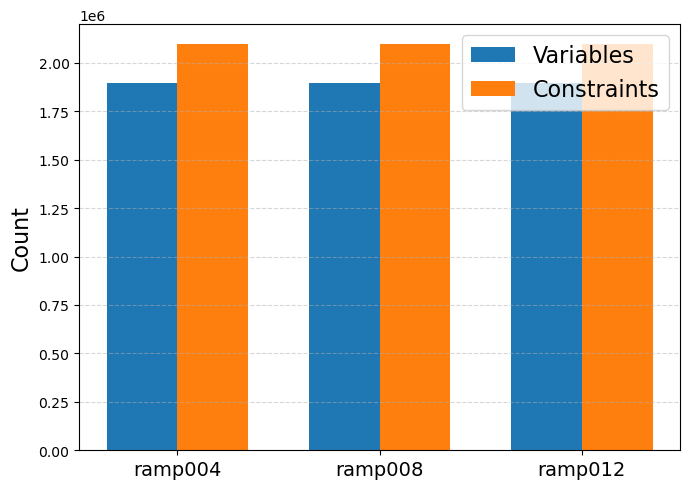

In [16]:
plot_total_time_by_case(model_info_list, display_names, savefolder=figures_folder)
plot_variables_constraints_by_case(
    model_info_list, display_names, savefolder=figures_folder
)

In [17]:
def plot_objective_values_by_case(
    model_info_list, case_labels, savefolder=None, fname=None
):
    """
    Plots the objective value for each case/run.
    Displays the relative % difference to the first case above each bar (except the first).
    """
    import matplotlib.pyplot as plt
    import os

    # Extract objective values
    objs = [df.loc[0, "Objective Value"] for df in model_info_list]
    ref_obj = objs[0]

    # Calculate relative differences (%)
    rel_diffs = [None] + [
        ((obj - ref_obj) / ref_obj * 100) if ref_obj != 0 else float("nan")
        for obj in objs[1:]
    ]

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(case_labels, objs)

    ax.set_ylabel("Objective Value", fontsize=16)
    ax.set_xticklabels(case_labels, fontsize=14)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([f"{int(y):,}" for y in ax.get_yticks()], fontsize=14)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Annotate relative differences
    for i, (bar, diff) in enumerate(zip(bars, rel_diffs)):
        if i == 0 or diff is None or (ref_obj == 0):
            continue
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height * 1.01,
            f"{diff:+.5f}%",
            ha="center",
            va="bottom",
            fontsize=14,
            color="black",
        )

    plt.tight_layout()

    if savefolder:
        fname = fname or "objective_value_by_case.png"
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")
    plt.show()

C:\Users\tinus\AppData\Local\Temp\ipykernel_6596\1037290004.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(case_labels, fontsize=14)


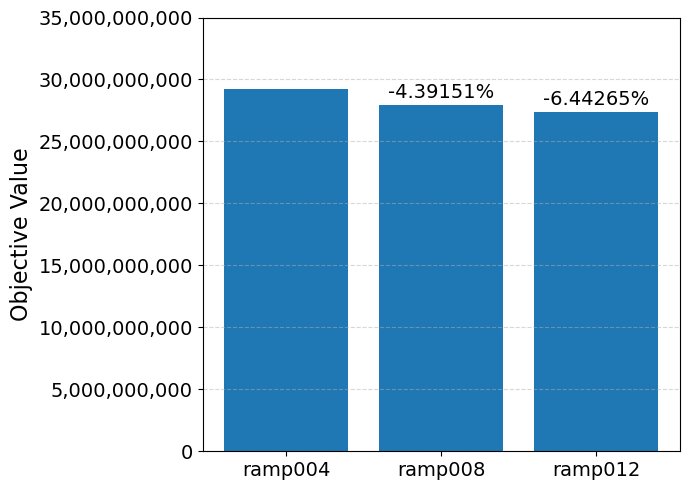

In [18]:
plot_objective_values_by_case(model_info_list, display_names, savefolder=figures_folder)

## Figures

In [19]:
import os
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


def categorize_png_files(
    results_folder: str, section: str = "figures"
) -> dict[str, list[str]]:
    """
    Walk through results/<section> and bucket all .png paths by their top-level category.
    Section can be 'figures' or 'duals'.
    """
    base_path = os.path.join(results_folder, "results", section)
    categories: dict[str, list[str]] = {}
    for root, _, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(".png"):
                full_path = os.path.join(root, file)
                rel_path = os.path.relpath(full_path, base_path)
                parts = rel_path.split(os.sep)
                category = parts[0]  # top-level folder under section
                categories.setdefault(category, []).append(rel_path)
    return categories


def display_images_by_category(
    results_folders: list[str],
    display_names: list[str],
    max_columns: int = 2,
    section: str = "figures",
) -> None:
    """
    For each category of PNGs under results/<section>, display each image side-by-side
    across the given result folders.
    """
    # Discover categories using the first run
    ref = results_folders[0]
    categorized = categorize_png_files(ref, section)

    for category, png_list in categorized.items():
        print("\n" + "=" * 80)
        print(f"Category: {category} (section: {section})")
        print("=" * 80)

        for rel_png in png_list:
            num_runs = len(results_folders)
            cols = min(max_columns, num_runs)
            rows = math.ceil(num_runs / cols)

            fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 5 * rows))
            # Normalize axes to 2D list
            if isinstance(axes, plt.Axes):
                axes = [[axes]]
            elif rows == 1:
                axes = [axes]
            flat_axes = [ax for row in axes for ax in row]

            for idx, (folder, name) in enumerate(zip(results_folders, display_names)):
                ax = flat_axes[idx]
                img_path = os.path.join(folder, "results", section, rel_png)
                if os.path.exists(img_path):
                    img = mpimg.imread(img_path)
                    ax.imshow(img)
                    ax.axis("off")
                    ax.set_title(name, fontsize=14)
                else:
                    ax.axis("off")

            # Hide any unused subplots
            for ax in flat_axes[num_runs:]:
                ax.axis("off")

            # plt.suptitle(rel_png, fontsize=14)
            plt.tight_layout()
            plt.show()
            plt.close()


Category: curtailment_by_scenario.png (section: figures)


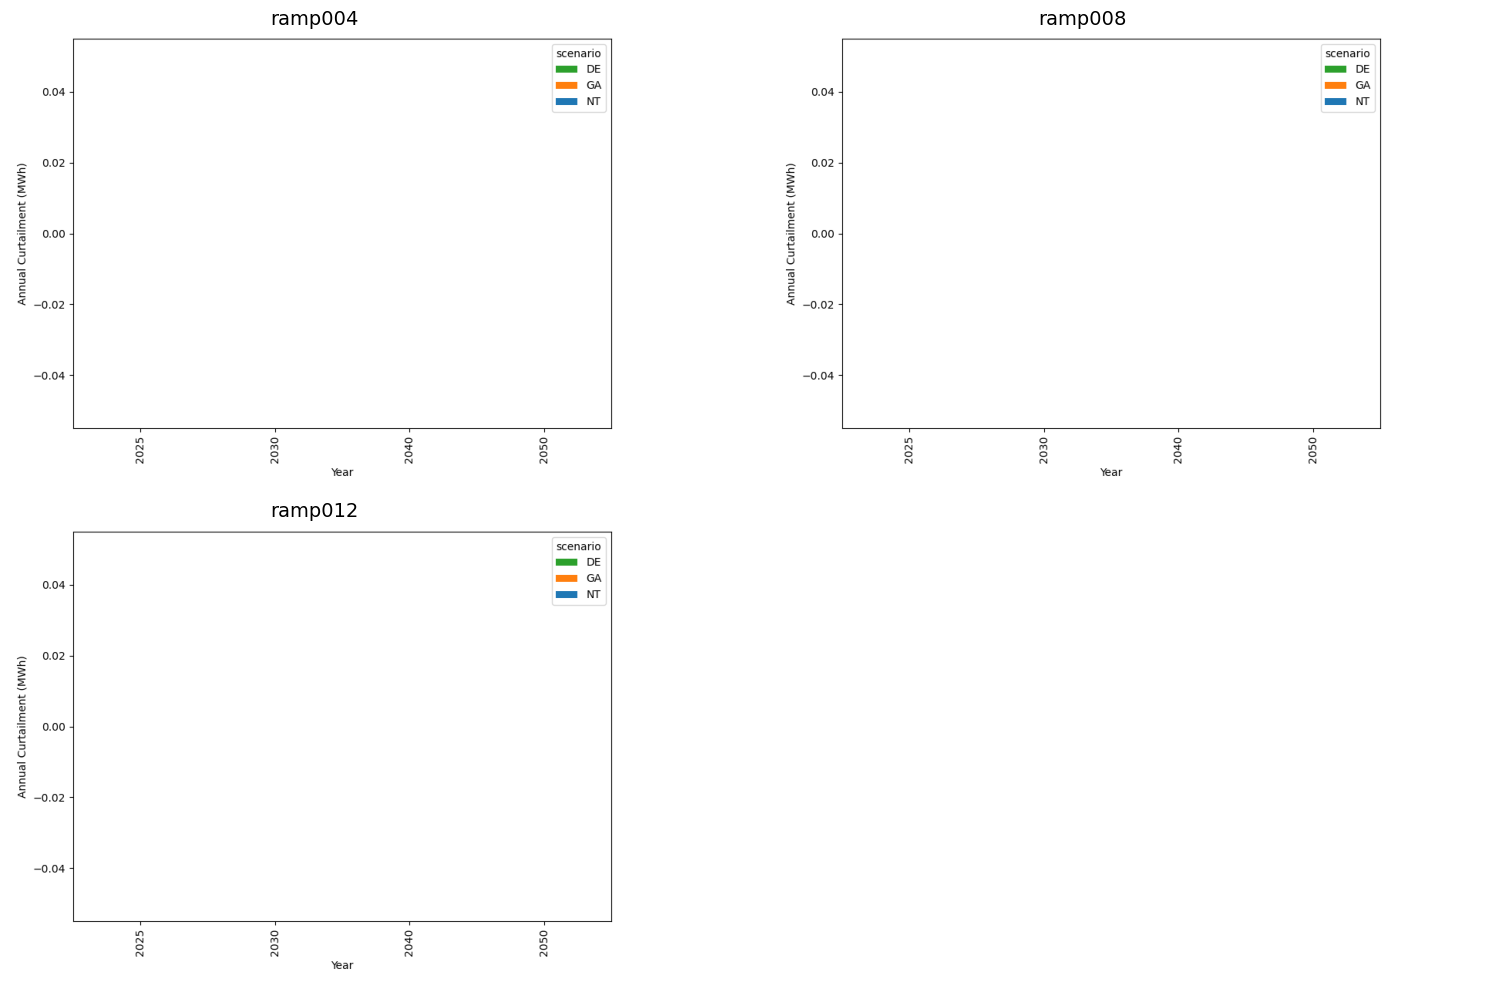


Category: load_shedding_by_scenario.png (section: figures)


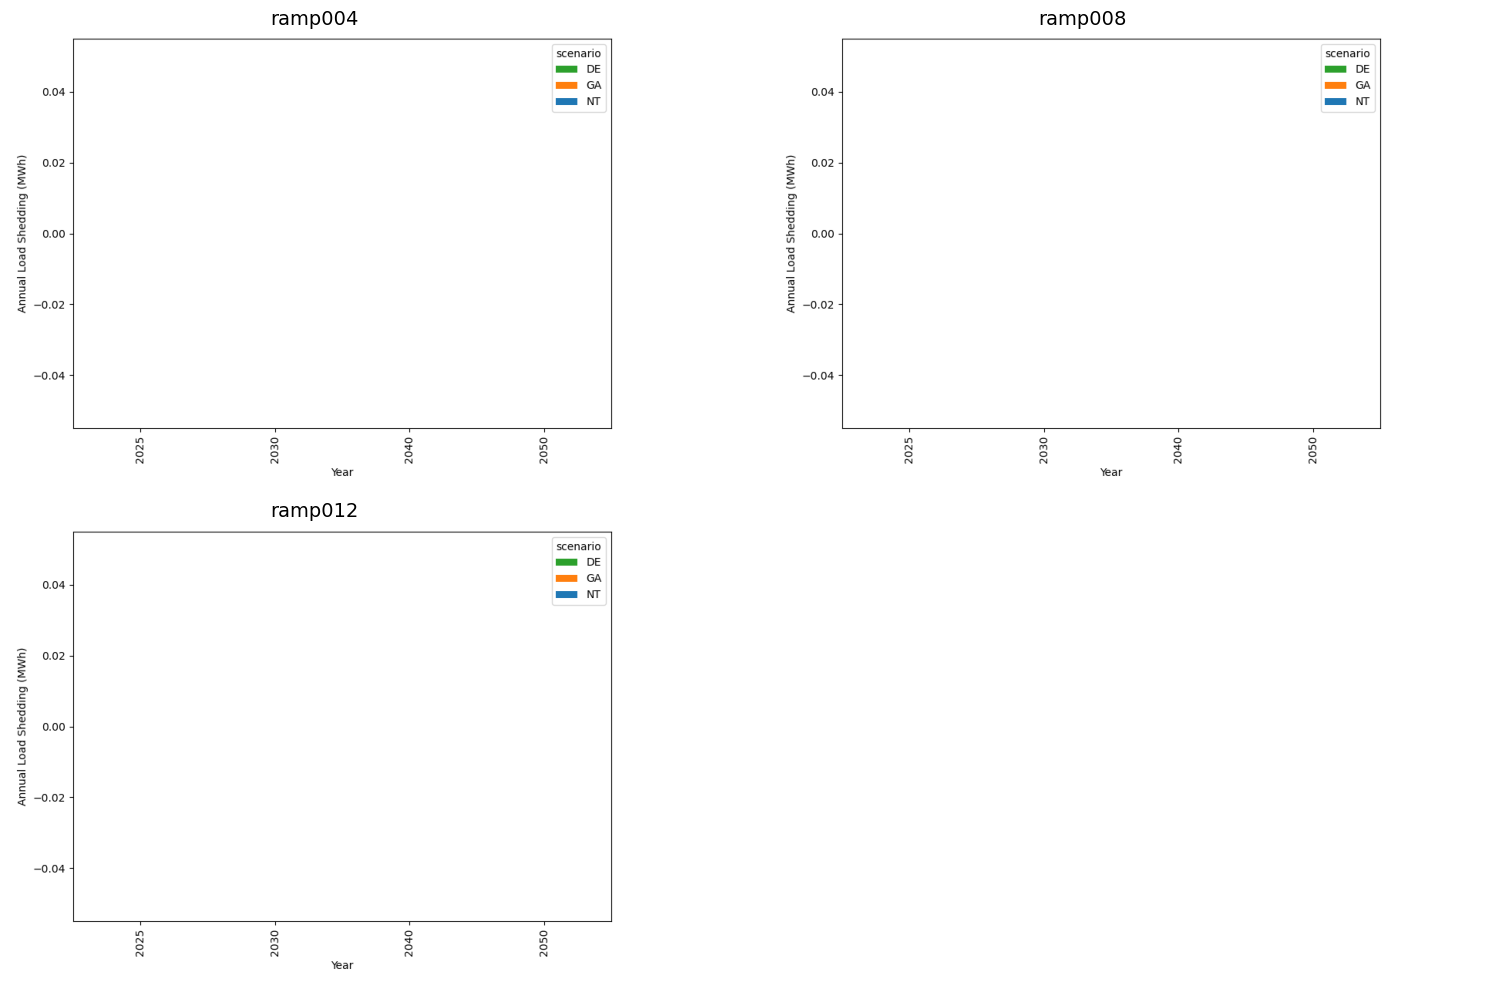


Category: batteries (section: figures)


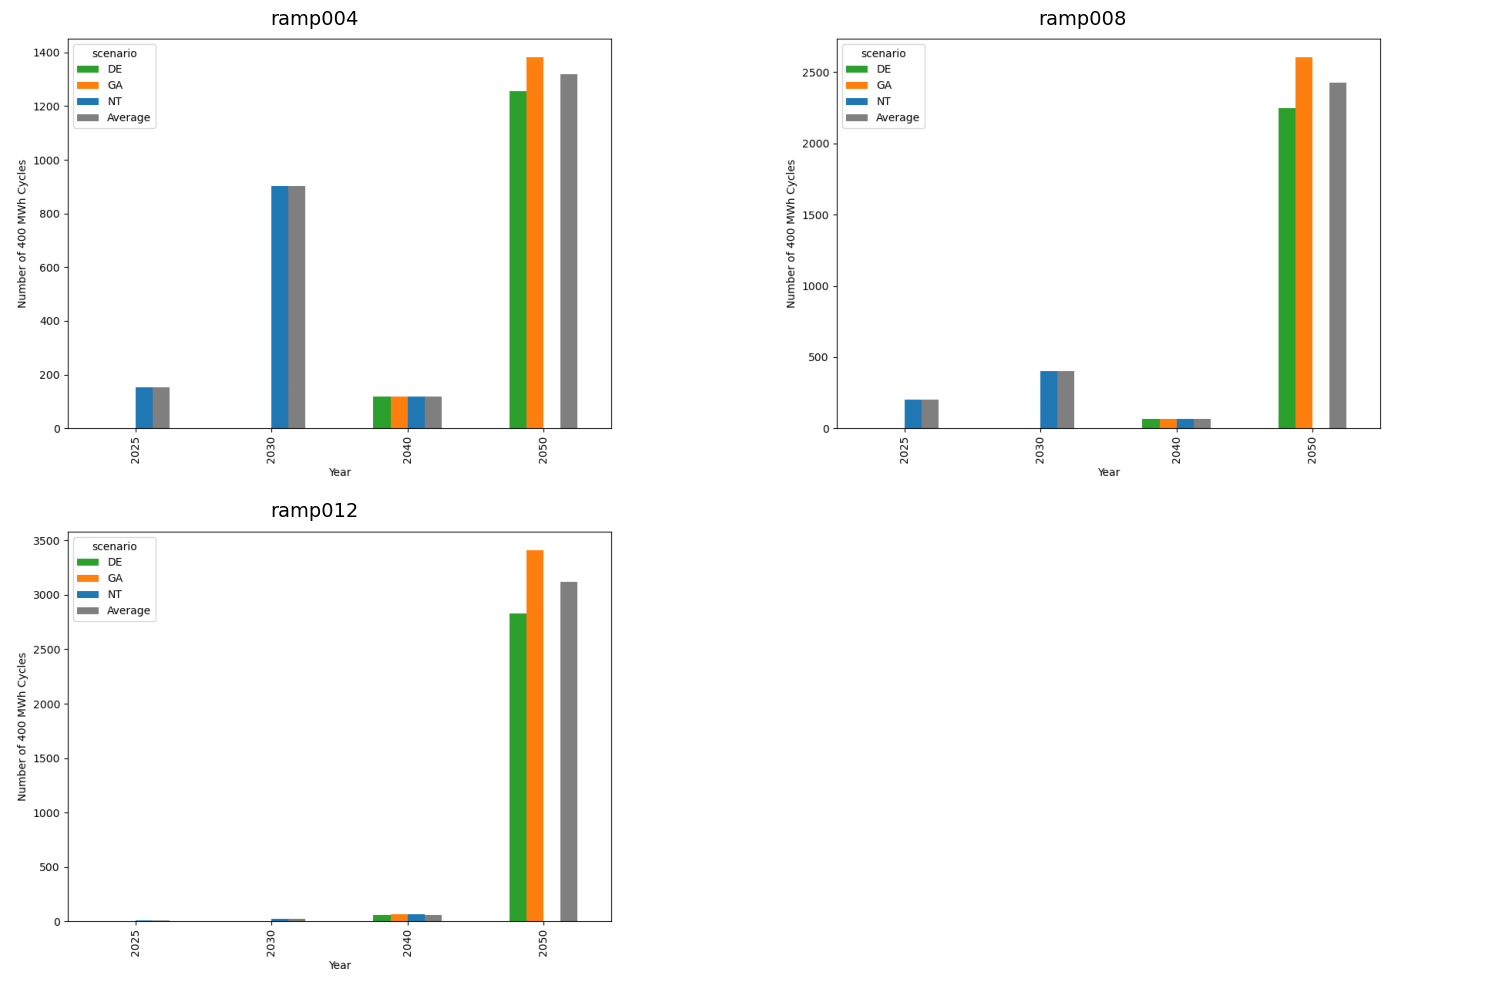

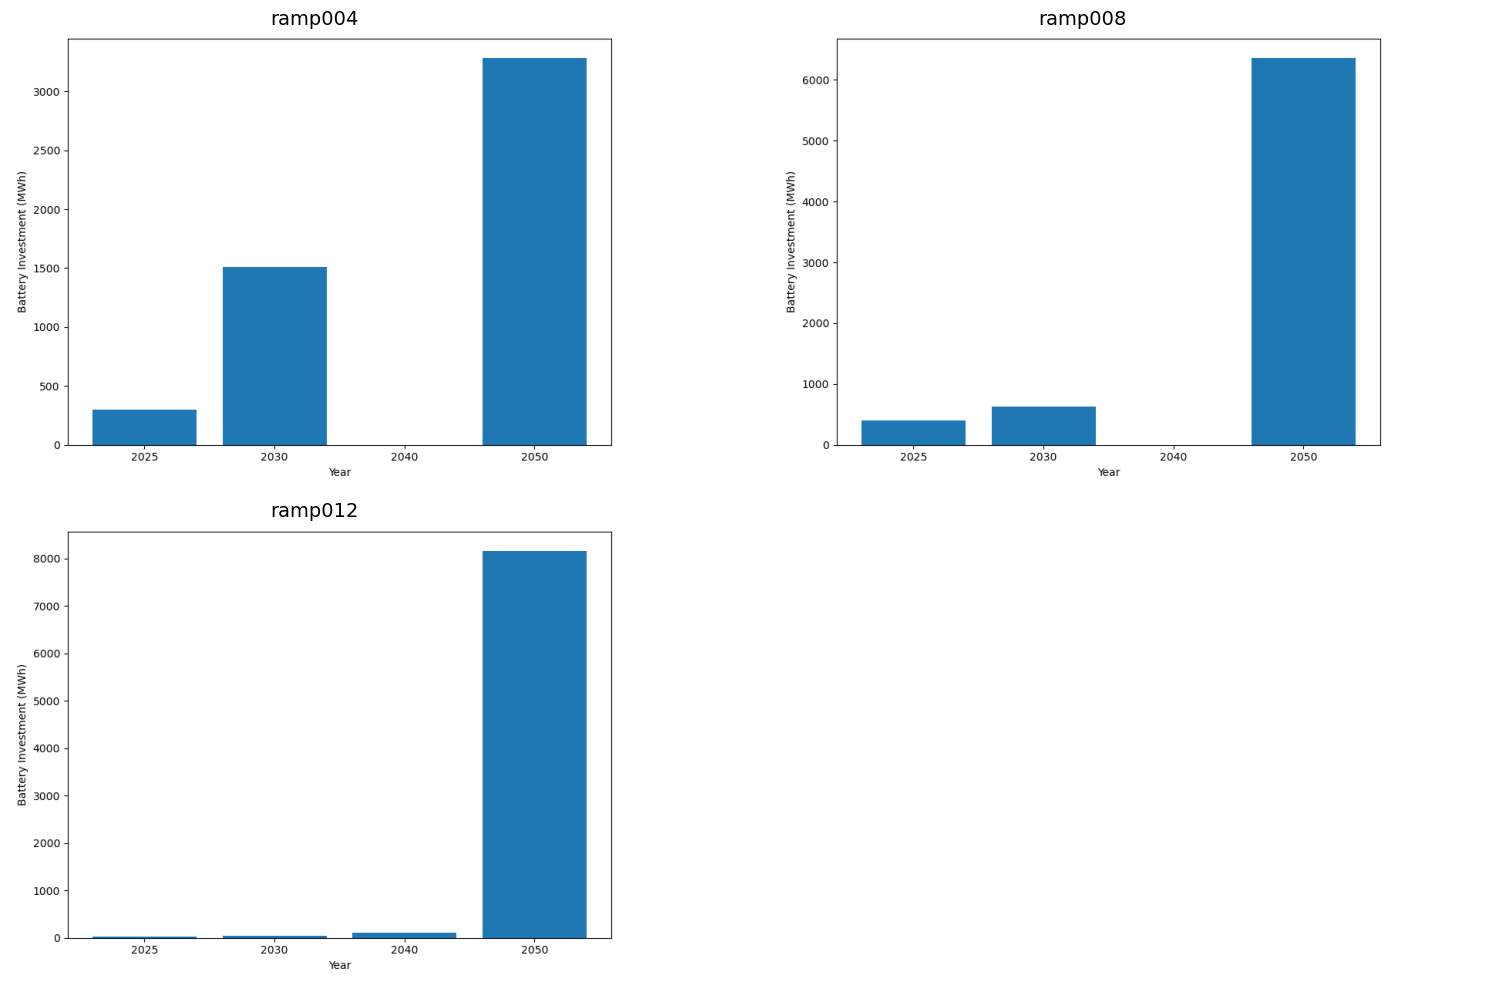

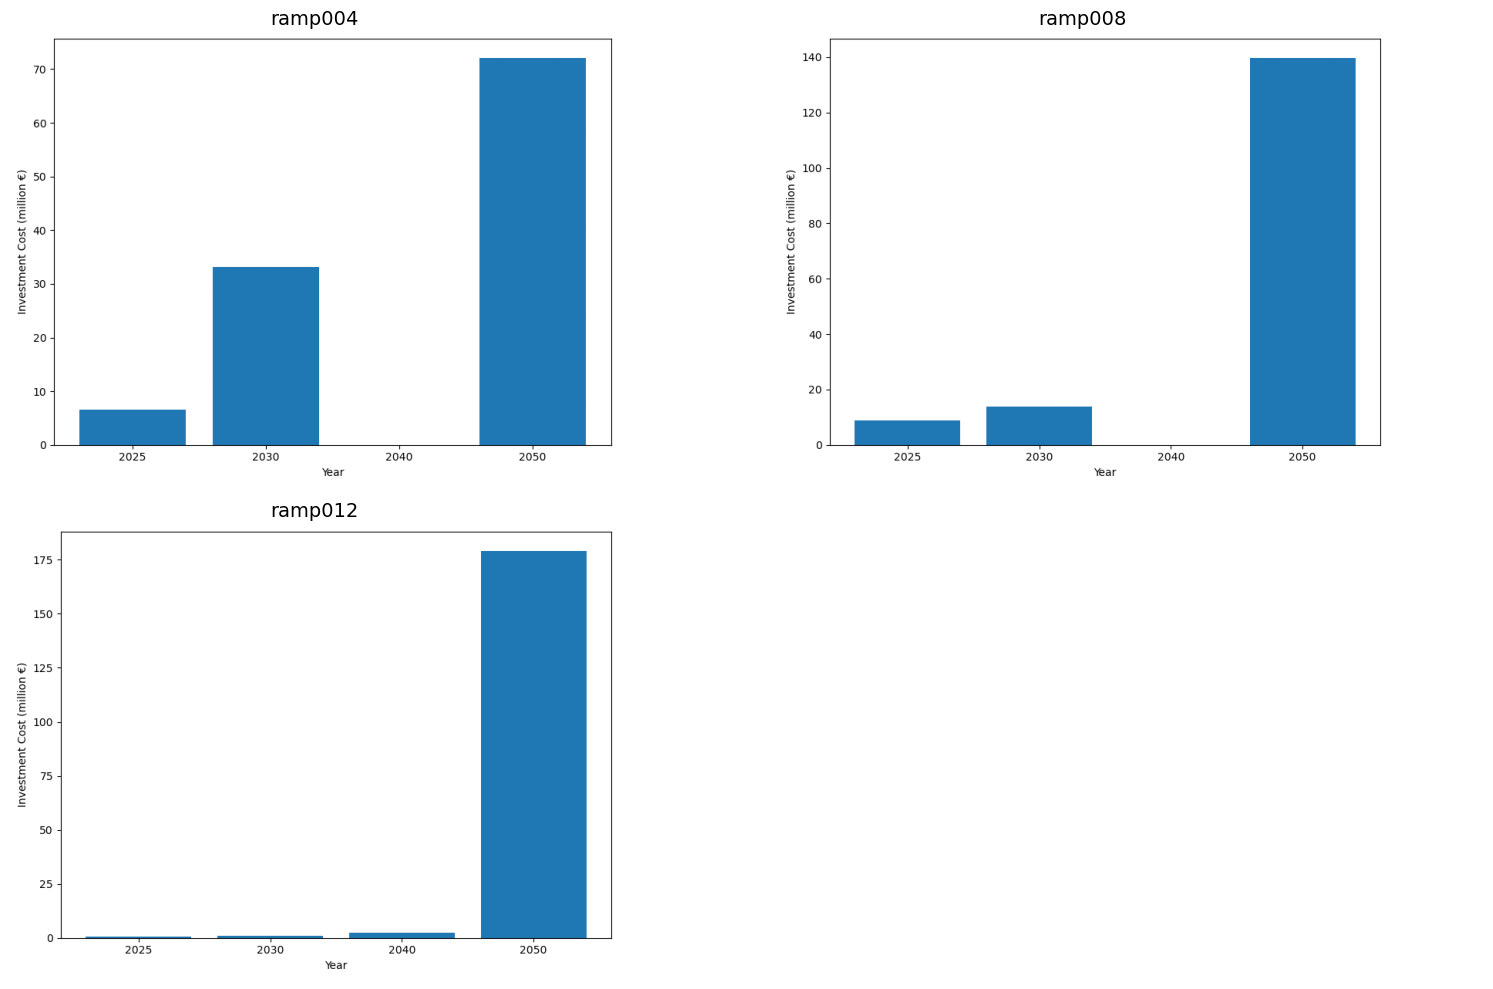


Category: branches (section: figures)


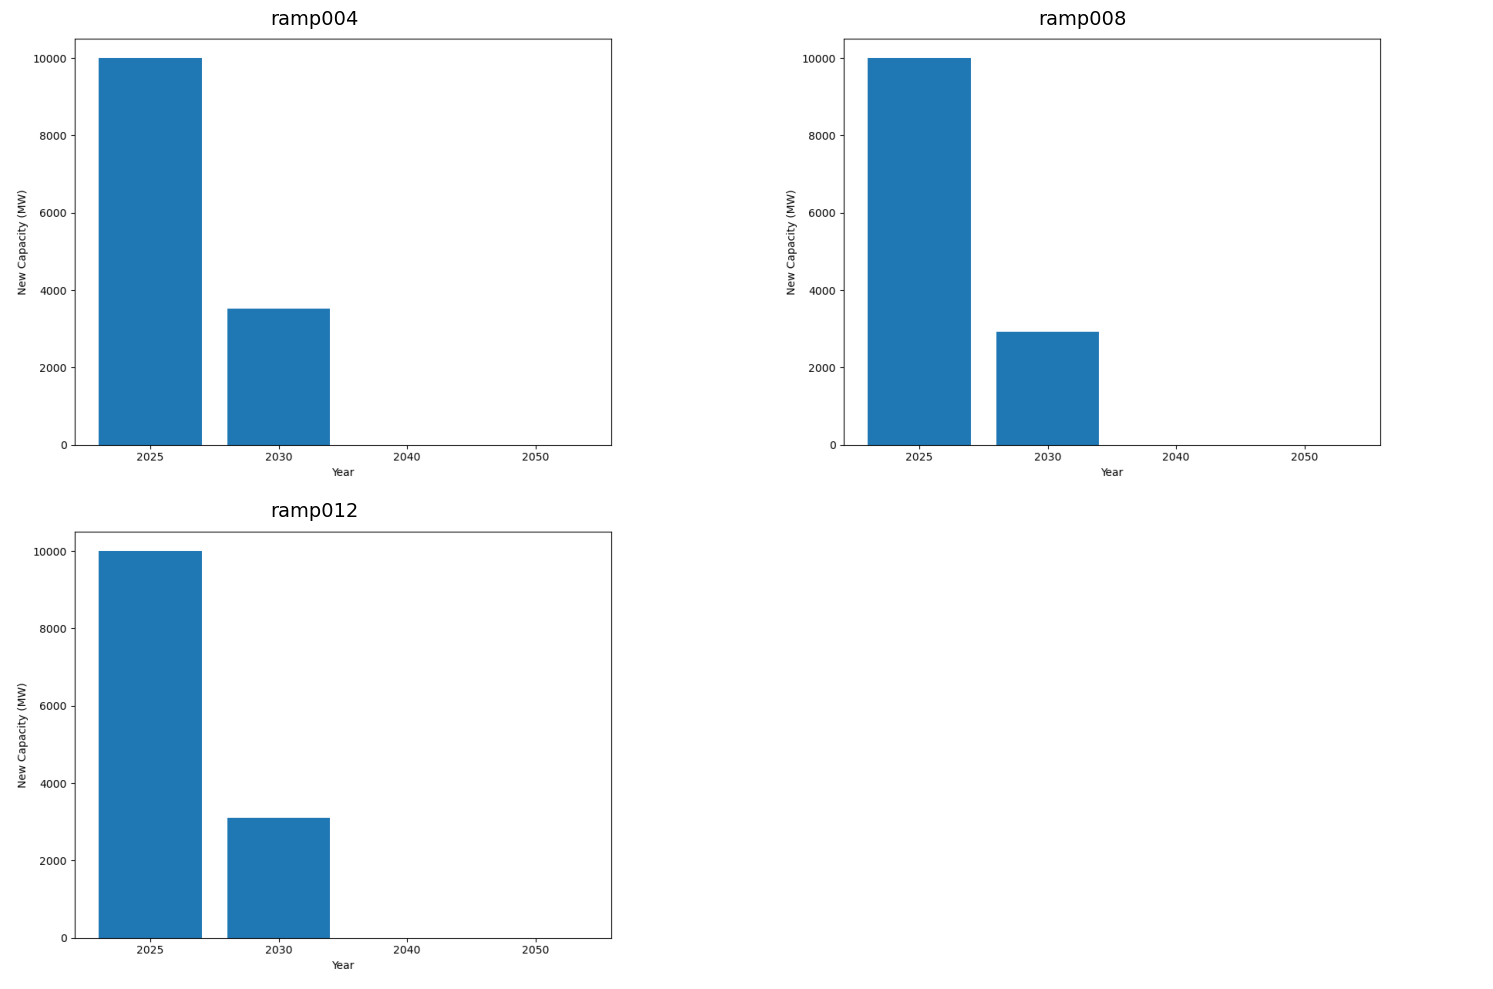

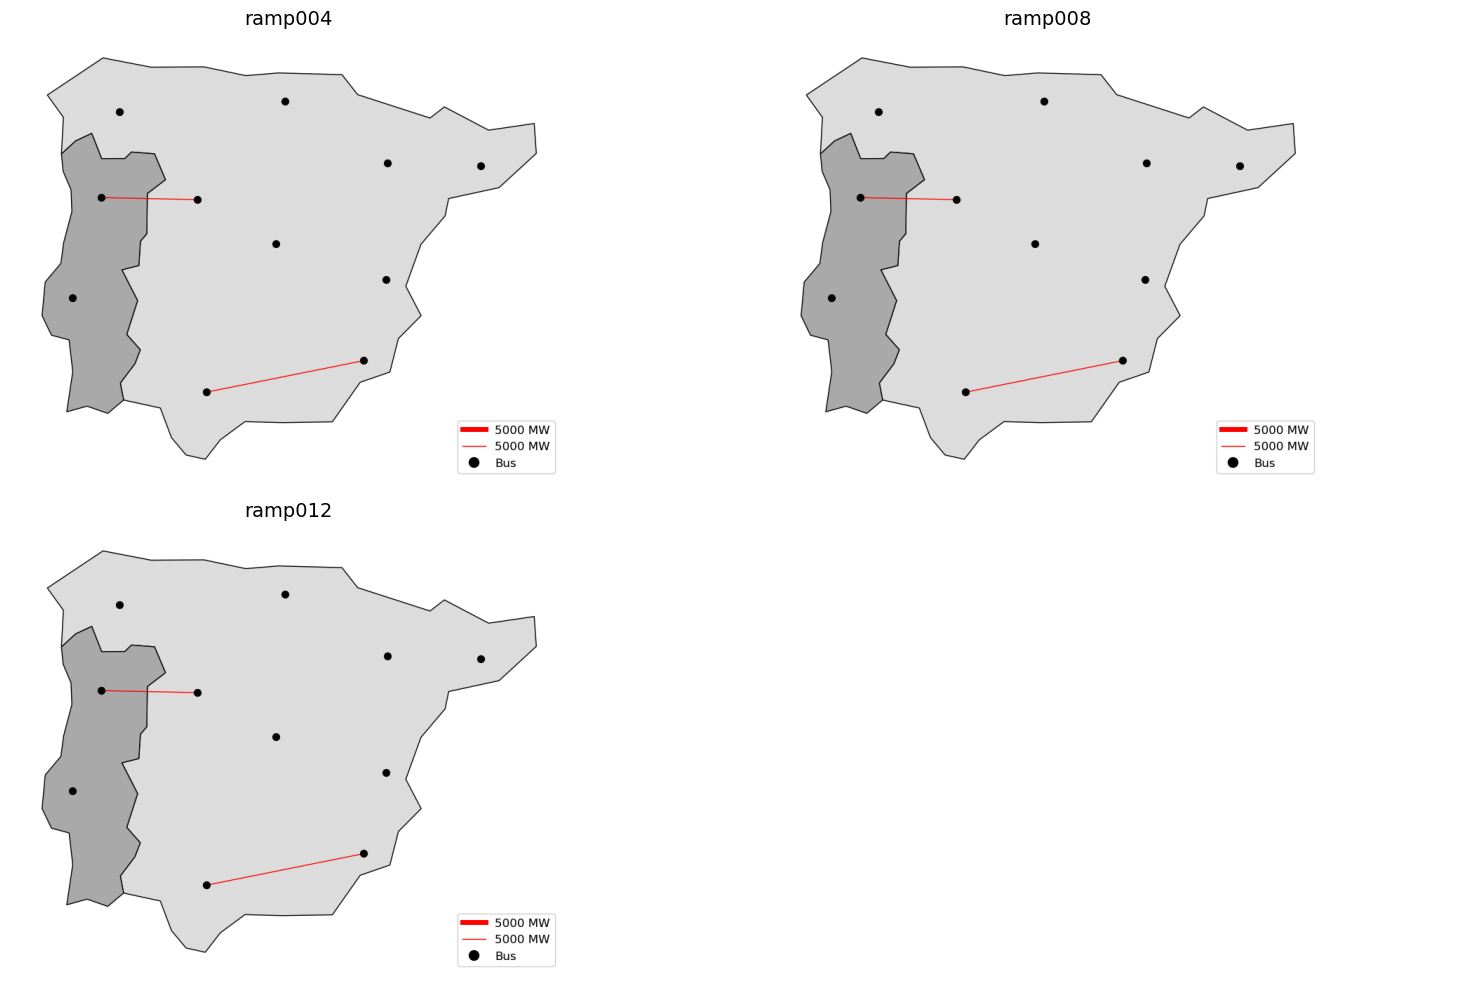

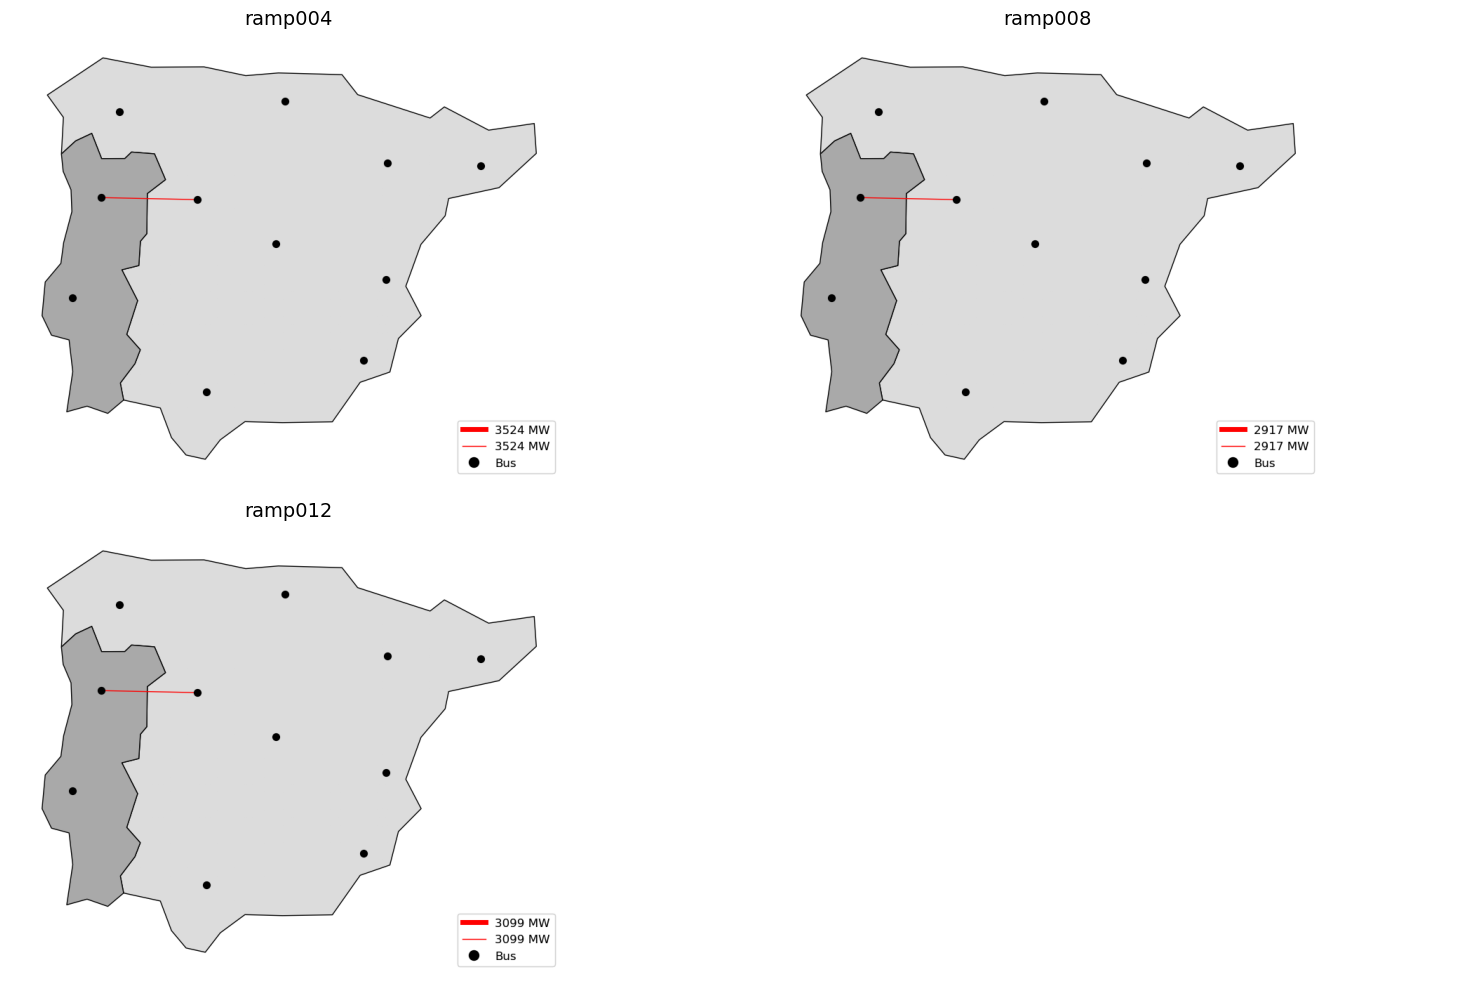


Category: generators (section: figures)


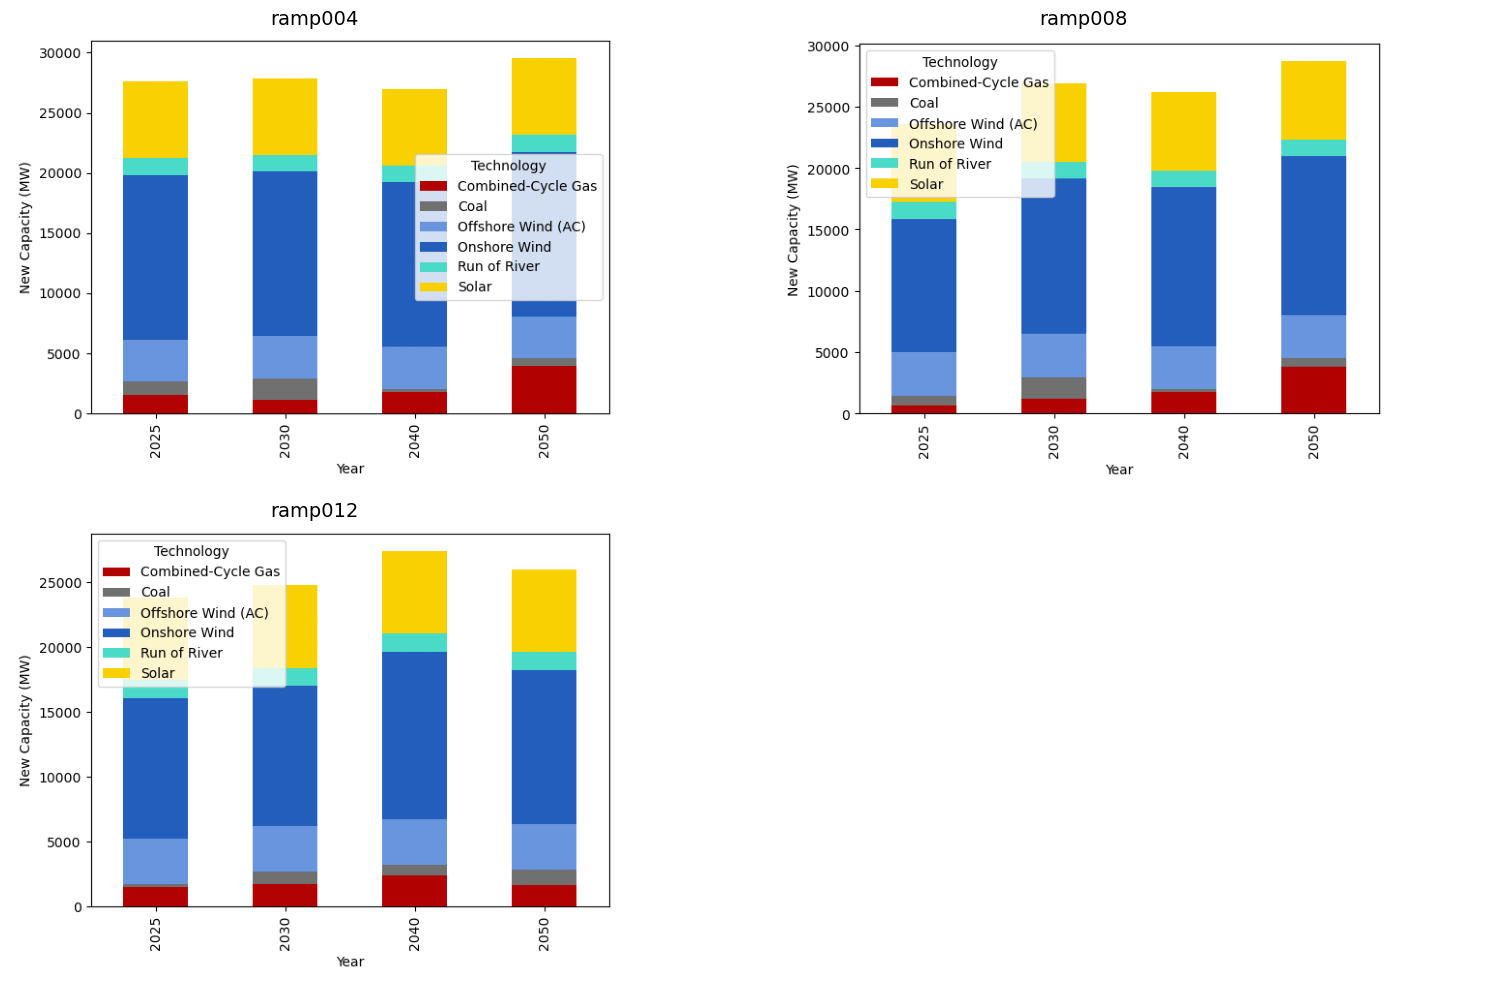

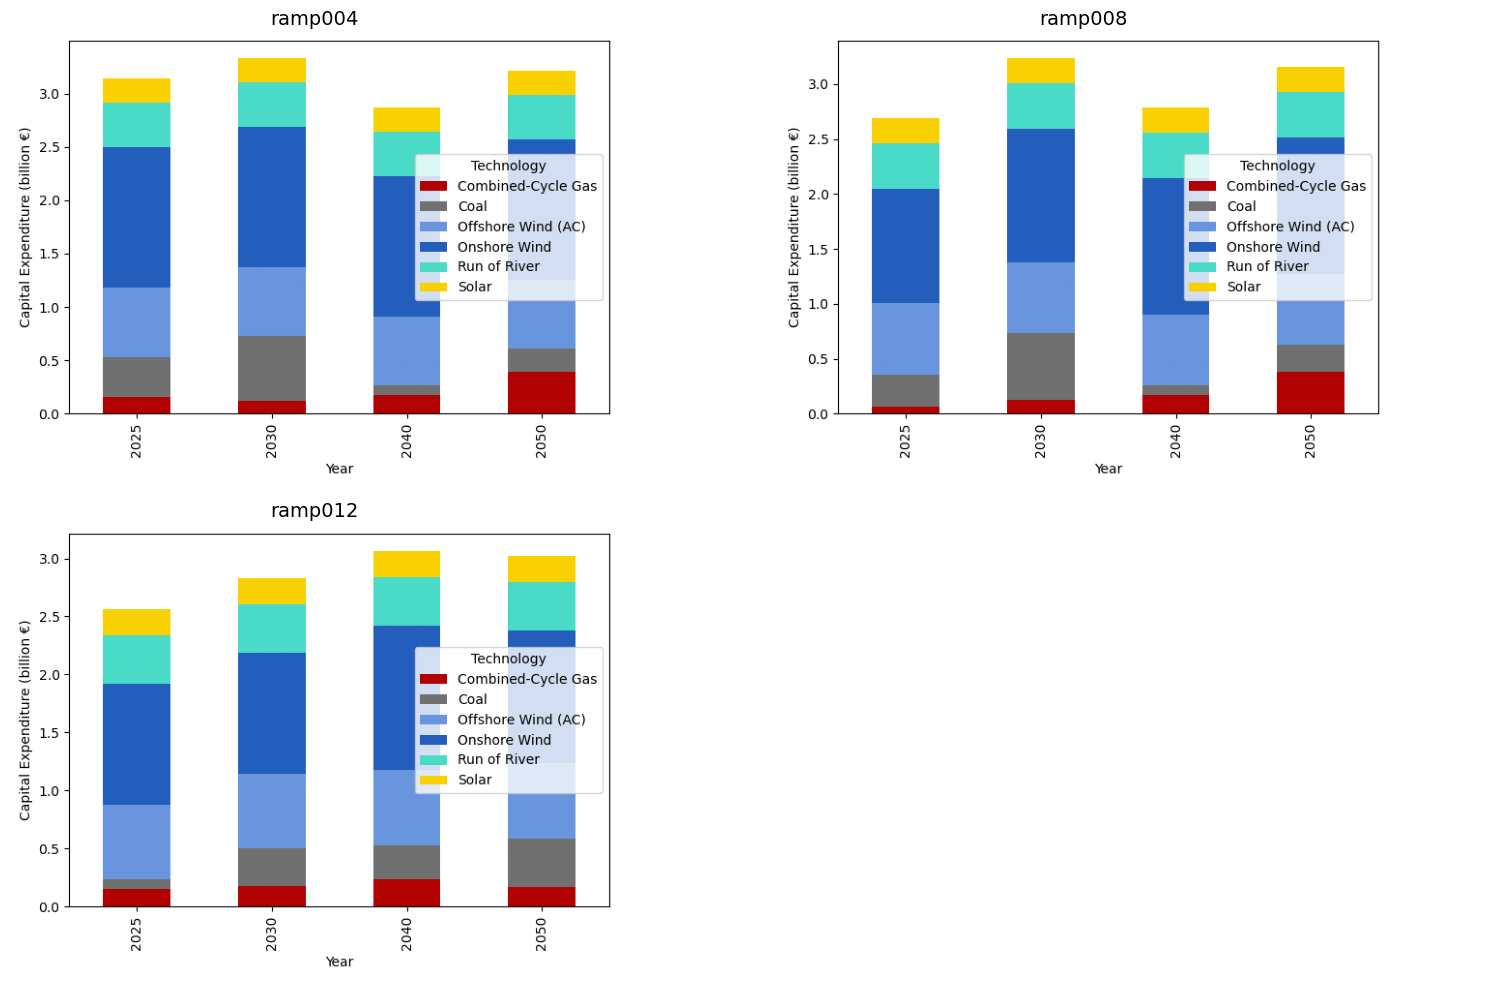

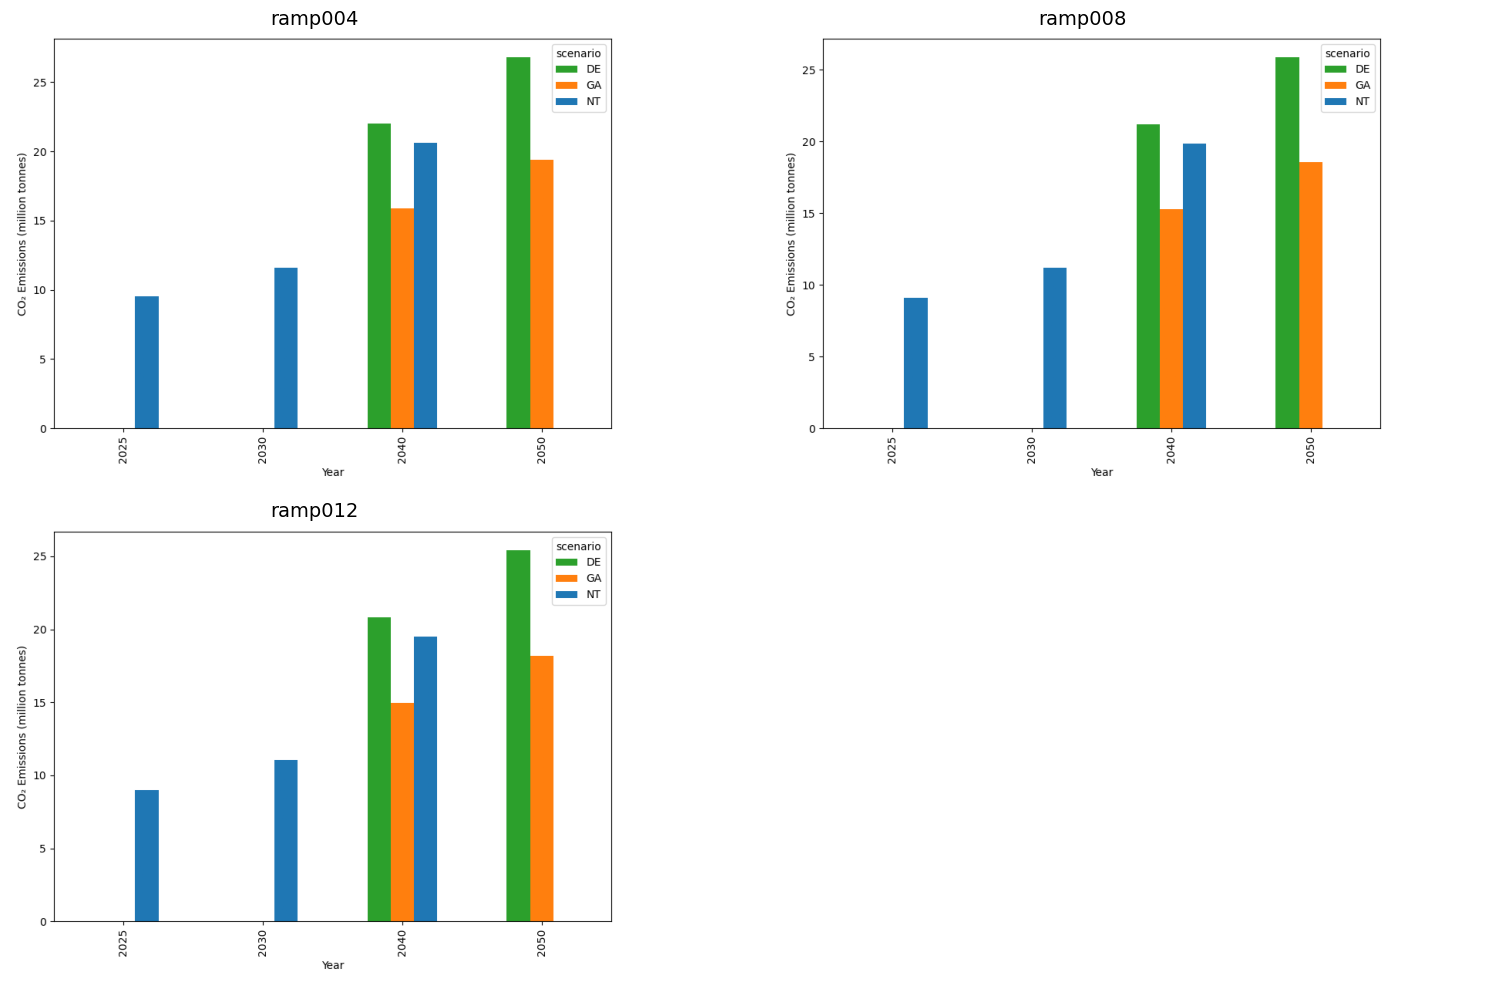

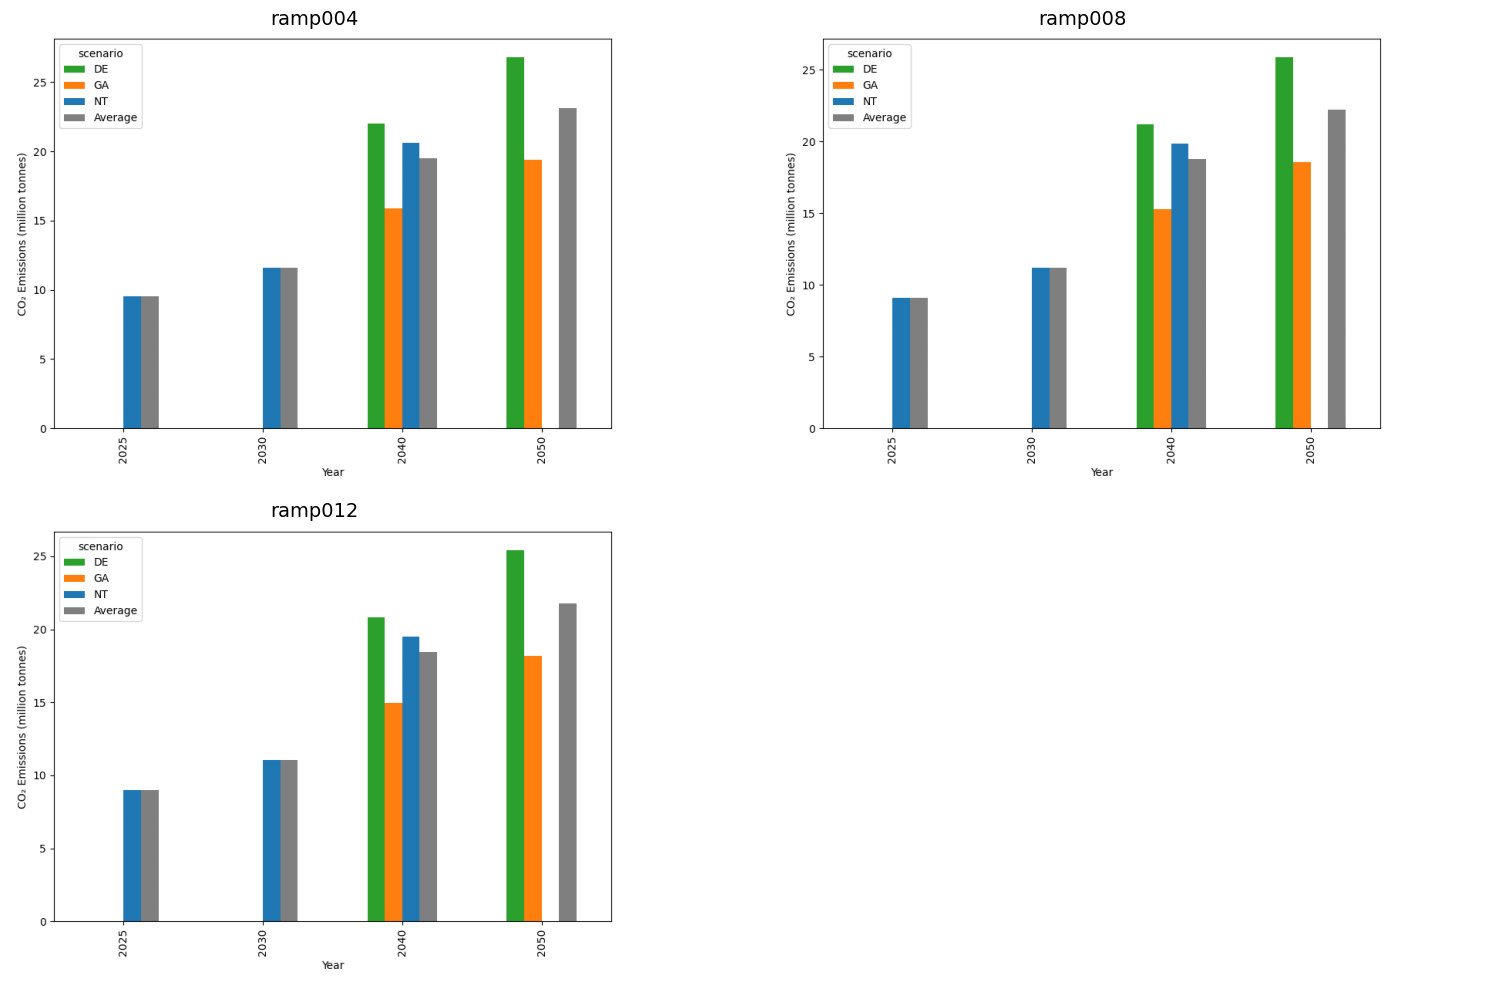

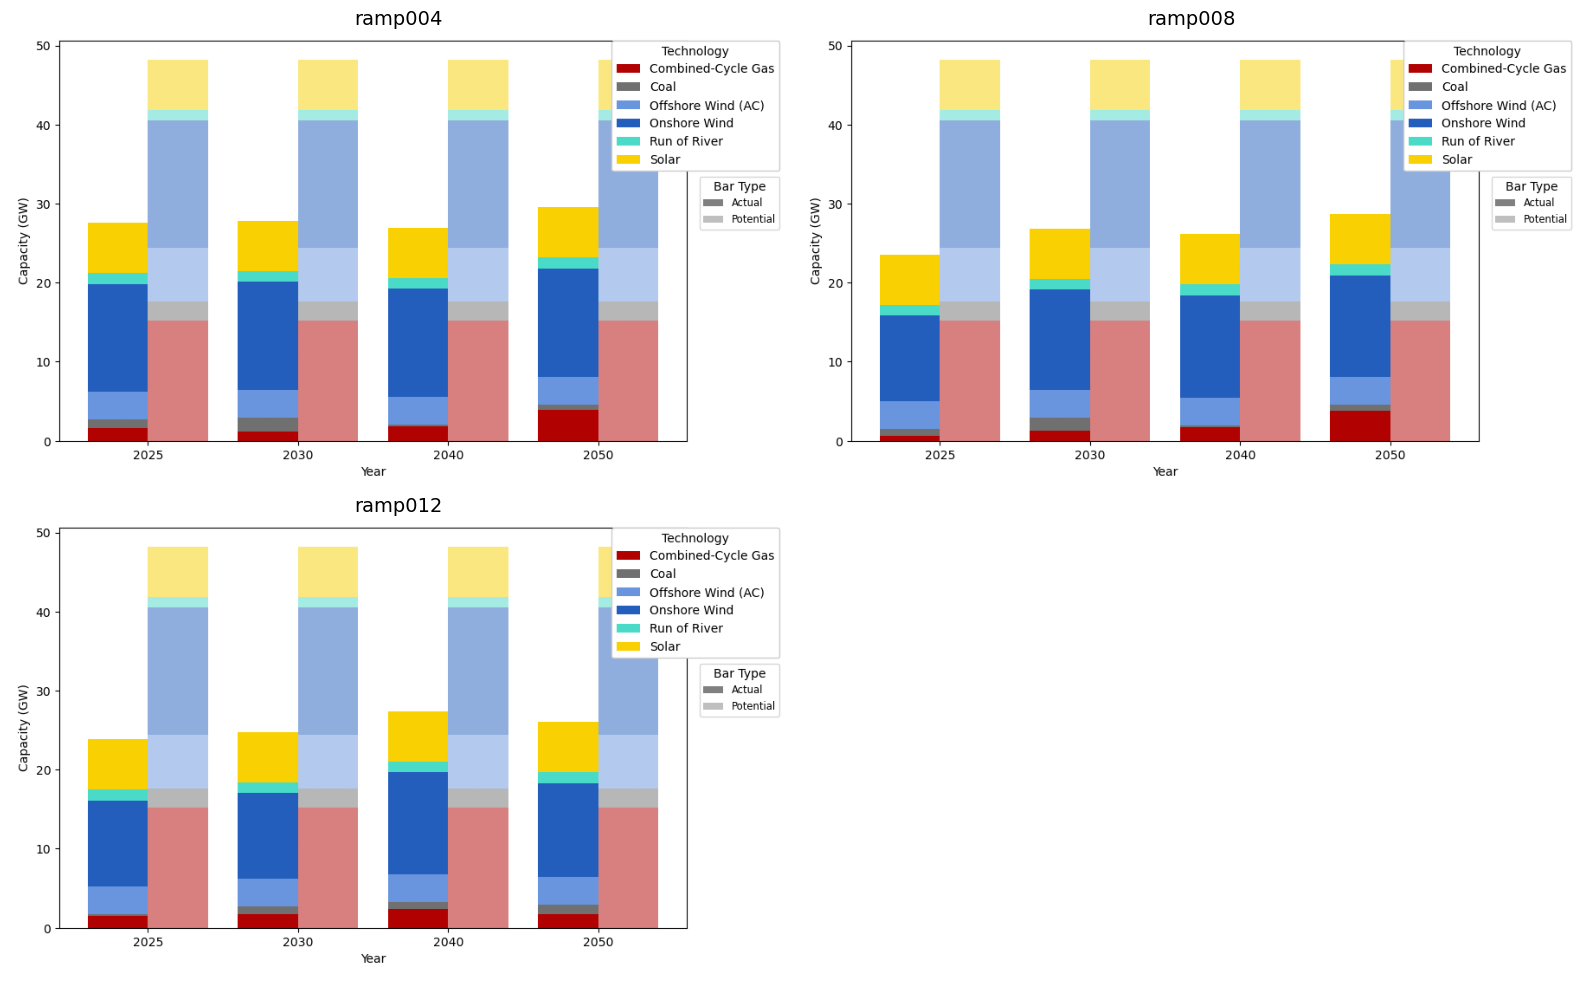

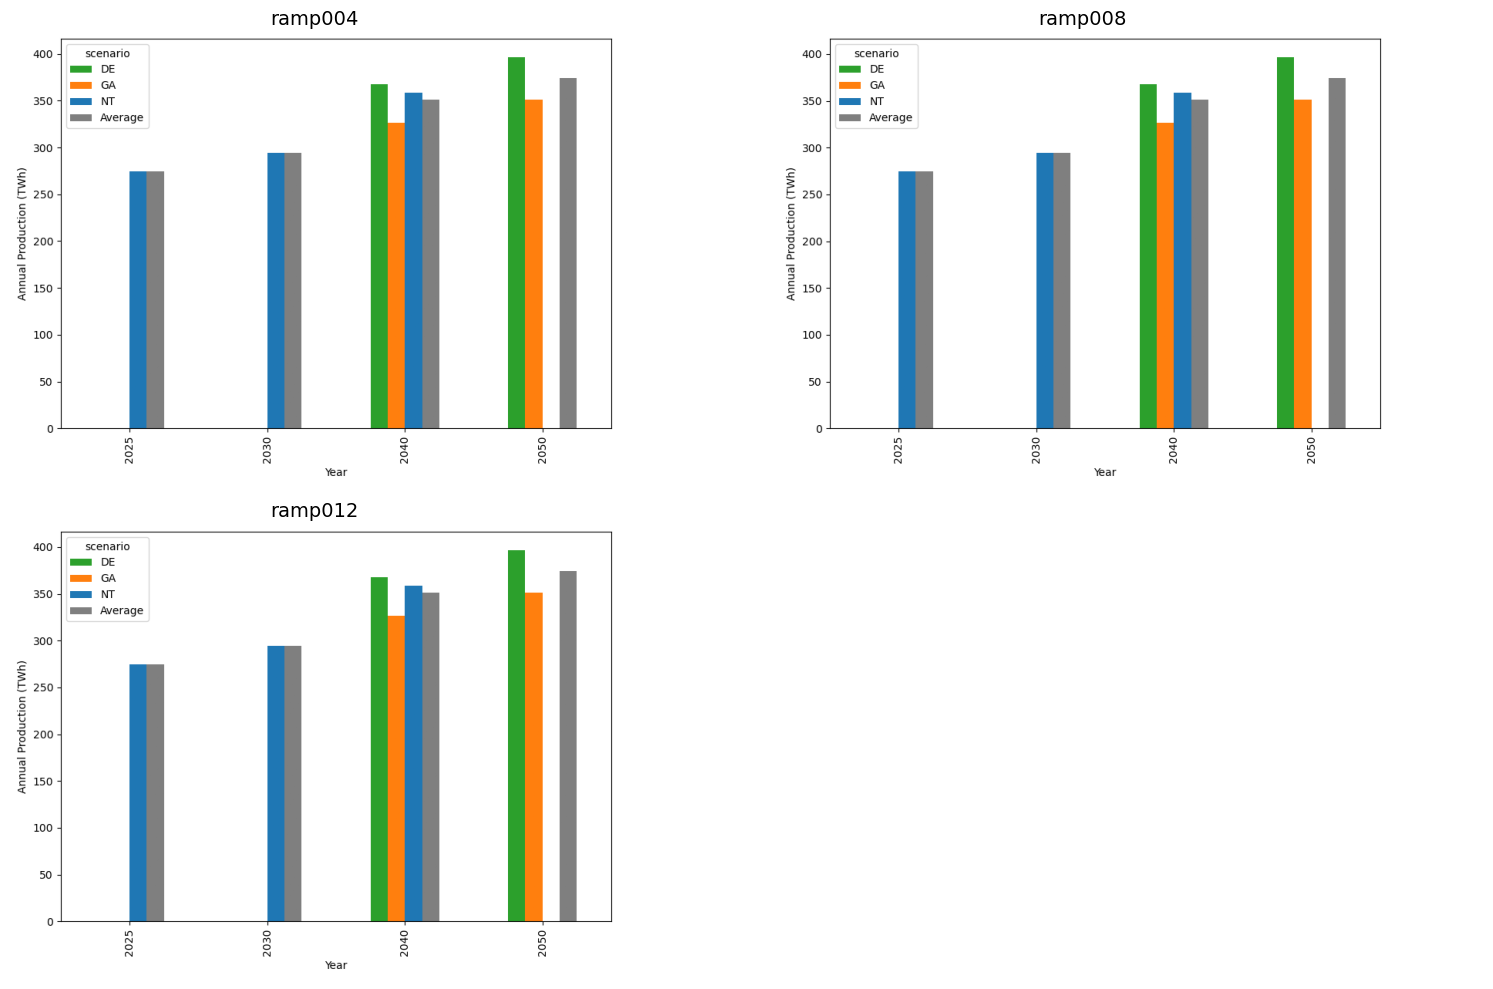

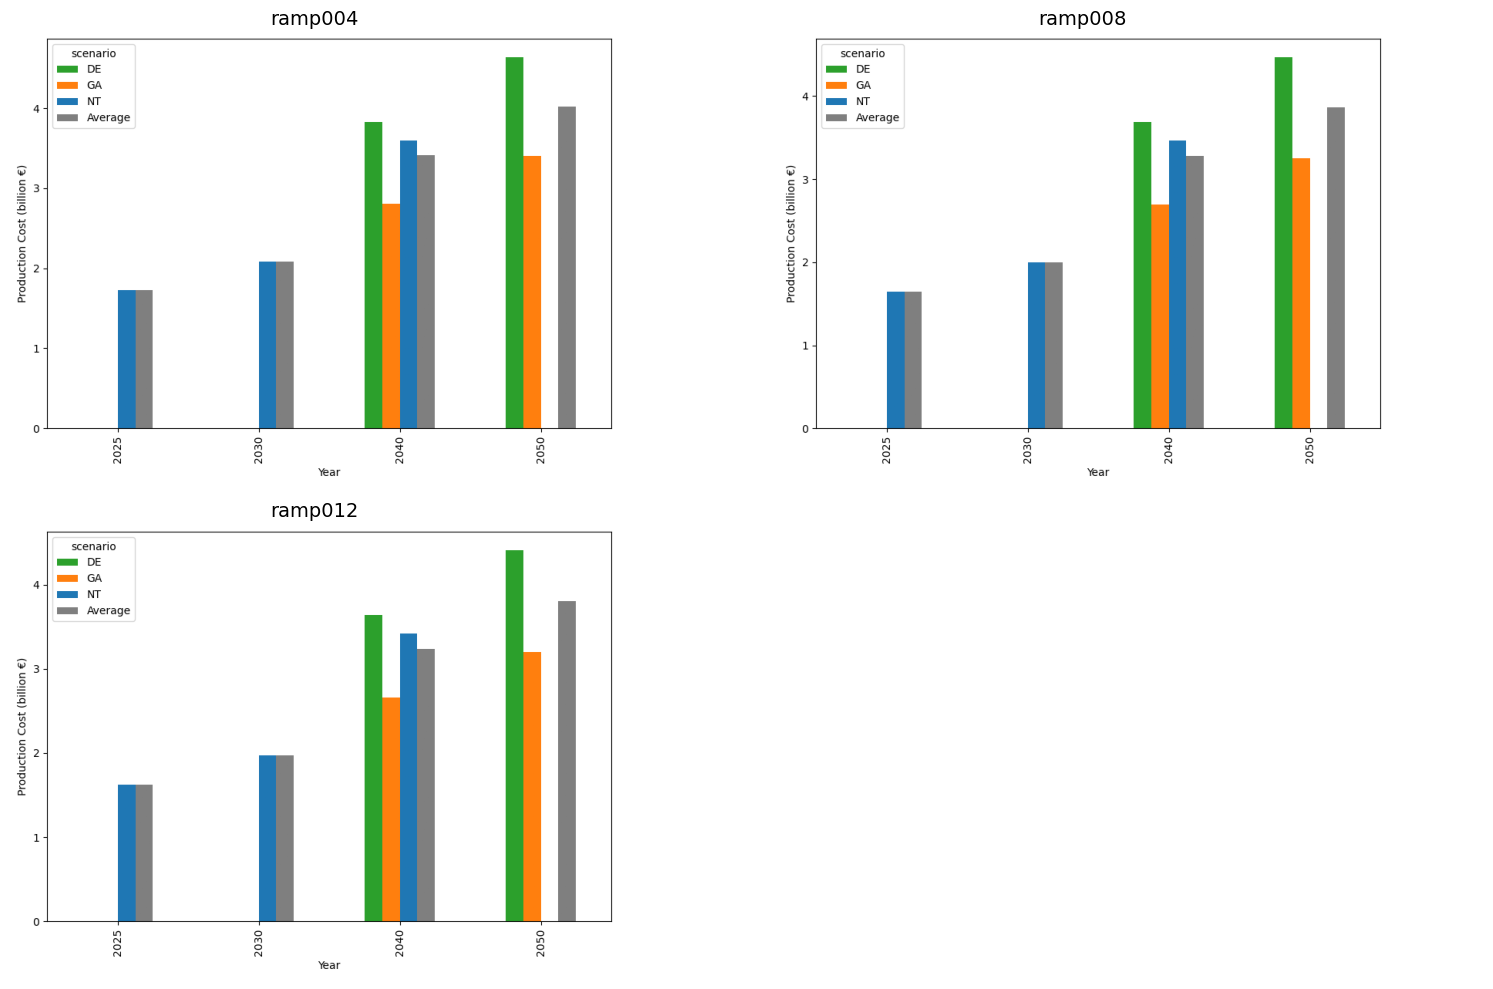

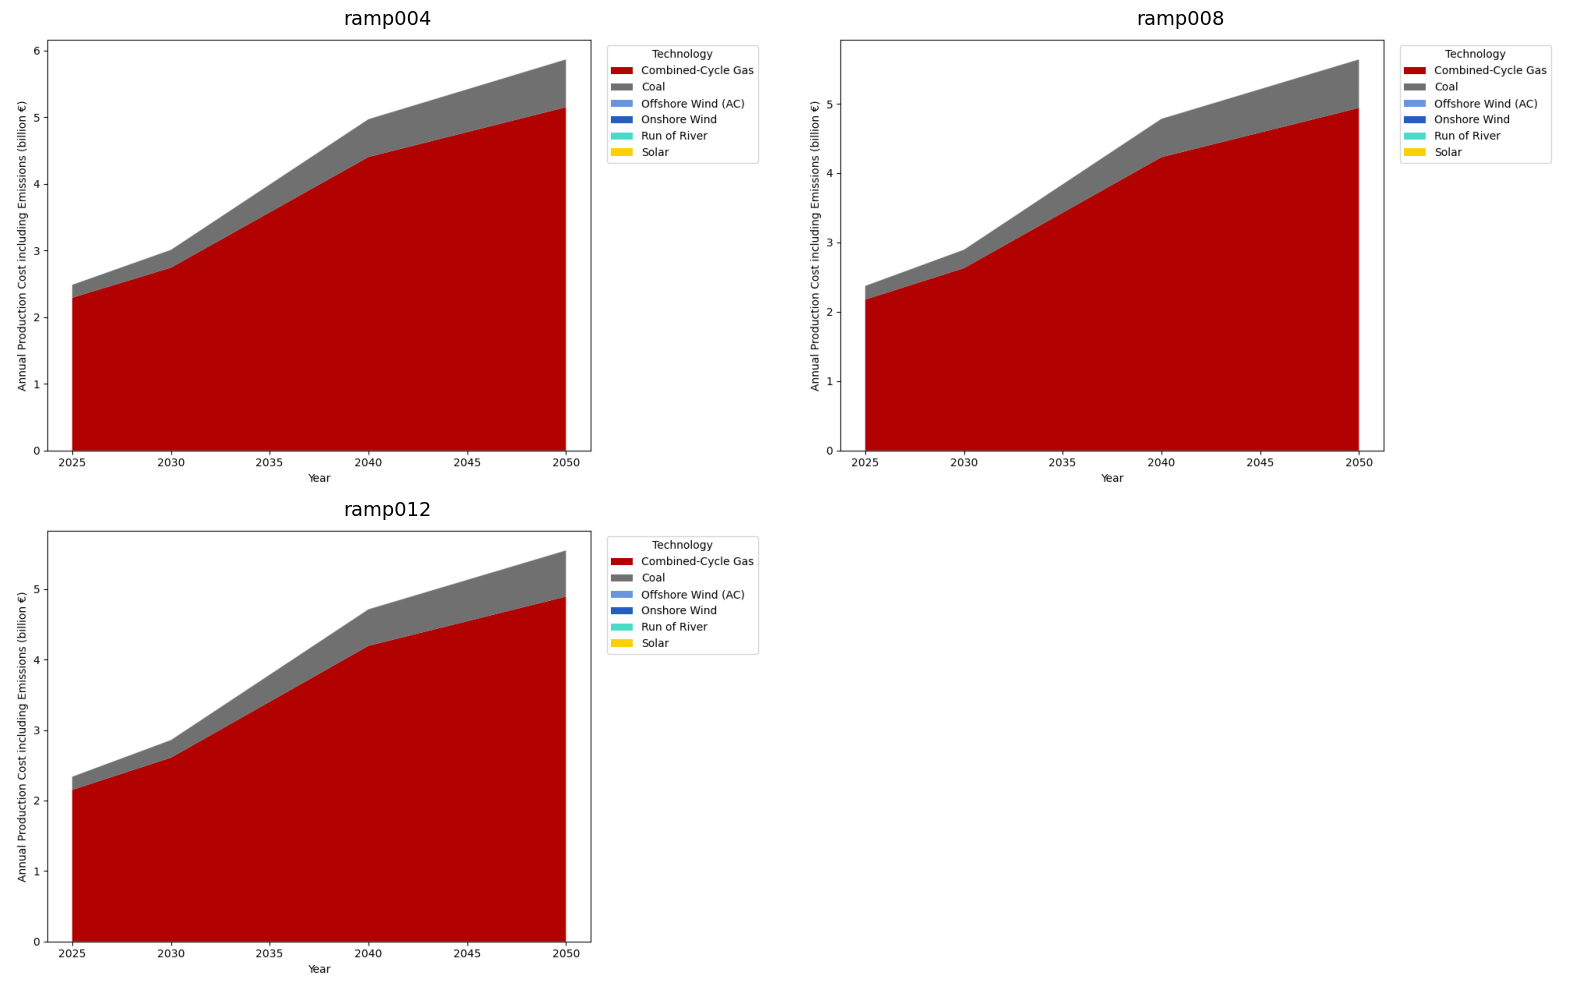

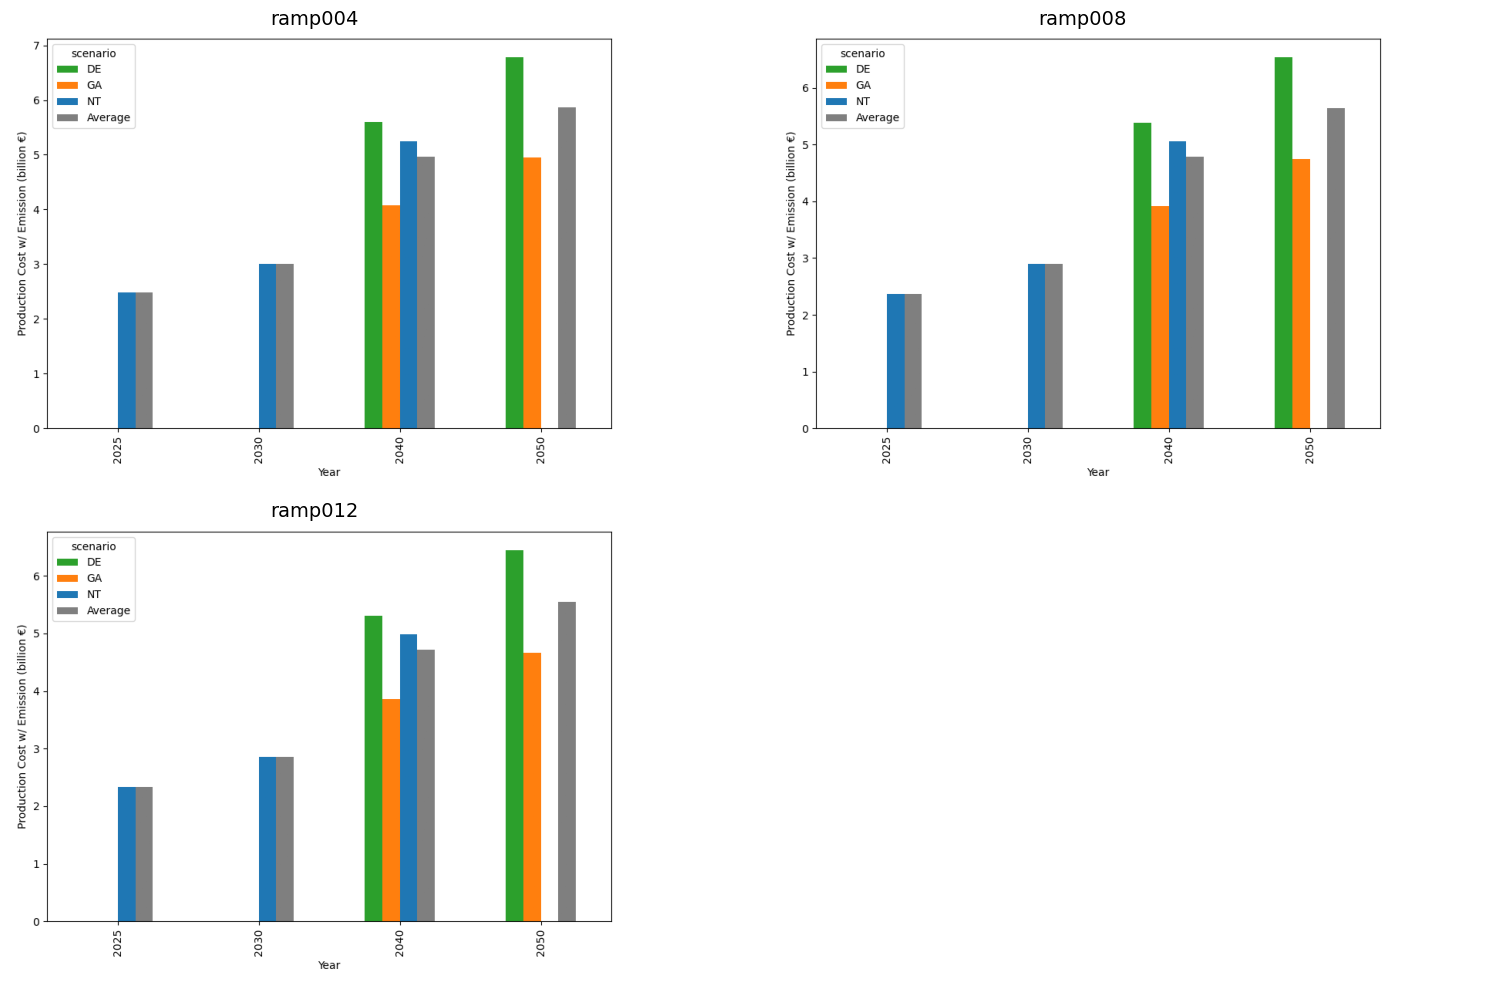

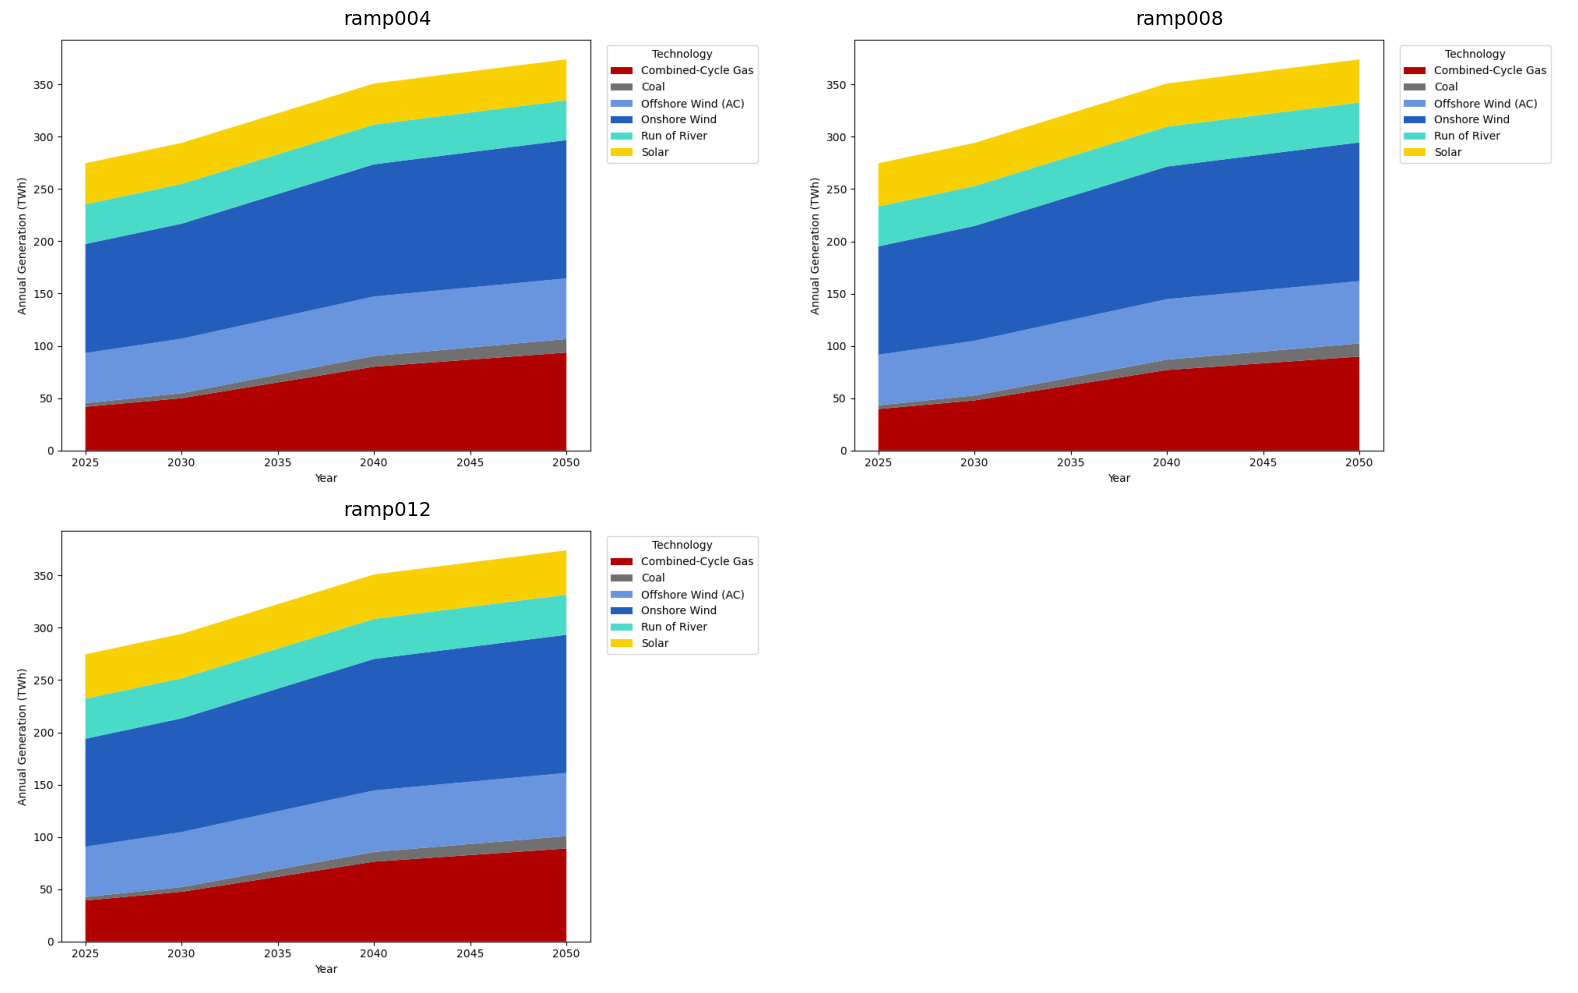

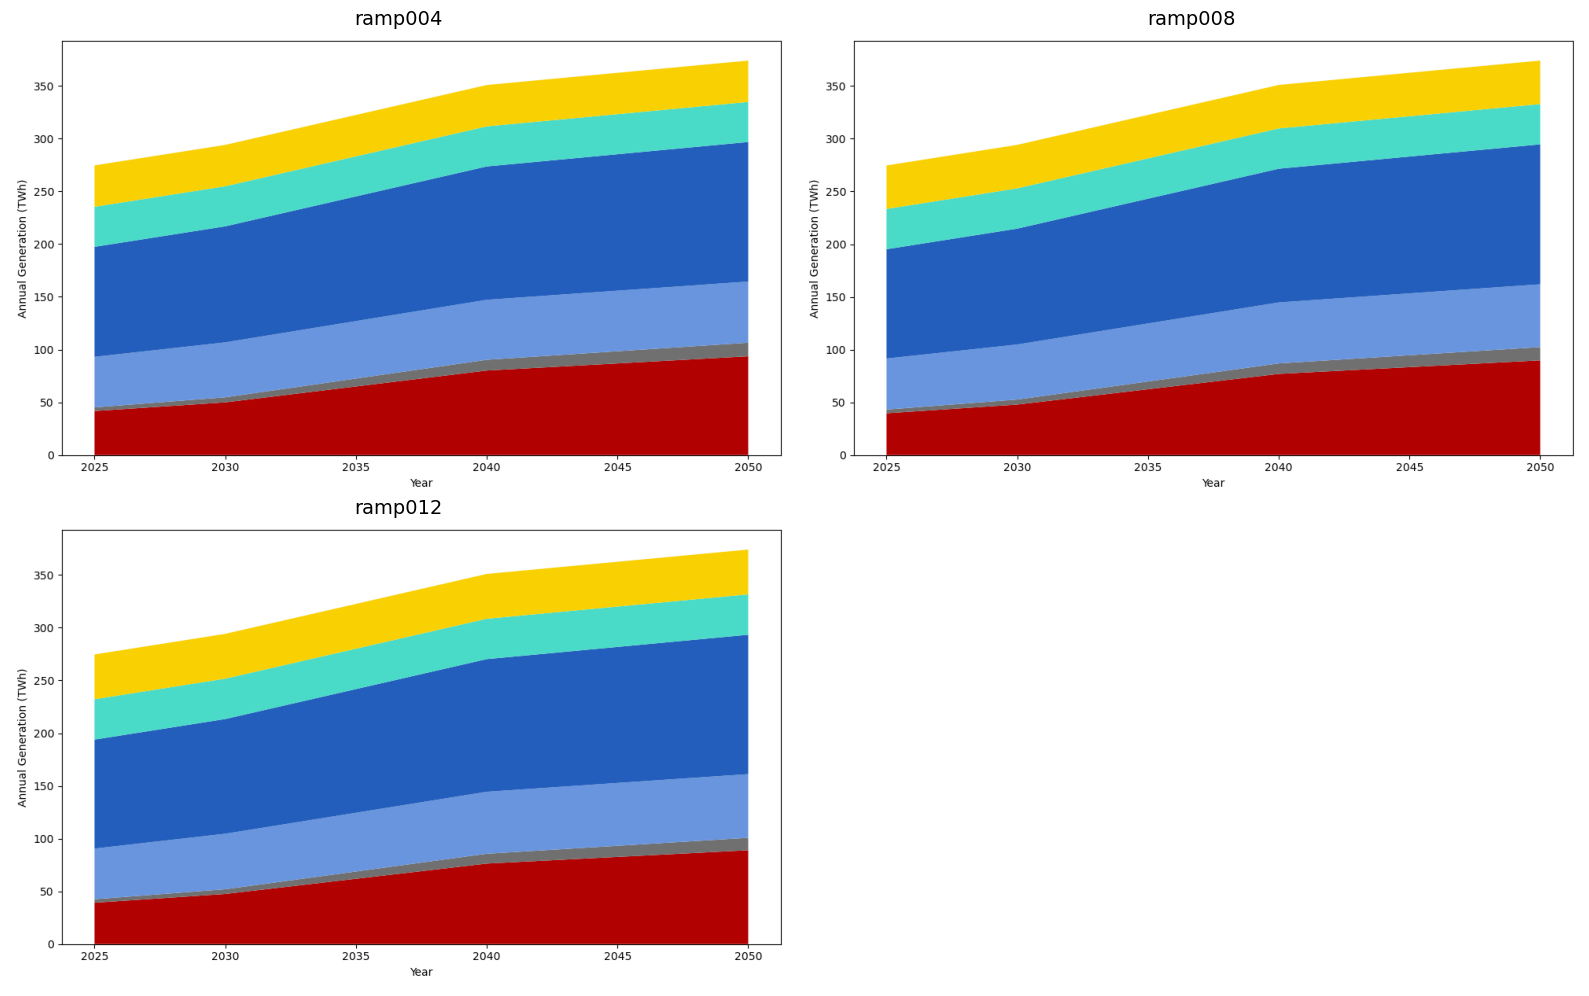

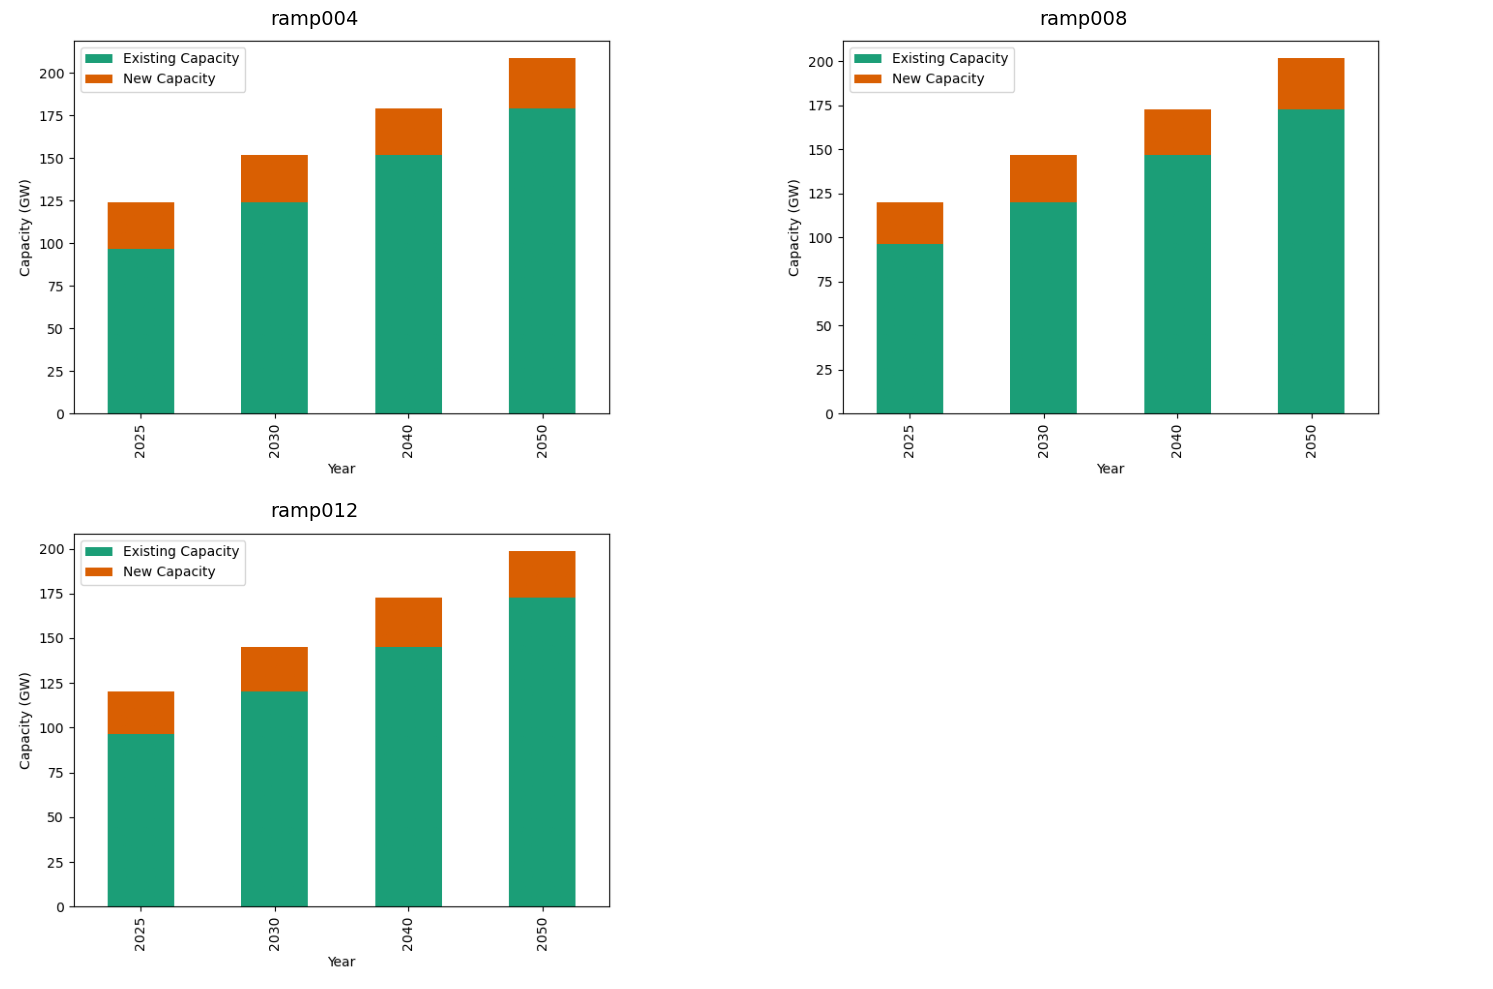

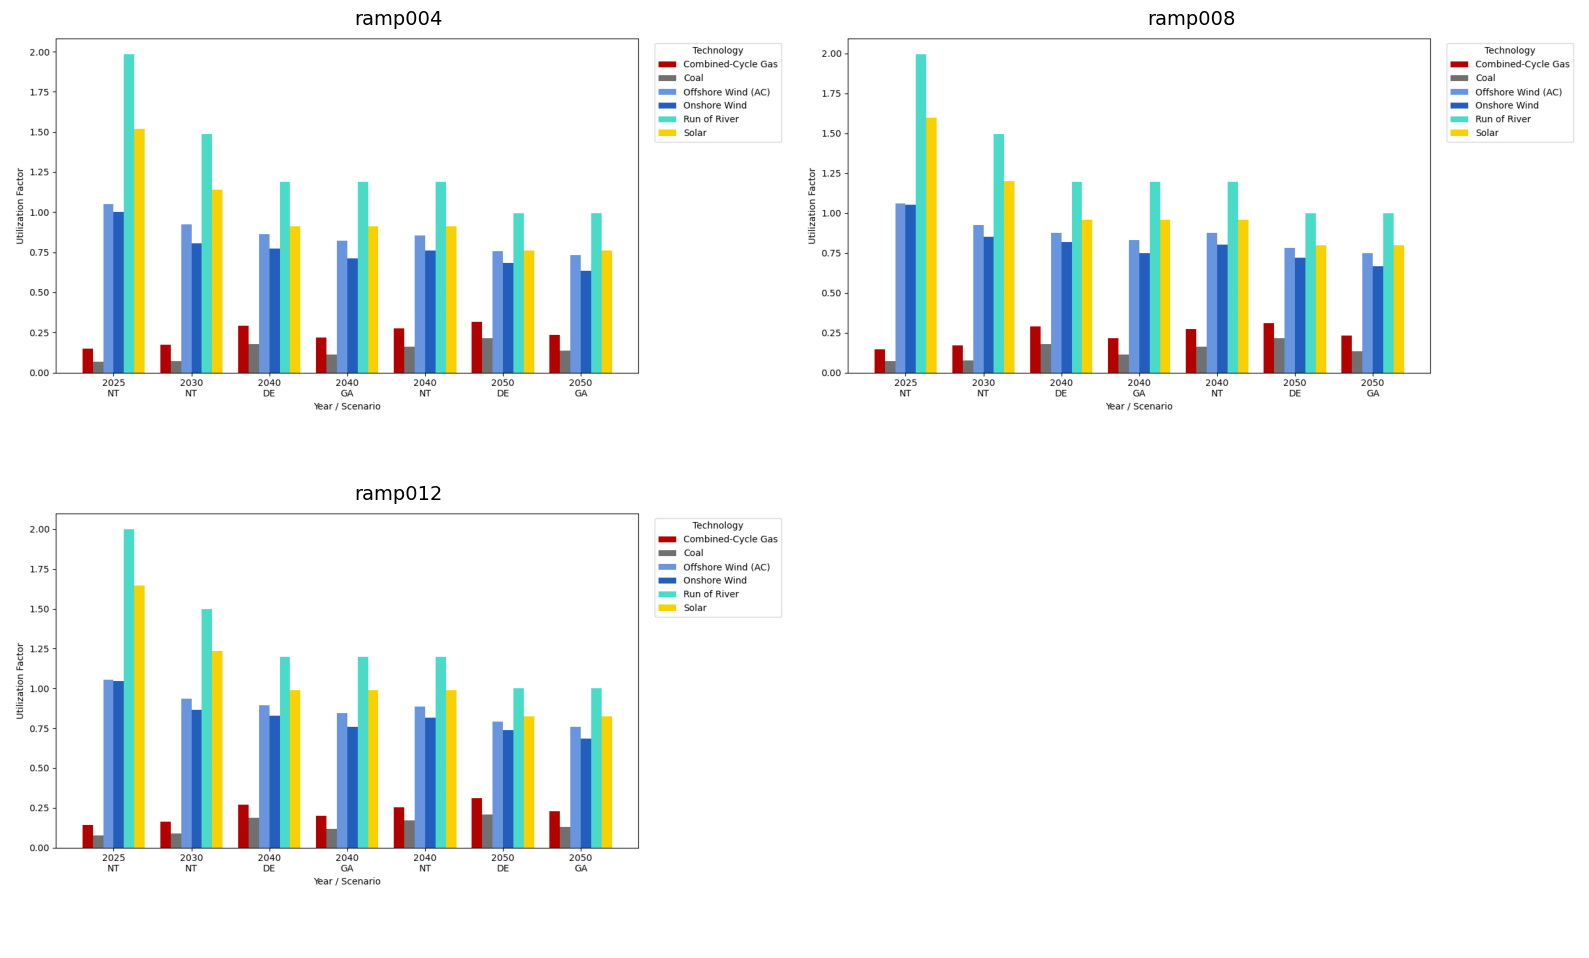


Category: macro (section: figures)


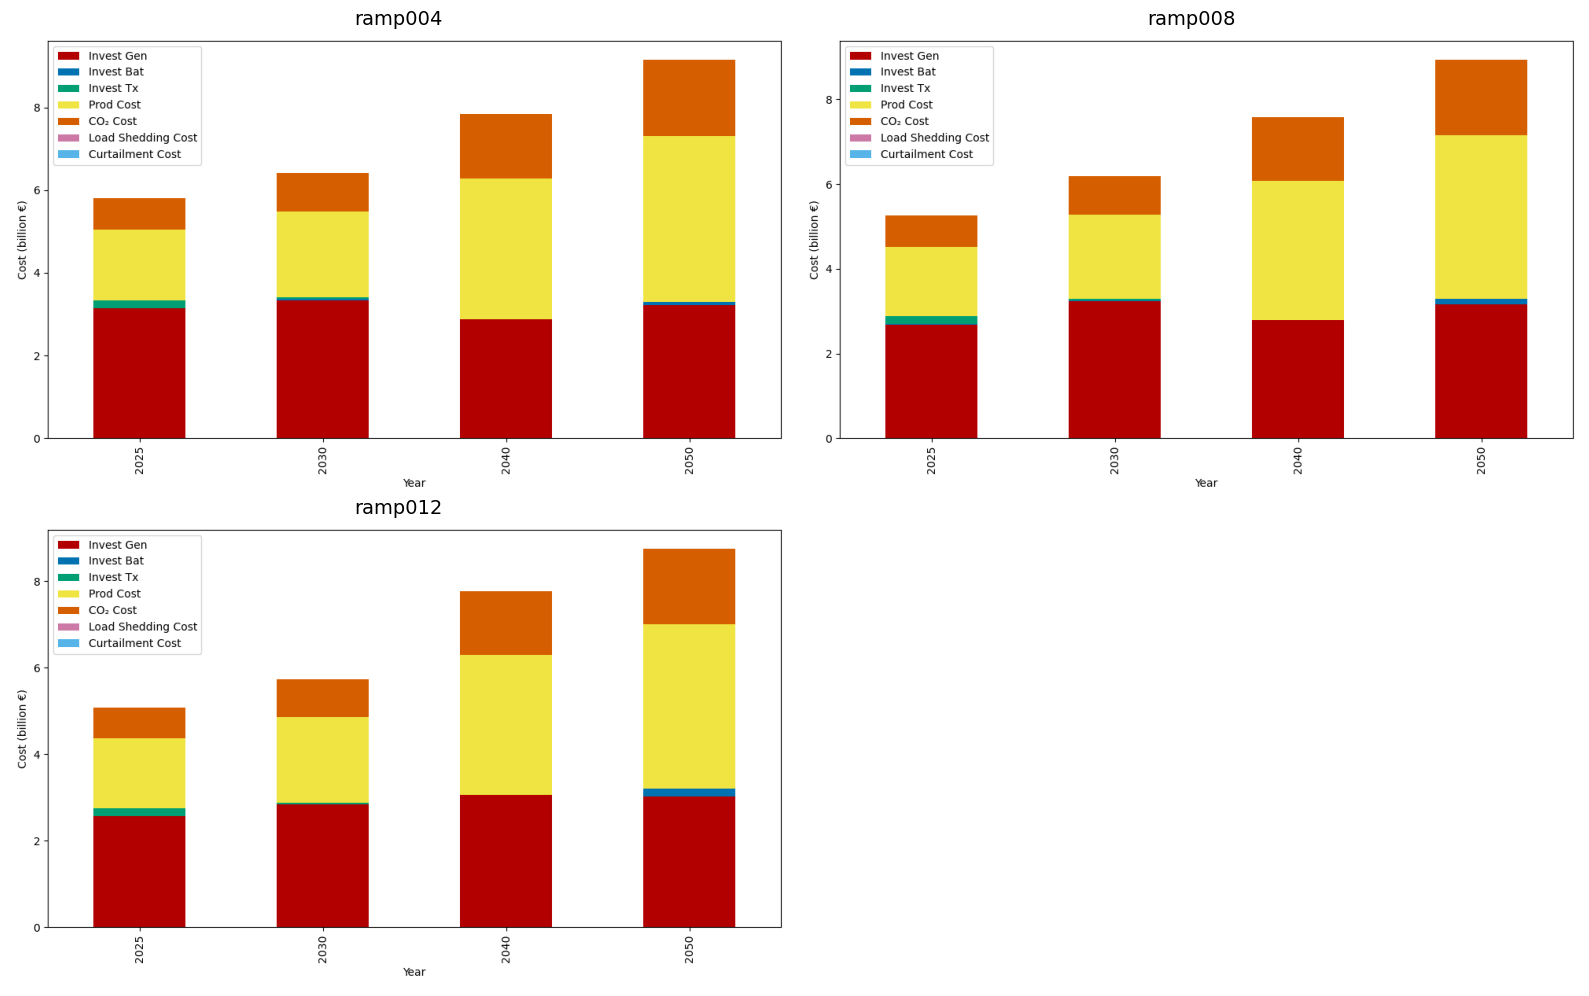

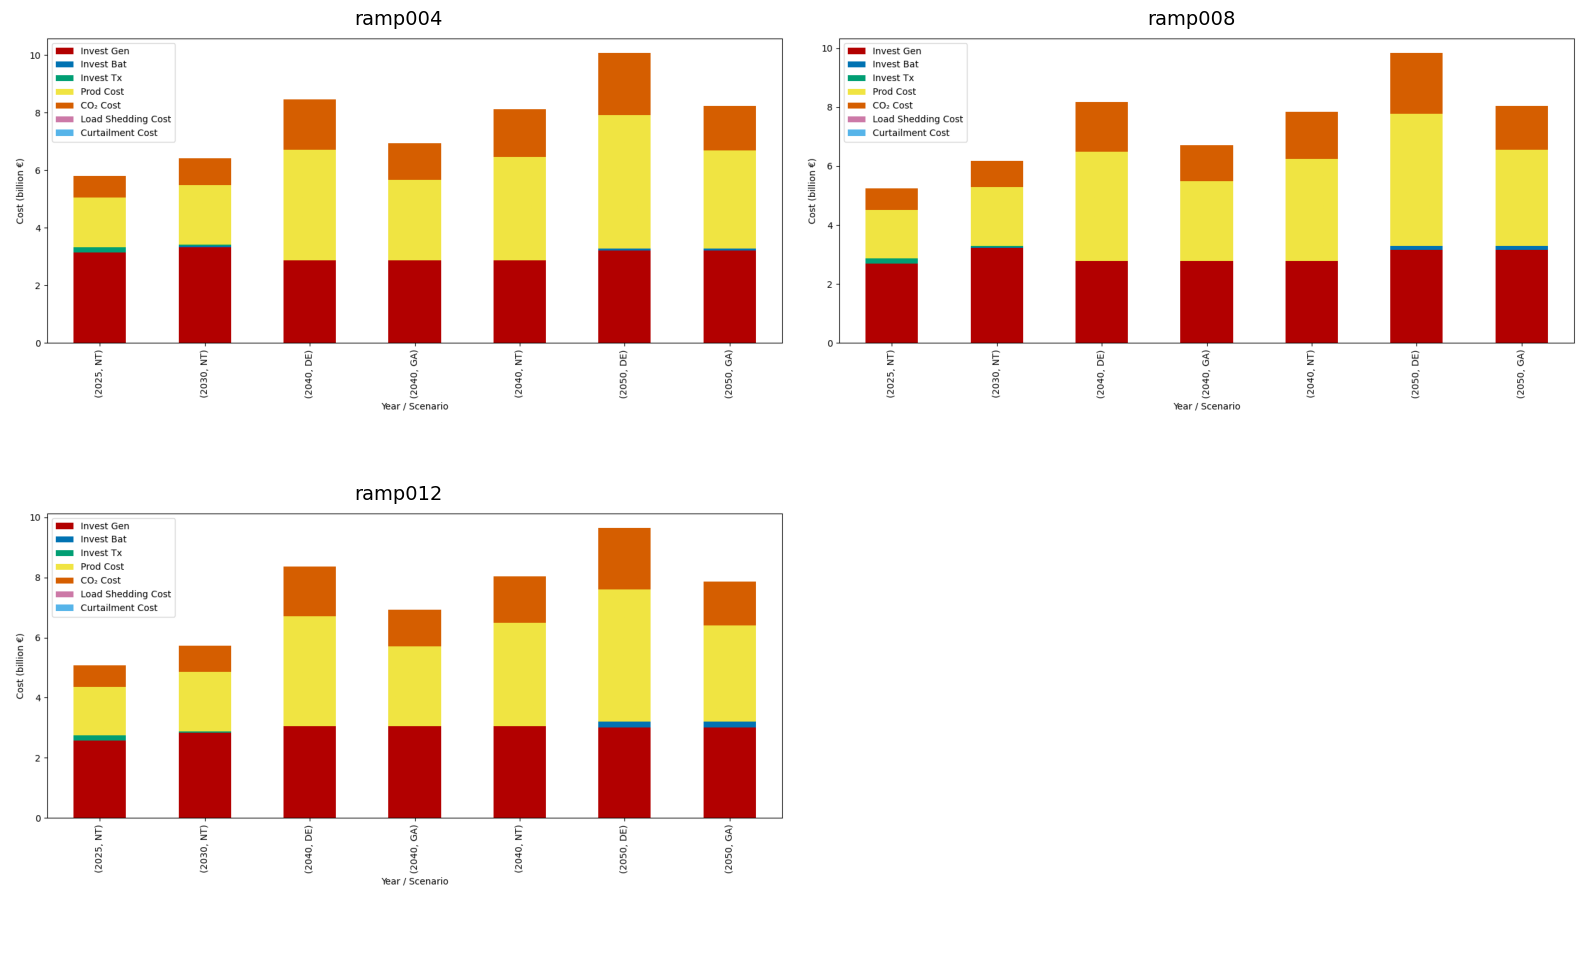

In [20]:
# To show duals images by category:
display_images_by_category(
    results_folders_to_explore, display_names, max_columns=2, section="figures"
)

In [21]:
# # To show duals images by category:
# display_images_by_category(
#     results_folders_to_explore, display_names, max_columns=2, section="duals"
# )

In [22]:
def load_and_combine_result_tables_by_category(
    results_folders: list[str],
    run_labels: list[str],
    tables_subdir: str = "results/tables",
) -> dict[str, dict[str, pd.DataFrame]]:
    """
    Discover all CSVs under each run's results/tables folder, then load and
    combine them across runs, organizing them by top-level category.

    Now concatenates along rows, using run_labels as the outer index level
    ('scenario'), so that the first index is the scenario name and the second
    is the original table index. Table names drop the '.csv'.
    """
    # 1) Gather all relative CSV paths
    all_rel_paths = set()
    for folder in results_folders:
        base = os.path.join(folder, tables_subdir)
        for root, _, files in os.walk(base):
            for file in files:
                if file.lower().endswith(".csv"):
                    rel = os.path.relpath(os.path.join(root, file), base)
                    all_rel_paths.add(rel)

    nested: dict[str, dict[str, pd.DataFrame]] = {}
    # 2) For each CSV, load each run's table, then concat down rows
    for rel in sorted(all_rel_paths):
        per_run_dfs = []
        for folder, label in zip(results_folders, run_labels):
            path = os.path.join(folder, tables_subdir, rel)
            if not os.path.exists(path):
                continue
            # read CSV, first col as index if possible
            df = pd.read_csv(path, index_col=None)
            # attach label as key
            per_run_dfs.append((label, df))
        if not per_run_dfs:
            continue
        # Concatenate along rows with scenario as outer index
        combined = pd.concat(
            {label: df for label, df in per_run_dfs},
            axis=0,
            names=["run"] + (per_run_dfs[0][1].index.names or [None]),
        )
        # Place into nested dict by category and stripped name
        parts = rel.split(os.sep)
        category = parts[0]
        table_name = os.path.splitext(parts[-1])[0]
        nested.setdefault(category, {})[table_name] = combined

    return nested

In [23]:
combined_by_cat = load_and_combine_result_tables_by_category(
    results_folders_to_explore, display_names
)

In [24]:
for cat, tables in combined_by_cat.items():
    for name, df in tables.items():
        print(cat, name, df.shape)

batteries battery_system_summary_by_year (12, 5)
battery_system_summary_by_year.csv battery_system_summary_by_year (12, 5)
branches aggregate_branch_flow_summary (21, 4)
branches branch_buildout_summary_by_year (12, 6)
branches branch_flow_metrics (399, 5)
curtailment_load_shedding_costs.csv curtailment_load_shedding_costs (21, 6)
duals annual_lmp_overall_average (3, 2)
duals annual_lmp_table (12, 5)
duals dual_nonzero_summary (45, 4)
duals dual_year_scenario_summary (255, 7)
duals gap_wind_thermal_dual_summary (21, 5)
duals gen_extension_nonzero_duals (332, 3)
duals high_lmp_freq_table_62plus (300, 6)
duals lmp_bucket_frequencies (24, 5)
duals lmp_frequency_table (213, 9)
duals lmp_frequency_table_sorted (213, 9)
duals nodal_price_table (21, 13)
duals top_10_high_lmp_bins (30, 6)
extended_tables extended_batteries (132, 19)
extended_tables extended_branches (228, 14)
extended_tables extended_generators (612, 16)
generators annual_production_by_carrier_and_scenario (21, 9)
generators a

In [25]:
combined_by_cat.keys()

dict_keys(['batteries', 'battery_system_summary_by_year.csv', 'branches', 'curtailment_load_shedding_costs.csv', 'duals', 'extended_tables', 'generators', 'macro'])

In [26]:
combined_by_cat["battery_system_summary_by_year.csv"]
combined_by_cat["batteries"]["battery_system_summary_by_year"] = combined_by_cat[
    "battery_system_summary_by_year.csv"
]["battery_system_summary_by_year"]

In [27]:
combined_by_cat["cls"] = combined_by_cat["curtailment_load_shedding_costs.csv"]
combined_by_cat.pop("curtailment_load_shedding_costs.csv")
# combined_by_cat["batteries"]["battery_system_summary_by_year"] = combined_by_cat[
#     "battery_system_summary_by_year.csv"
# ]
combined_by_cat.pop("battery_system_summary_by_year.csv")
combined_by_cat["cls"].keys()

dict_keys(['curtailment_load_shedding_costs'])

In [28]:
# For easier access, unpack the categories you need from the nested dict:
battery_tables = combined_by_cat.get("batteries", {})
branches_tables = combined_by_cat.get("branches", {})
extended_tables = combined_by_cat.get("extended_tables", {})
generators_tables = combined_by_cat.get("generators", {})
macro_tables = combined_by_cat.get("macro", {})
duals_tables = combined_by_cat.get("duals", {})
cls_tables = combined_by_cat.get("cls", {})

# Example: list available tables in each category
print("Battery tables:", list(battery_tables.keys()))
print("Branch tables:", list(branches_tables.keys()))
print("Extended tables:", list(extended_tables.keys()))
print("Generator tables:", list(generators_tables.keys()))
print("Macro tables:", list(macro_tables.keys()))
print("Duals tables:", list(duals_tables.keys()))
print("CLS tables:", list(cls_tables.keys()))

Battery tables: ['battery_system_summary_by_year']
Branch tables: ['aggregate_branch_flow_summary', 'branch_buildout_summary_by_year', 'branch_flow_metrics']
Extended tables: ['extended_batteries', 'extended_branches', 'extended_generators']
Generator tables: ['annual_production_by_carrier_and_scenario', 'annual_weighted_cost_by_carrier', 'annual_weighted_production_by_carrier', 'energy_production_by_carrier_table']
Macro tables: ['mega_cost_table', 'system_summary_by_year', 'system_summary_by_year_and_carrier', 'total_system_cost', 'yearly_system_costs_by_scenario']
Duals tables: ['annual_lmp_overall_average', 'annual_lmp_table', 'dual_nonzero_summary', 'dual_year_scenario_summary', 'gap_wind_thermal_dual_summary', 'gen_extension_nonzero_duals', 'high_lmp_freq_table_62plus', 'lmp_bucket_frequencies', 'lmp_frequency_table', 'lmp_frequency_table_sorted', 'nodal_price_table', 'top_10_high_lmp_bins']
CLS tables: ['curtailment_load_shedding_costs']


In [29]:
gen_df = extended_tables["extended_generators"]

# Update 'nice_name' for CCGT
gen_df.loc[gen_df["carrier"] == "CCGT", "nice_name"] = "CCGT"

# Update 'nice_name' for offwind-ac
gen_df.loc[gen_df["carrier"] == "offwind-ac", "nice_name"] = "Offshore Wind"

# Optionally, if you want to confirm the changes:
print(gen_df[["carrier", "nice_name"]].drop_duplicates())

               carrier      nice_name
run                                  
ramp004 0         CCGT           CCGT
        4         coal           Coal
        8   offwind-ac  Offshore Wind
        12      onwind   Onshore Wind
        16       solar          Solar
        56         ror   Run of River


In [30]:
extended_tables.keys()

dict_keys(['extended_batteries', 'extended_branches', 'extended_generators'])

In [31]:
def make_overview_cost_table(
    mega_cost_table,
    fname=None,
    savefolder=None,
):
    """
    Build an overview cost table across cases/runs using the 'All' year from the mega_cost_table.

    Parameters
    ----------
    mega_cost_table : pd.DataFrame
        DataFrame with MultiIndex (run, orig_idx), containing cost columns.
    fname : str or None
        Optional. Filename for saving (defaults to 'overview_cost_table.csv').
    savefolder : str or None
        Optional. Folder to save the table as a CSV.

    Returns
    -------
    pd.DataFrame
        Overview cost table (rows: run/case, columns: cost categories).
    """
    # Reset second index to filter by 'year'
    cost_reset = mega_cost_table.reset_index(level=1)
    # Select rows where year == 'All'
    all_costs = cost_reset[cost_reset["year"] == "All"].copy()
    # Index by run
    all_costs = all_costs.set_index(all_costs.index.get_level_values(0))
    # Build overview table
    overview_cost = pd.DataFrame(
        {
            "Generator Investment [EUR]": all_costs["Invest Gen"],
            "Transmission Investment [EUR]": all_costs["Invest Tx"],
            "Battery Investment [EUR]": all_costs["Invest Bat"],
            "CapEx [EUR]": all_costs["Total CapEx"],
            "Production Cost [EUR]": all_costs["Production Cost"],
            "CO2 Cost [EUR]": all_costs["CO2 Emission Cost"],
            "Load Shedding Cost [EUR]": all_costs["Load Shedding Cost"],
            "Curtailment Cost [EUR]": all_costs["Curtailment Cost"],
            "Total OpEx [EUR]": all_costs["Total OpEx"],
            "Total System Cost [EUR]": all_costs["Total Cost"],
        }
    )
    # Save if requested
    if savefolder:
        fname = fname or "overview_cost_table.csv"
        overview_cost.to_csv(os.path.join(savefolder, fname))
    return overview_cost

In [32]:
overview_cost = make_overview_cost_table(
    macro_tables["mega_cost_table"], savefolder=tables_folder  # or leave as None
)
overview_cost

,Generator Investment [EUR],Transmission Investment [EUR],Battery Investment [EUR],CapEx [EUR],Production Cost [EUR],CO2 Cost [EUR],Load Shedding Cost [EUR],Curtailment Cost [EUR],Total OpEx [EUR],Total System Cost [EUR]
run,,,,,,,,,,
ramp004,1.255105e+10,2.274443e+08,1.118414e+08,1.289034e+10,1.123503e+10,5.100736e+09,0.0,0.0,1.633576e+10,2.922610e+10
ramp008,1.186701e+10,2.194794e+08,1.622841e+08,1.224877e+10,1.078634e+10,4.907522e+09,0.0,0.0,1.569386e+10,2.794263e+10
ramp012,1.147631e+10,2.218693e+08,1.827067e+08,1.188088e+10,1.064338e+10,4.818903e+09,0.0,0.0,1.546228e+10,2.734317e+10


In [33]:
def add_case_differences_to_overview(overview_cost, fname=None, savefolder=None):
    """
    Transpose the overview cost table, add absolute and percentage difference columns
    (vs. the first case/run in the table), and optionally save the result.

    Parameters
    ----------
    overview_cost : pd.DataFrame
        DataFrame with cost metrics as columns and cases/runs as index.
    fname : str or None
        Optional. Filename for saving (defaults to 'overview_cost_table_with_differences.csv').
    savefolder : str or None
        Optional. Folder to save the table as a CSV.

    Returns
    -------
    pd.DataFrame
        Transposed table with 'difference' and 'difference %' columns.
    """
    # Transpose
    ovc_t = overview_cost.T

    # Get the case/run names (columns after transpose)
    cases = ovc_t.columns.tolist()
    if len(cases) < 2:
        raise ValueError("At least two cases/runs are needed to compute differences.")

    ref_case = cases[0]
    compare_case = cases[1]

    # Absolute difference (second - first)
    ovc_t["difference"] = ovc_t[compare_case] - ovc_t[ref_case]

    # Compute % difference only where baseline != 0
    nonzero_ref = ovc_t[ref_case] != 0
    ovc_t["difference %"] = np.nan
    ovc_t.loc[nonzero_ref, "difference %"] = (
        ovc_t.loc[nonzero_ref, "difference"] / ovc_t.loc[nonzero_ref, ref_case] * 100
    ).round(1)

    # Optionally save
    if savefolder:
        fname = fname or "overview_cost_table_with_differences.csv"
        ovc_t.to_csv(os.path.join(savefolder, fname))

    return ovc_t

In [34]:
overview_cost_with_diff = add_case_differences_to_overview(
    overview_cost, savefolder=tables_folder  # or leave as None
)
overview_cost_with_diff

run,ramp004,ramp008,ramp012,difference,difference %
Generator Investment [EUR],1.255105e+10,1.186701e+10,1.147631e+10,-6.840443e+08,-5.5
Transmission Investment [EUR],2.274443e+08,2.194794e+08,2.218693e+08,-7.964900e+06,-3.5
Battery Investment [EUR],1.118414e+08,1.622841e+08,1.827067e+08,5.044270e+07,45.1
CapEx [EUR],1.289034e+10,1.224877e+10,1.188088e+10,-6.415666e+08,-5.0
Production Cost [EUR],1.123503e+10,1.078634e+10,1.064338e+10,-4.486859e+08,-4.0
CO2 Cost [EUR],5.100736e+09,4.907522e+09,4.818903e+09,-1.932140e+08,-3.8
Load Shedding Cost [EUR],0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
Curtailment Cost [EUR],0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
Total OpEx [EUR],1.633576e+10,1.569386e+10,1.546228e+10,-6.418999e+08,-3.9
Total System Cost [EUR],2.922610e+10,2.794263e+10,2.734317e+10,-1.283466e+09,-4.4


# EVPI, VSS etc.

In [35]:
def collect_evpi_vss_summary(
    results_folders, display_names, fname=None, savefolder=None
):
    """
    Collects EVPI/VSS-related values from each case, calculates EVPI and VSS,
    and returns a summary table.

    Parameters
    ----------
    results_folders : list of str
        List of folder paths containing model results.
    display_names : list of str
        List of display names corresponding to the cases.
    fname : str or None
        Optional filename for saving the summary CSV.
    savefolder : str or None
        Optional folder to save the summary.

    Returns
    -------
    pd.DataFrame
        Summary table with SP, EEV, perfect information, EVPI, and VSS.
    """
    dfs = []
    for folder, name in zip(results_folders, display_names):
        file_path = os.path.join(folder, "model_info", "model_info_combined.csv")
        if not os.path.exists(file_path):
            print(f"Folder does not have model_info: {folder}")
            continue
        df = pd.read_csv(file_path)
        df["run"] = name
        dfs.append(df)

    if not dfs:
        print("No model_info data found in any folder.")
        return None

    combined_df = pd.concat(dfs, ignore_index=True)
    combined_df.set_index(["run", "Label"], inplace=True)
    pivot = combined_df["Objective Value"].unstack("Label")

    # Rename EVPI to 'perfect information'
    pivot = pivot.rename(columns={"EVPI": "perfect information"})

    # Calculate EVPI and VSS
    pivot["EVPI"] = pivot["SP"] - pivot["perfect information"]
    pivot["VSS"] = pivot["EEV"] - pivot["SP"]

    # Select and order columns
    cols = ["SP", "EEV", "perfect information", "EVPI", "VSS"]
    summary = pivot[cols]

    # Optionally save
    if savefolder:
        fname = fname or "evpi_vss_summary.csv"
        summary.to_csv(os.path.join(savefolder, fname))

    return summary

In [36]:
summary = collect_evpi_vss_summary(
    results_folders_to_explore,
    display_names,
    savefolder=tables_folder,  # or leave as None
)
summary

Folder does not have model_info: c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_sv2_4_weeks_efs_ramping\1_May22_Thu_h11_m56_s09-GTSEP_stochastic_v2-128_ES_PT
Folder does not have model_info: c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_sv2_4_weeks_efs_ramping\2_May22_Thu_h12_m18_s14-GTSEP_stochastic_v2-128_ES_PT
Folder does not have model_info: c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_sv2_4_weeks_efs_ramping\3_May22_Thu_h12_m42_s20-GTSEP_stochastic_v2-128_ES_PT
No model_info data found in any folder.


In [37]:
def plot_yearly_costs_grouped_stacked(
    combined_by_cat: dict[str, dict[str, pd.DataFrame]],
    case_labels: list[str],
    category_colors: dict[str, str],
    savefolder: str | None = None,
    max_opacity: float = 1.0,
    min_opacity: float = 0.4,
) -> None:
    """
    Grouped & stacked bars of annual costs (billion €) for each case.
    """
    # 1) Load tables
    sys_sum = combined_by_cat["macro"]["system_summary_by_year"]
    bat_sum = combined_by_cat["batteries"]["battery_system_summary_by_year"]
    br_sum = combined_by_cat["branches"]["branch_buildout_summary_by_year"]
    yearly = combined_by_cat["macro"]["yearly_system_costs_by_scenario"]
    cls = combined_by_cat["cls"]["curtailment_load_shedding_costs"]

    # 2) Flatten indices
    sys_flat = sys_sum.reset_index()
    bat_flat = bat_sum.reset_index()
    br_flat = br_sum.reset_index()
    yr_flat = yearly.reset_index()
    cls_flat = cls.reset_index()

    # 3) Build cost series in billions
    inv_gen = sys_flat.groupby(["run", "year"])["cost_of_buildout"].sum() / 1e9
    inv_bat = bat_flat.groupby(["run", "year"])["investment_cost"].sum() / 1e9
    inv_tx = br_flat.groupby(["run", "year"])["cost_of_buildout"].sum() / 1e9
    prod_cost = yr_flat.groupby(["run", "year"])["production_cost"].mean() / 1e9
    co2_cost = yr_flat.groupby(["run", "year"])["co2_emission_cost"].mean() / 1e9
    ls_cost = cls_flat.groupby(["run", "year"])["load_shedding_cost"].mean() / 1e9
    curt_cost = cls_flat.groupby(["run", "year"])["curtailment_cost"].mean() / 1e9

    # 4) Combine into one DataFrame
    df = pd.DataFrame(
        {
            "Invest Gen": inv_gen,
            "Invest Bat": inv_bat,
            "Invest Tx": inv_tx,
            "Prod Cost": prod_cost,
            "CO₂ Cost": co2_cost,
            "Load Shedding Cost": ls_cost,
            "Curtailment Cost": curt_cost,
        }
    ).fillna(0)

    # 5) Plot setup
    cases = case_labels
    years = sorted({y for (_, y) in df.index})
    n_cases = len(cases)
    bar_w = 0.8 / n_cases
    x = np.arange(len(years))

    fig, ax = plt.subplots(figsize=(12, 7))

    # 6) Draw
    cats = list(category_colors.keys())
    for i, case in enumerate(cases):
        sub = df.xs(case, level=0)
        bottom = np.zeros(len(years))
        alpha = (
            max_opacity - (max_opacity - min_opacity) * (i / (n_cases - 1))
            if n_cases > 1
            else max_opacity
        )

        for cat in cats:
            vals = sub.loc[years, cat].values
            ax.bar(
                x + (i - (n_cases - 1) / 2) * bar_w,
                vals,
                bar_w,
                bottom=bottom,
                color=category_colors[cat],
                alpha=alpha,
                edgecolor="k",
                label=cat if i == 0 else None,
            )
            bottom += vals

    # 7) Axes labels (re‐add these)
    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel("Cost (billion €)", fontsize=16)

    # 7a) Cost‐category legend in the upper right
    h1, l1 = ax.get_legend_handles_labels()
    leg1 = ax.legend(
        h1, l1, title="Cost Category", title_fontsize=14, fontsize=12, loc="upper right"
    )
    ax.add_artist(leg1)

    # 7b) Case legend in the lower right
    run_handles = [
        Patch(
            facecolor="gray",
            alpha=max_opacity - (max_opacity - min_opacity) * (i / (n_cases - 1)),
            edgecolor="k",
        )
        for i in range(n_cases)
    ]
    ax.legend(
        run_handles,
        cases,
        title="Case",
        title_fontsize=14,
        fontsize=12,
        loc="upper right",
        bbox_to_anchor=(1, 0.68),
    )

    ax.add_artist(leg1)
    plt.tight_layout()
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "yearly_costs_grouped_stacked.png"),
            bbox_inches="tight",
        )

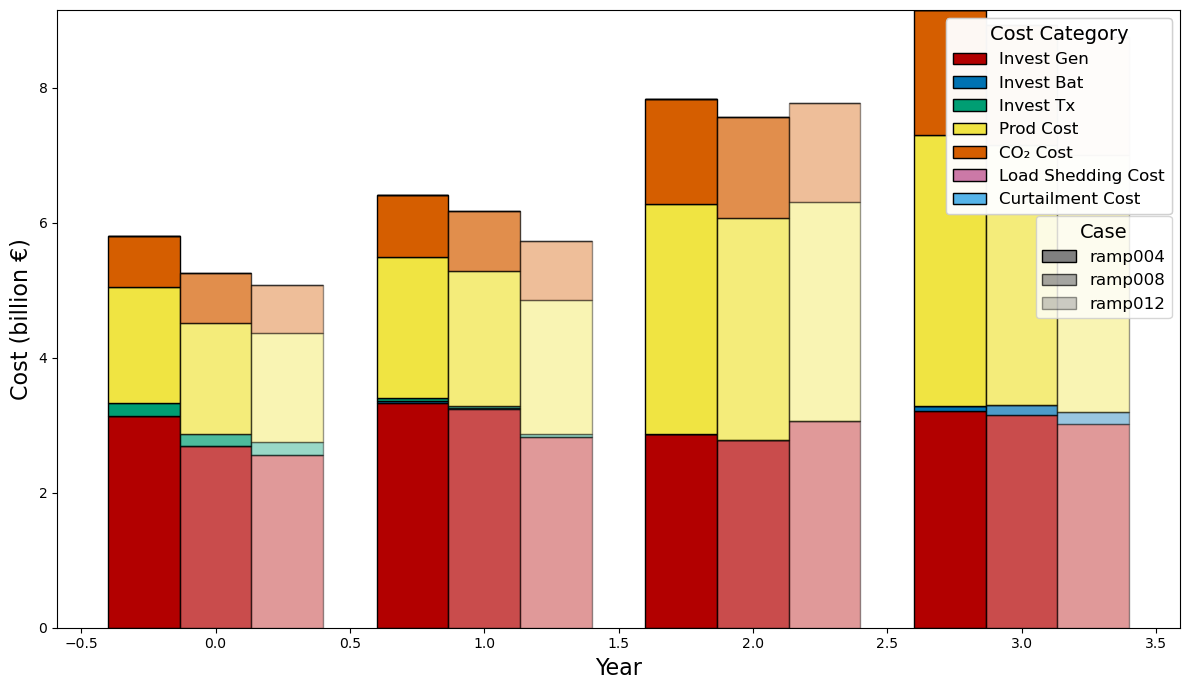

In [38]:
plot_yearly_costs_grouped_stacked(
    combined_by_cat, display_names, category_colors, savefolder=figures_folder
)

In [39]:
sys_sum = combined_by_cat["macro"]["system_summary_by_year"]
bat_sum = combined_by_cat["batteries"]["battery_system_summary_by_year"]
br_sum = combined_by_cat["branches"]["branch_buildout_summary_by_year"]
year_costs = combined_by_cat["macro"]["yearly_system_costs_by_scenario"]
cls = combined_by_cat["cls"]["curtailment_load_shedding_costs"]

# Generators & production

In [40]:
generators_figures_folder = os.path.join(savefolder, "generators", "figures")
os.makedirs(generators_figures_folder, exist_ok=True)
generators_tables_folder = os.path.join(savefolder, "generators", "tables")
os.makedirs(generators_tables_folder, exist_ok=True)

In [41]:
def plot_gen_investment_by_carrier_grouped(
    combined_by_cat: dict[str, dict[str, pd.DataFrame]],
    case_labels: list[str],
    savefolder: str | None = None,
) -> None:
    """
    Grouped & stacked bar chart of generator new‐capacity investments by carrier,
    for each Case, plus one “potential” bar with hatching at the end of each group.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    # --- 1) Flatten & aggregate ---
    df = combined_by_cat["extended_tables"]["extended_generators"].reset_index()
    invest = (
        df.groupby(["run", "year", "carrier", "nice_name", "color"])["new_capacity"]
        .sum()
        .div(1e3)  # convert to GW
        .reset_index()
    )
    last_case = case_labels[-1]
    pot = (
        df[df["run"] == last_case]
        .groupby(["year", "carrier", "nice_name", "color"])["extension_potential"]
        .sum()
        .div(1e3)  # to GW
        .reset_index()
    )

    # --- 2) Prep axes & metadata ---
    years = sorted(df["year"].unique())
    carriers = invest["carrier"].unique().tolist()
    meta = invest.set_index("carrier")[["nice_name", "color"]]

    n_cases = len(case_labels)
    bar_w = 0.8 / (n_cases + 1)  # +1 to make room for potential
    x = np.arange(len(years))
    offset = (n_cases - 1) / 2 * bar_w  # center of the cases
    pot_off = offset + bar_w  # potential bar sits one width to the right

    fig, ax = plt.subplots(figsize=(12, 7))

    # --- 3) Draw each Case’s stacked bars ---
    for i, case in enumerate(case_labels):
        sub = invest[invest["run"] == case]
        bottom = np.zeros(len(years))
        alpha = 1.0 - 0.6 * (i / (n_cases - 1)) if n_cases > 1 else 1.0
        for carrier in carriers:
            vals = [
                sub.loc[
                    (sub["year"] == yr) & (sub["carrier"] == carrier), "new_capacity"
                ].sum()
                for yr in years
            ]
            ax.bar(
                x + (i * bar_w) - offset,
                vals,
                bar_w,
                bottom=bottom,
                color=meta.loc[carrier, "color"].iloc[0],
                alpha=alpha,
                edgecolor="k",
                label=meta.loc[carrier, "nice_name"].iloc[0] if i == 0 else None,
            )
            bottom += vals

    # --- 4) Draw one potential bar per year at the end of each group ---
    bottom = np.zeros(len(years))
    for j, carrier in enumerate(carriers):
        vals = [
            pot.loc[
                (pot["year"] == yr) & (pot["carrier"] == carrier), "extension_potential"
            ].sum()
            for yr in years
        ]
        ax.bar(
            x + pot_off,
            vals,
            bar_w,
            bottom=bottom,
            color=meta.loc[carrier, "color"].iloc[0],
            edgecolor="k",
            hatch="///",
            label="Potential" if j == 0 else None,
        )
        bottom += vals

    # --- 5) Labels & axes ---
    ax.set_xticks(x)
    ax.set_xticklabels(years, fontsize=14)
    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel("Capacity Investment (GW)", fontsize=16)

    # --- 6a) Technology legend ---
    tech_handles = [
        Patch(facecolor=meta.loc[c, "color"].iloc[0], edgecolor="k") for c in carriers
    ]
    tech_labels = [meta.loc[c, "nice_name"].iloc[0] for c in carriers]
    leg1 = ax.legend(
        tech_handles,
        tech_labels,
        title="Technology",
        title_fontsize=14,
        fontsize=12,
        loc="upper right",
    )

    # --- 6b) Potential legend ---
    ax.add_artist(leg1)
    ax.legend(
        [Patch(facecolor="white", edgecolor="k", hatch="///")],
        ["Potential"],
        title="Type",
        title_fontsize=14,
        fontsize=12,
        loc="upper right",
        bbox_to_anchor=(1, 0.85),
    )

    # --- 6c) Case legend ---
    case_handles = [
        Patch(facecolor="gray", alpha=1.0 - 0.6 * (i / (n_cases - 1)), edgecolor="k")
        for i in range(n_cases)
    ]
    ax.add_artist(leg1)
    ax.legend(
        case_handles,
        case_labels,
        title="Case",
        title_fontsize=14,
        fontsize=12,
        loc="upper right",
        bbox_to_anchor=(1, 0.7),
    )

    plt.tight_layout()
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "gen_invest_by_carrier_grouped.png"),
            bbox_inches="tight",
        )

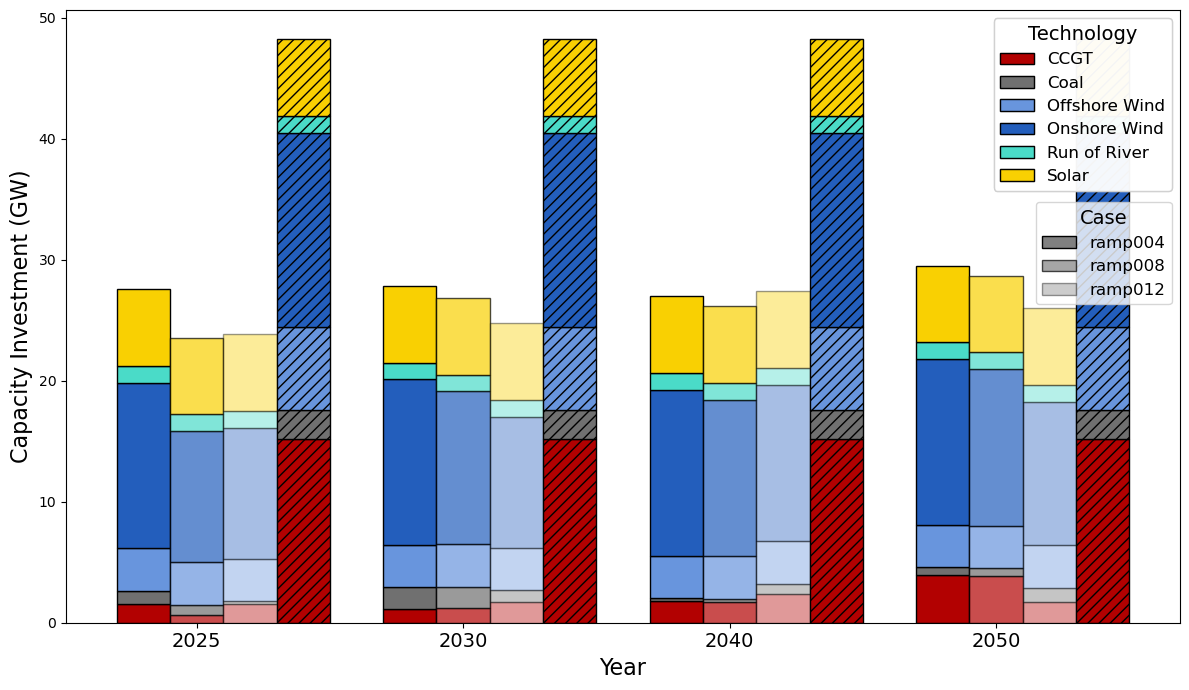

In [42]:
plot_gen_investment_by_carrier_grouped(
    combined_by_cat, display_names, savefolder=generators_figures_folder
)

In [43]:
def plot_gen_investment_spending_by_carrier_grouped(
    combined_by_cat: dict[str, dict[str, pd.DataFrame]],
    case_labels: list[str],
    savefolder: str | None = None,
) -> None:
    """
    Grouped & stacked bar chart of generator investment spending by carrier,
    for each Case and each year. Y-axis in billion €.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    # 1) Flatten & compute spending
    ext = combined_by_cat["extended_tables"]["extended_generators"].reset_index()
    ext["spend"] = ext["new_capacity"] * ext["capital_cost"]

    invest = (
        ext.groupby(["run", "year", "carrier", "nice_name", "color"])["spend"]
        .sum()
        .div(1e9)  # billion €
        .reset_index()
    )

    # 2) Prep
    years = sorted(invest["year"].unique())
    carriers = invest["carrier"].unique().tolist()
    meta = invest.set_index("carrier")[["nice_name", "color"]]

    n_cases = len(case_labels)
    bar_w = 0.8 / n_cases
    x = np.arange(len(years))
    offset = (n_cases - 1) / 2 * bar_w

    fig, ax = plt.subplots(figsize=(12, 7))

    # 3) Draw each Case
    for i, case in enumerate(case_labels):
        sub = invest[invest["run"] == case]
        bottom = np.zeros(len(years))
        alpha = 1.0 - 0.6 * (i / (n_cases - 1)) if n_cases > 1 else 1.0

        for carrier in carriers:
            vals = [
                sub.loc[
                    (sub["year"] == yr) & (sub["carrier"] == carrier), "spend"
                ].sum()
                for yr in years
            ]
            color = meta.loc[carrier, "color"].iloc[0]
            techname = meta.loc[carrier, "nice_name"].iloc[0]
            ax.bar(
                x + (i * bar_w) - offset,
                vals,
                bar_w,
                bottom=bottom,
                color=color,
                alpha=alpha,
                edgecolor="k",
                label=techname if i == 0 else None,
            )
            bottom += vals

    # 4) Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(years, fontsize=14)
    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel("Investment Spending (billion €)", fontsize=16)

    # 5a) Technology legend
    tech_handles = [
        Patch(facecolor=meta.loc[c, "color"].iloc[0], edgecolor="k") for c in carriers
    ]
    tech_labels = [meta.loc[c, "nice_name"].iloc[0] for c in carriers]
    leg1 = ax.legend(
        tech_handles,
        tech_labels,
        title="Technology",
        title_fontsize=14,
        fontsize=12,
        loc="upper right",
    )
    ax.add_artist(leg1)

    # 5b) Case legend
    case_handles = [
        Patch(facecolor="gray", alpha=1.0 - 0.6 * (i / (n_cases - 1)), edgecolor="k")
        for i in range(n_cases)
    ]
    ax.legend(
        case_handles,
        case_labels,
        title="Case",
        title_fontsize=14,
        fontsize=12,
        loc="upper right",
        bbox_to_anchor=(1, 0.70),
    )

    plt.tight_layout()
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "gen_invest_spending_by_carrier_grouped.png"),
            bbox_inches="tight",
        )

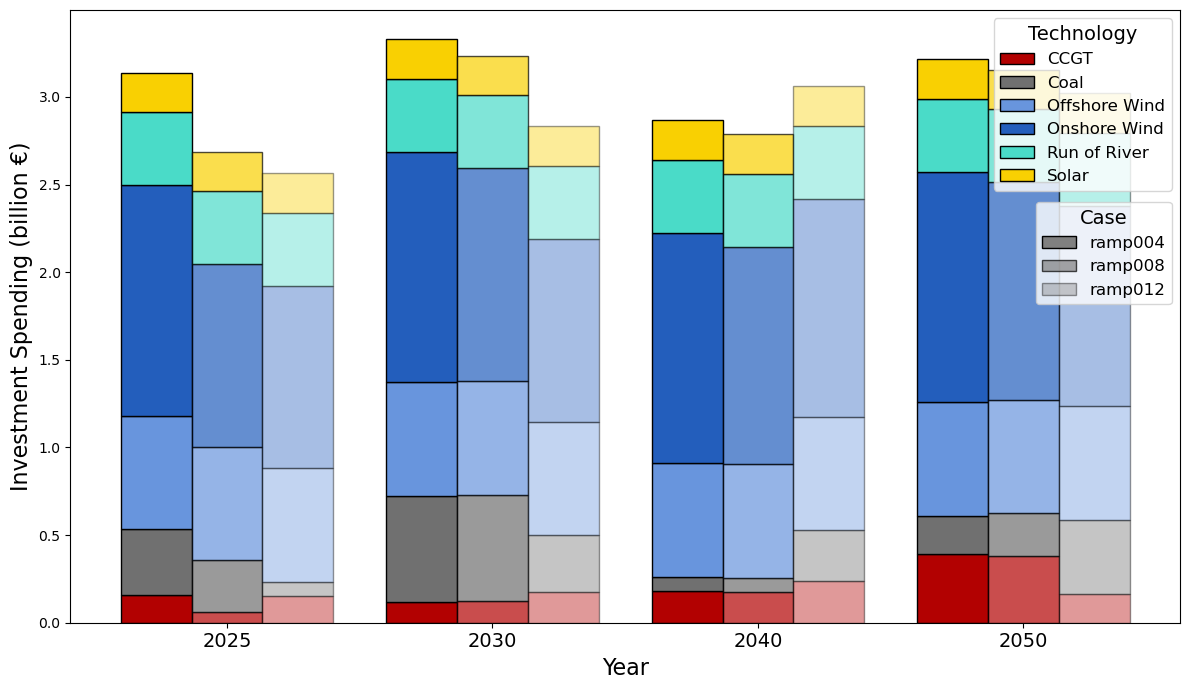

In [44]:
plot_gen_investment_spending_by_carrier_grouped(
    combined_by_cat, display_names, savefolder=generators_figures_folder
)

In [45]:
def plot_total_capacity_growth_grouped(
    combined_by_cat: dict[str, dict[str, pd.DataFrame]],
    case_labels: list[str],
    savefolder: str | None = None,
    max_opacity: float = 1.0,
    min_opacity: float = 0.4,
) -> None:
    """
    Grouped & stacked bar chart of total capacity growth (GW) by Case.

    For each Case and each year:
      - 'existing_capacity' = p_nom + cumulative prior new_capacity
      - 'new_capacity'      = new_capacity in that year

    Bars for different Cases sit side by side, with fading alpha.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    # 1) pull in the extended_generators table
    ext = combined_by_cat["extended_tables"]["extended_generators"].reset_index()

    years = sorted(ext["year"].unique())
    n_cases = len(case_labels)
    bar_w = 0.8 / n_cases
    x = np.arange(len(years))
    offset = (n_cases - 1) / 2 * bar_w

    # colors for existing / new
    col_exist = "#1b9e77"
    col_new = "#d95f02"

    # 2) for each Case, compute per-year sums (in GW)
    data = {}
    for case in case_labels:
        dfc = ext[ext["run"] == case].copy()
        # first‐year p_nom
        first = dfc[dfc["year"] == years[0]].set_index("generator")["p_nom"]
        # cumulative new
        dfc = dfc.sort_values(["generator", "year"])
        dfc["cum_new"] = dfc.groupby("generator")["new_capacity"].cumsum()
        dfc["existing"] = first.reindex(dfc["generator"]).values + (
            dfc["cum_new"] - dfc["new_capacity"]
        )
        # aggregate
        agg = (
            dfc.groupby("year")[["existing", "new_capacity"]].sum().loc[years]
            / 1e3  # -> GW
        )
        data[case] = agg

    # 3) plot
    fig, ax = plt.subplots(figsize=(12, 7))

    # draw bars
    for i, case in enumerate(case_labels):
        alpha = (
            max_opacity - (max_opacity - min_opacity) * (i / (n_cases - 1))
            if n_cases > 1
            else max_opacity
        )
        agg = data[case]
        ax.bar(
            x + (i * bar_w) - offset,
            agg["existing"].values,
            bar_w,
            color=col_exist,
            alpha=alpha,
            edgecolor="k",
            label="Existing Capacity" if i == 0 else None,
        )
        ax.bar(
            x + (i * bar_w) - offset,
            agg["new_capacity"].values,
            bar_w,
            bottom=agg["existing"].values,
            color=col_new,
            alpha=alpha,
            edgecolor="k",
            label="New Capacity" if i == 0 else None,
        )

    # 4) extend y-axis top
    # find maximal combined height across all cases
    max_total = max(
        (data[c]["existing"] + data[c]["new_capacity"]).max() for c in case_labels
    )
    ax.set_ylim(0, max_total * 1.1)

    # 5) axes & labels
    ax.set_xticks(x)
    ax.set_xticklabels(years, fontsize=14)
    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel("Capacity (GW)", fontsize=16)

    # 6a) Capacity‐type legend in top right
    cap_handles = [
        Patch(facecolor=col_exist, edgecolor="k"),
        Patch(facecolor=col_new, edgecolor="k"),
    ]
    cap_legend = ax.legend(
        cap_handles,
        ["Existing Capacity", "New Capacity"],
        title="Capacity Type",
        title_fontsize=14,
        fontsize=12,
        loc="upper right",
        bbox_to_anchor=(1.05, 1),
    )
    ax.add_artist(cap_legend)

    # 6b) Case legend, below
    case_handles = [
        Patch(
            facecolor="gray",
            alpha=(max_opacity - (max_opacity - min_opacity) * (i / (n_cases - 1))),
            edgecolor="k",
        )
        for i in range(n_cases)
    ]
    ax.legend(
        case_handles,
        case_labels,
        title="Case",
        title_fontsize=14,
        fontsize=12,
        loc="upper right",
        bbox_to_anchor=(1.05, 0.80),
    )

    plt.tight_layout()
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "total_capacity_growth_grouped.png"),
            bbox_inches="tight",
        )

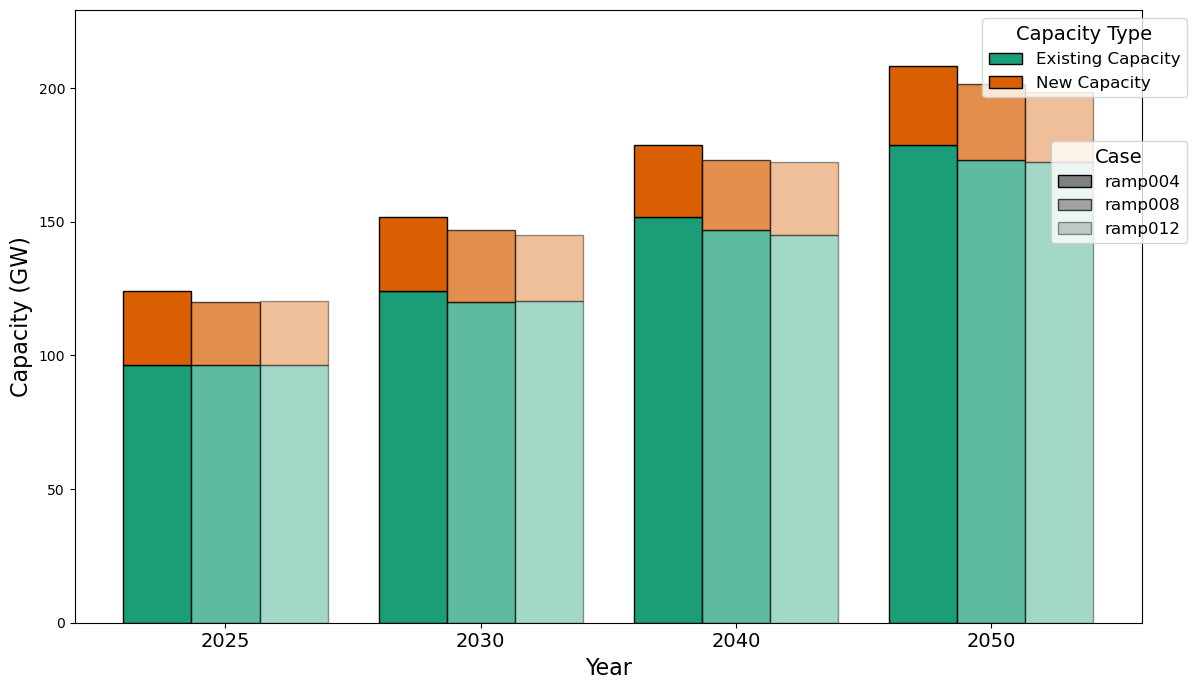

In [46]:
plot_total_capacity_growth_grouped(
    combined_by_cat, display_names, savefolder=generators_figures_folder
)

# Production & Emissions

In [47]:
def plot_utilization_by_year_scenario_carrier(
    util: pd.DataFrame,
    generators: pd.DataFrame,
    case_labels: list[str],
    savefolder: str | None = None,
) -> None:
    """
    Grouped bar chart of annual utilization factor by carrier, for each Case,
    with a 3-level x‐axis (year → scenario → carrier).

    util : pd.DataFrame
        Indexed by (run, year, scenario), columns are carriers, values are utilization factors.
    generators : pd.DataFrame
        Must contain 'carrier','nice_name','color' for each generator; we’ll drop duplicates.
    case_labels : list of str
        The names of each run/case, in the same order as the 'run' level of util.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    # --- 0) Extract carriers, colors, labels ---
    # we assume util.columns are carriers
    carriers = util.columns.tolist()
    meta = (
        generators.reset_index()[["carrier", "nice_name", "color"]]
        .drop_duplicates("carrier")
        .set_index("carrier")
    )
    colors = [meta.loc[c, "color"] for c in carriers]
    tech_labels = [meta.loc[c, "nice_name"] for c in carriers]

    # --- 1) Build list of (year,scenario) in the order they appear ---
    idx = util.index.to_list()  # [(run,year,scenario),...]
    runs = case_labels
    # but we want to group by year/scenario clusters, so:
    uniq_ys = []
    for _, y, s in idx:
        if (y, s) not in uniq_ys:
            uniq_ys.append((y, s))
    n_groups = len(uniq_ys)
    n_car = len(carriers)
    n_case = len(runs)

    # --- 2) Setup bar geometry ---
    total_width = 0.8
    width = total_width / (n_car * n_case)
    # positions of each group center
    group_centers = np.arange(n_groups)

    fig, ax = plt.subplots(figsize=(14, 6))

    # --- 3) Loop over carriers and cases ---
    for ci, carrier in enumerate(carriers):
        for ri, run in enumerate(runs):
            # x‐offset within each group
            offset = (ci * n_case + ri) - (n_car * n_case - 1) / 2
            xs = group_centers + offset * width

            # collect y‐values
            ys = []
            for y, s in uniq_ys:
                ys.append(util.loc[(run, y, s), carrier])

            alpha = 1.0 - (ri / (n_case - 1)) * 0.6 if n_case > 1 else 1.0

            ax.bar(
                xs,
                ys,
                width=width,
                label=run if (ci == 0) else None,
                color=colors[ci],
                alpha=alpha,
                edgecolor="k",
            )

    # --- 4) X‐tick labels at group centers ---
    tick_labels = [f"{y}\n{s}" for (y, s) in uniq_ys]
    ax.set_xticks(group_centers)
    ax.set_xticklabels(tick_labels, fontsize=12)
    ax.set_xlabel("Year / Scenario", fontsize=14)
    ax.set_ylabel("Utilization Factor", fontsize=14)

    # --- 5) Legends ---
    # Technology legend
    tech_handles = [Patch(facecolor=colors[i], edgecolor="k") for i in range(n_car)]
    leg1 = ax.legend(
        tech_handles,
        tech_labels,
        title="Technology",
        title_fontsize=12,
        fontsize=10,
        loc="upper right",
        bbox_to_anchor=(1.10, 1),
    )
    ax.add_artist(leg1)

    # Case legend
    case_handles = [
        Patch(facecolor="gray", alpha=(1.0 - (ri / (n_case - 1)) * 0.6), edgecolor="k")
        for ri in range(n_case)
    ]
    ax.legend(
        case_handles,
        runs,
        title="Case",
        title_fontsize=12,
        fontsize=10,
        loc="upper right",
        bbox_to_anchor=(1.10, 0.68),
    )

    plt.tight_layout()
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "utilization_by_case.png"), bbox_inches="tight"
        )

In [48]:
def make_utilization_table_from_decisions(
    generation_dvs: list[pd.DataFrame],
    run_labels: list[str],
    generators: pd.DataFrame,
    extended_generators: pd.DataFrame,
    capacity_factors: pd.DataFrame,
    week_weights: dict[str, float],
) -> pd.DataFrame:
    """
    Build annual utilization factors by carrier from raw 'generation' decision variables.

    Parameters
    ----------
    generation_dvs : list of pd.DataFrame
        One per run, each indexed by (generator, scenario, year, week, hour)
        with column 'value' in MWh.
    run_labels : list of str
        Names of each run (same order as generation_dvs).
    generators : pd.DataFrame
        Meta indexed by (year, generator): contains 'carrier'.
    extended_generators : pd.DataFrame
        Extended generator table indexed by (run, year, generator) with
        column 'total_capacity' (MW).
    capacity_factors : pd.DataFrame
        Hourly CFs indexed by (year, week, hour), columns=generator.
    week_weights : dict[str,float]
        Map week (as string) → weight to annualize.

    Returns
    -------
    util : pd.DataFrame
        Indexed by (run, year, scenario), columns are carriers,
        values are utilization factors (0–1).
    """
    import pandas as pd

    # --- 1) Actual annual generation per run/year/scenario/carrier ---
    actual_list = []
    for run_label, gen in zip(run_labels, generation_dvs):
        df = gen.reset_index().rename(columns={"value": "gen_mwh"})
        # map week → weight
        df["weight"] = df["week"].map(week_weights)
        df["annual_mwh"] = df["gen_mwh"] * df["weight"]
        # merge in carrier
        meta = generators.reset_index()[["year", "generator", "carrier"]]
        df = df.merge(meta, on=["year", "generator"], how="left")
        # aggregate
        df2 = (
            df.groupby(["scenario", "year", "carrier"])["annual_mwh"]
            .sum()
            .reset_index()
        )
        df2["run"] = run_label
        actual_list.append(df2)

    actual_all = pd.concat(actual_list, ignore_index=True)
    # now columns ['run','scenario','year','carrier','annual_mwh']

    # --- 2) Potential annual generation per run/year/carrier ---
    # 2a) annual capacity-factor sum per year×generator
    cf_weekly = capacity_factors.groupby(level=["year", "week"]).sum()
    w = pd.Series(week_weights).rename_axis("week").astype(float)
    w.index = w.index.astype(int)
    weighted_cf = cf_weekly.mul(w, axis=0, level="week")
    annual_cf = (
        weighted_cf.groupby(level="year")
        .sum()
        .stack()
        .reset_index(name="annual_cf")
        .rename(columns={"level_1": "generator"})
    )
    # 2b) bring in total_capacity per run/year/generator
    ext = extended_generators.reset_index()[
        ["run", "year", "generator", "total_capacity"]
    ]
    pot = ext.merge(annual_cf, on=["year", "generator"], how="left")
    pot["potential_mwh"] = pot["total_capacity"] * pot["annual_cf"]
    # 2c) merge in generator→carrier
    meta = generators.reset_index()[["year", "generator", "carrier"]]
    pot = pot.merge(meta, on=["year", "generator"], how="left")
    # 2d) aggregate to run/year/carrier
    pot2 = pot.groupby(["run", "year", "carrier"])["potential_mwh"].sum().reset_index()
    # pot2: ['run','year','carrier','potential_mwh']

    # --- 3) Combine actual & potential, compute util ---
    df = actual_all.merge(pot2, on=["run", "year", "carrier"], how="left")
    df["util"] = df["annual_mwh"] / df["potential_mwh"]

    # --- 4) Pivot to wide ---
    util = df.pivot_table(
        index=["run", "year", "scenario"],
        columns="carrier",
        values="util",
    )

    return util

In [49]:
capacity_factors = input_data["capacity_factors"]
week_weights = config["week_weights"]

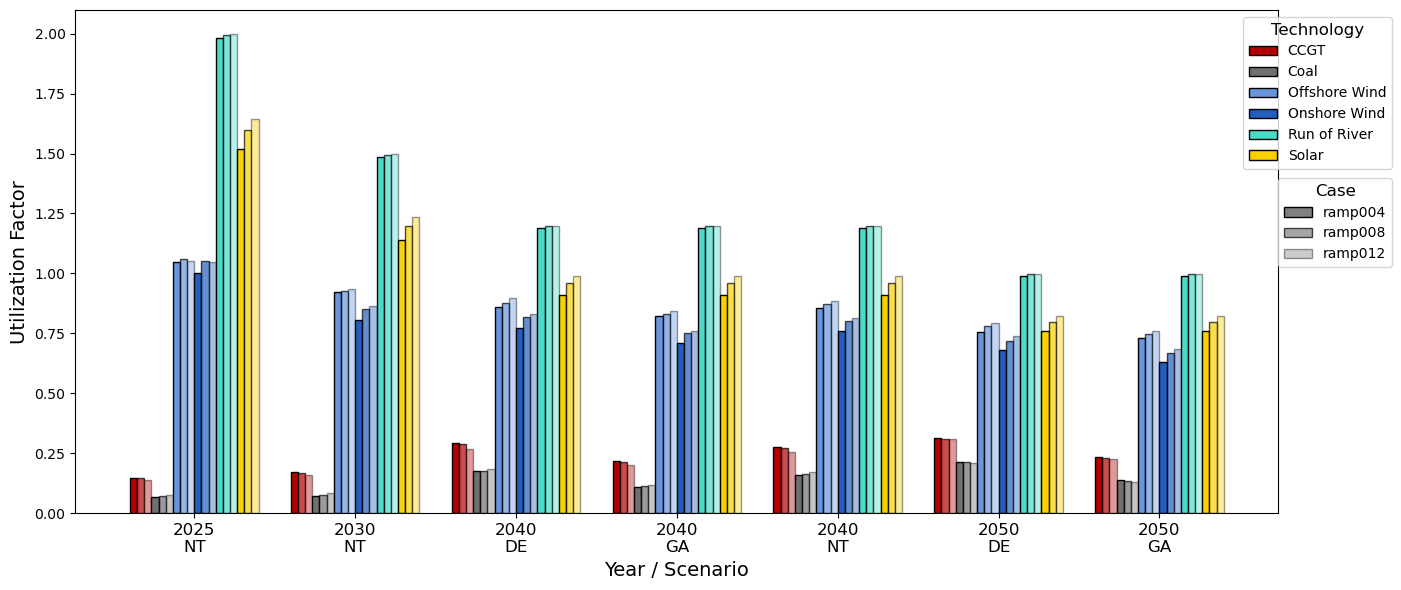

In [50]:
util_table = make_utilization_table_from_decisions(
    generation_dvs=generation_decision_variables_list,
    run_labels=display_names,
    generators=extended_tables["extended_generators"],
    extended_generators=extended_tables["extended_generators"],
    capacity_factors=capacity_factors,
    week_weights=week_weights,
)

# Now util_table.index.names == ['run','year','scenario']
# and util_table.columns are your carriers.

plot_utilization_by_year_scenario_carrier(
    util=util_table,
    generators=extended_tables["extended_generators"],
    case_labels=display_names,
    savefolder=generators_figures_folder,
)

In [51]:
def plot_utilization_by_year_carrier_avg(
    util: pd.DataFrame,
    generators: pd.DataFrame,
    case_labels: list[str],
    savefolder: str | None = None,
) -> None:
    """
    Grouped & stacked bar chart of annual average utilization by carrier, for each Case.
    Scenarios are first averaged out, so each bar represents mean across scenarios.

    Parameters
    ----------
    util : pd.DataFrame
        Indexed by (run, year, scenario), columns are carrier codes, values are util factors.
    generators : pd.DataFrame
        Must contain 'carrier','nice_name','color' per generator; we'll drop duplicates.
    case_labels : list of str
        Names of runs/cases in the same order as the 'run' level of util.
    savefolder : str or None
        Directory to save the figure; if None, not saved.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    # --- 1) Average over scenarios to get (run, year) × carrier
    util_avg = util.groupby(level=["run", "year"]).mean()

    # --- 2) Extract carriers & plotting metadata
    carriers = list(util_avg.columns)
    meta = (
        generators.reset_index()[["carrier", "nice_name", "color"]]
        .drop_duplicates("carrier")
        .set_index("carrier")
    )
    colors = [meta.loc[c, "color"] for c in carriers]
    tech_labels = [meta.loc[c, "nice_name"] for c in carriers]

    # --- 3) Determine geometry ---
    years = sorted({y for (_, y) in util_avg.index})
    n_cases = len(case_labels)
    n_car = len(carriers)
    total_width = 0.8
    bar_w = total_width / (n_car * n_cases)
    group_centers = np.arange(len(years))

    fig, ax = plt.subplots(figsize=(12, 6))

    # --- 4) Draw bars ---
    for ci, carrier in enumerate(carriers):
        for ri, case in enumerate(case_labels):
            # offset so that for each year, carriers are grouped and then cases within each carrier
            offset = (ci * n_cases + ri) - (n_car * n_cases - 1) / 2
            xs = group_centers + offset * bar_w

            ys = [util_avg.loc[(case, yr), carrier] for yr in years]
            alpha = 1.0 - (ri / (n_cases - 1)) * 0.6 if n_cases > 1 else 1.0

            ax.bar(
                xs,
                ys,
                width=bar_w,
                color=colors[ci],
                alpha=alpha,
                edgecolor="k",
                label=case if (ci == 0) else None,
            )

    # --- 5) Axes & ticks ---
    ax.set_xticks(group_centers)
    ax.set_xticklabels([str(y) for y in years], fontsize=12)
    ax.set_xlabel("Year", fontsize=14)
    ax.set_ylabel("Utilization Factor", fontsize=14)

    # --- 6) Legends ---
    # Technology legend
    tech_handles = [Patch(facecolor=colors[i], edgecolor="k") for i in range(n_car)]
    leg1 = ax.legend(
        tech_handles,
        tech_labels,
        title="Technology",
        title_fontsize=12,
        fontsize=10,
        loc="upper right",
        bbox_to_anchor=(1.0, 1),
    )
    ax.add_artist(leg1)

    # Case legend
    case_handles = [
        Patch(facecolor="gray", alpha=(1.0 - (ri / (n_cases - 1)) * 0.6), edgecolor="k")
        for ri in range(n_cases)
    ]
    ax.legend(
        case_handles,
        case_labels,
        title="Case",
        title_fontsize=12,
        fontsize=10,
        loc="upper right",
        bbox_to_anchor=(1, 0.7),
    )

    plt.tight_layout()
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "utilization_by_year_carrier_avg.png"),
            bbox_inches="tight",
        )

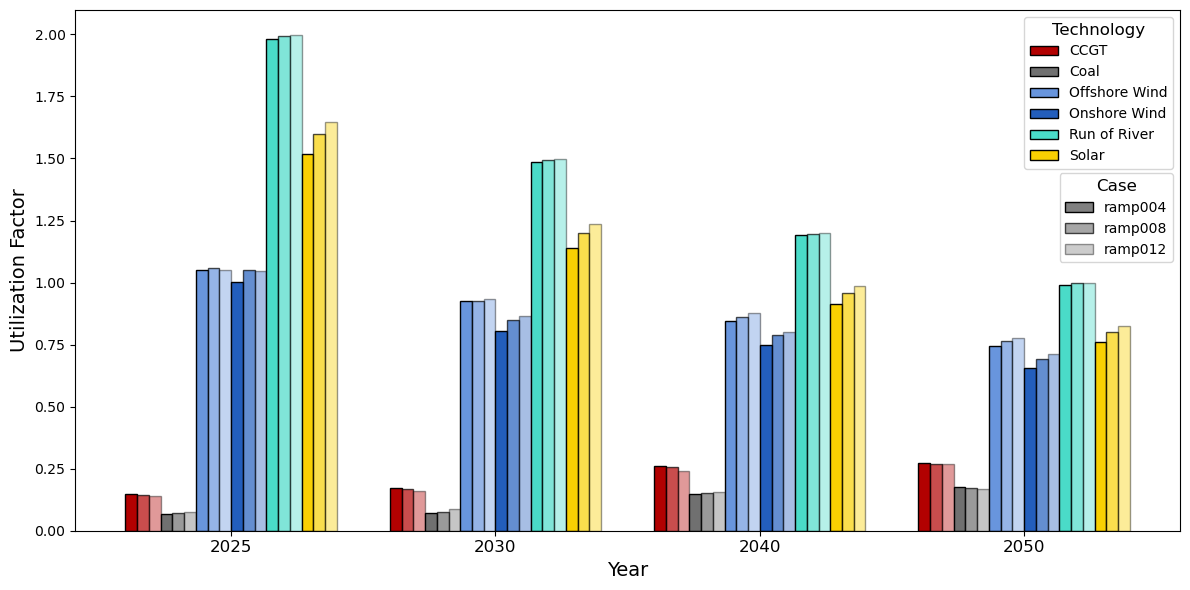

In [52]:
plot_utilization_by_year_carrier_avg(
    util=util_table,
    generators=extended_tables["extended_generators"],
    case_labels=display_names,
    savefolder=generators_figures_folder,
)

In [53]:
def plot_unused_capacity_by_year_carrier_avg(
    util: pd.DataFrame,
    generators: pd.DataFrame,
    case_labels: list[str],
    savefolder: str | None = None,
) -> None:
    """
    Grouped bar chart of annual average *unused* capacity by carrier, for each Case.
    Scenarios are first averaged out, so each bar represents mean across scenarios.

    Unused = 1 − utilization factor.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    # 1) Average over scenarios → (run,year)×carrier
    util_avg = util.groupby(level=["run", "year"]).mean()

    # 2) Compute unused fraction
    unused = 1.0 - util_avg

    # 3) carriers & colors
    carriers = list(unused.columns)
    meta = (
        generators.reset_index()[["carrier", "nice_name", "color"]]
        .drop_duplicates("carrier")
        .set_index("carrier")
    )
    colors = [meta.loc[c, "color"] for c in carriers]
    tech_labels = [meta.loc[c, "nice_name"] for c in carriers]

    # 4) bar geometry
    years = sorted({y for (_, y) in unused.index})
    n_cases = len(case_labels)
    n_car = len(carriers)
    total_width = 0.8
    bar_w = total_width / (n_car * n_cases)
    group_centers = np.arange(len(years))

    # 5) draw
    fig, ax = plt.subplots(figsize=(14, 6))
    for ci, carrier in enumerate(carriers):
        for ri, case in enumerate(case_labels):
            offset = (ci * n_cases + ri) - (n_car * n_cases - 1) / 2
            xs = group_centers + offset * bar_w
            ys = [unused.loc[(case, yr), carrier] for yr in years]
            alpha = 1.0 - (ri / (n_cases - 1)) * 0.6 if n_cases > 1 else 1.0
            ax.bar(
                xs,
                ys,
                width=bar_w,
                color=colors[ci],
                alpha=alpha,
                edgecolor="k",
                label=case if (ci == 0) else None,
            )

    # 6) labels & ticks
    ax.set_xticks(group_centers)
    ax.set_xticklabels([str(y) for y in years], fontsize=12)
    ax.set_xlabel("Year", fontsize=14)
    ax.set_ylabel("Unused Capacity Fraction", fontsize=14)
    fig.subplots_adjust(right=0.85)

    # 7a) Technology legend
    tech_handles = [Patch(facecolor=colors[i], edgecolor="k") for i in range(n_car)]
    leg1 = ax.legend(
        tech_handles,
        tech_labels,
        title="Technology",
        title_fontsize=12,
        fontsize=10,
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
    )

    # 7b) Case legend
    case_handles = [
        Patch(facecolor="gray", alpha=(1.0 - (ri / (n_cases - 1)) * 0.6), edgecolor="k")
        for ri in range(n_cases)
    ]
    ax.legend(
        case_handles,
        case_labels,
        title="Case",
        title_fontsize=12,
        fontsize=10,
        loc="upper right",
        bbox_to_anchor=(0.98, 0.68),
    )

    # re–add the tech legend
    ax.add_artist(leg1)

    plt.tight_layout()
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "unused_capacity_by_year_carrier_avg.png"),
            bbox_inches="tight",
        )

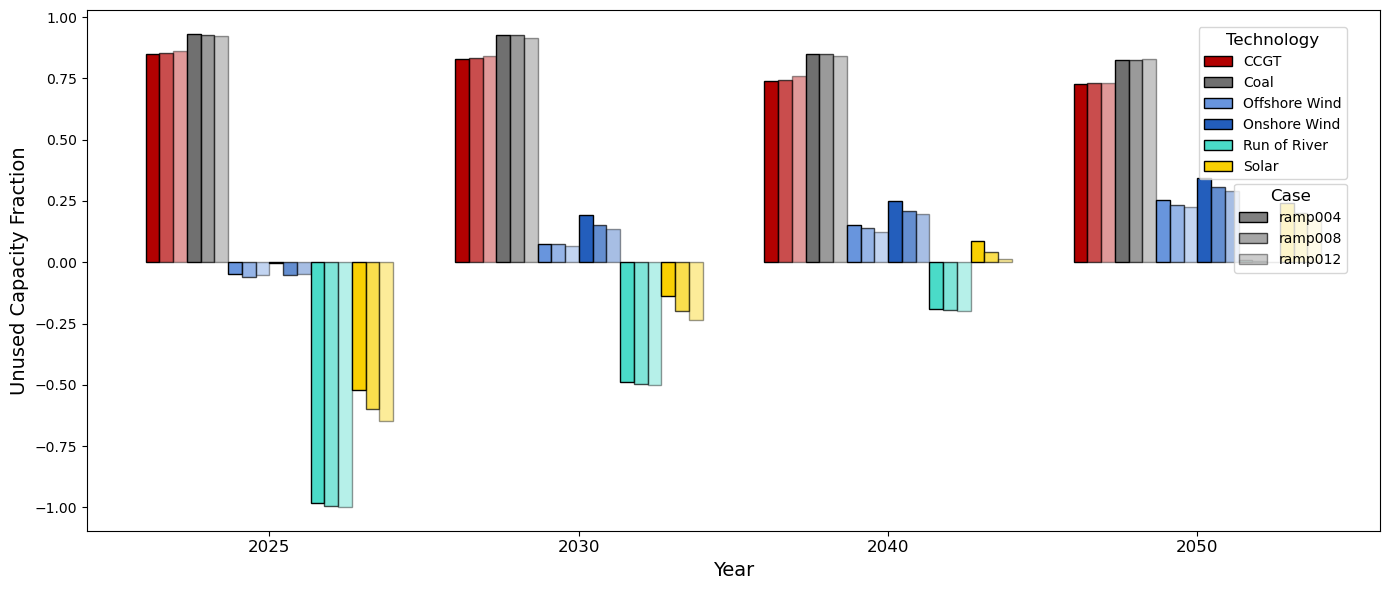

In [54]:
plot_unused_capacity_by_year_carrier_avg(
    util=util_table,
    generators=extended_tables["extended_generators"],
    case_labels=display_names,
    savefolder=generators_figures_folder,
)

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os


def plot_metric_by_year_scenario_case_with_avg(
    df_yearly: pd.DataFrame,
    metric: str,
    ylabel: str,
    scale: float,
    scenario_colors: dict[str, str],
    case_labels: list[str],
    max_opacity: float = 1.0,
    min_opacity: float = 0.4,
    savefolder: str | None = None,
    fname: str | None = None,
):
    """
    For each year, plot bars for each (scenario × case) that actually exists that year,
    then bars for the “Average” (per case), all packed tightly and centered under each year.

    df_yearly: MultiIndexed (run, year, scenario) with column `metric`.
    """

    # 1) flatten to DataFrame
    flat = df_yearly.reset_index()[["run", "year", "scenario", metric]]

    years = sorted(flat["year"].unique())
    n_cases = len(case_labels)

    fig, ax = plt.subplots(figsize=(10, 6))

    # 2) for each year build its own bar‐group
    for xi, year in enumerate(years):
        sub_year = flat[flat["year"] == year]
        # find which scenarios actually appear (non‐empty)
        scenarios = sorted(sub_year["scenario"].unique())
        # build a dict of values per case & scenario
        vals = {
            case: {
                sc: (
                    sub_year[(sub_year["run"] == case) & (sub_year["scenario"] == sc)][
                        metric
                    ].iloc[0]
                    / scale
                )
                for sc in scenarios
            }
            for case in case_labels
        }
        # compute per‐case average over just those scenarios
        for case in case_labels:
            arr = np.array(list(vals[case].values()))
            avg = arr.mean() if len(arr) > 0 else 0.0
            vals[case]["Average"] = avg

        levels = scenarios + ["Average"]
        n_lev = len(levels)
        bars = n_lev * n_cases

        # per‐year bar width so group spans ±0.4
        total_width = 0.8
        bw = total_width / bars
        center = xi  # x‐coordinate for this year

        # draw
        for li, lev in enumerate(levels):
            for ci, case in enumerate(case_labels):
                alpha = (
                    max_opacity
                    if n_cases == 1
                    else max_opacity
                    - (max_opacity - min_opacity) * (ci / (n_cases - 1))
                )
                # compute x offset
                offset = (li * n_cases + ci) - (bars - 1) / 2
                x = center + offset * bw
                h = vals[case][lev]
                color = "black" if lev == "Average" else scenario_colors[lev]
                ax.bar(
                    x,
                    h,
                    bw,
                    color=color,
                    alpha=alpha,
                    edgecolor="k",
                    label=case if (xi == 0 and li == 0) else None,
                )

    # 3) finalize axes
    ax.set_xticks(range(len(years)))
    ax.set_xticklabels([str(y) for y in years], fontsize=12)
    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)

    # 4) legend for scenarios + average
    # pick full superset of scenarios across all years (for consistent colors)
    all_scen = sorted(flat["scenario"].unique())
    handles = [Patch(facecolor=scenario_colors[s], edgecolor="k") for s in all_scen]
    labels = all_scen[:]
    handles.append(Patch(facecolor="black", edgecolor="k"))
    labels.append("Average")
    leg1 = ax.legend(
        handles,
        labels,
        title="Scenario",
        title_fontsize=14,
        fontsize=12,
        loc="upper right",
        bbox_to_anchor=(1.10, 1),
    )
    ax.add_artist(leg1)

    # 5) legend for cases
    case_handles = [
        Patch(
            facecolor="gray",
            edgecolor="k",
            alpha=(
                max_opacity
                if n_cases == 1
                else max_opacity - (max_opacity - min_opacity) * (ci / (n_cases - 1))
            ),
        )
        for ci in range(n_cases)
    ]
    ax.legend(
        case_handles,
        case_labels,
        title="Case",
        title_fontsize=14,
        fontsize=12,
        loc="upper right",
        bbox_to_anchor=(1.10, 0.75),
    )

    plt.tight_layout()
    plt.show()

    if savefolder:
        fname = fname or f"{metric}_by_year_case_scenario_avg.png"
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")

In [56]:
yearly = combined_by_cat["macro"]["yearly_system_costs_by_scenario"]
cases = display_names
figures_folder = generators_figures_folder  # or wherever
yearly

year scenario    production  co2_emission  co2_emission_cost  \
run                                                                       
ramp004 0  2025       NT  2.745757e+08  9.528431e+06       7.622745e+08   
        1  2030       NT  2.940258e+08  1.162482e+07       9.299857e+08   
        2  2040       DE  3.672301e+08  2.199195e+07       1.759356e+09   
        3  2040       GA  3.265716e+08  1.587891e+07       1.270312e+09   
        4  2040       NT  3.585420e+08  2.061253e+07       1.649003e+09   
        5  2050       DE  3.964182e+08  2.680099e+07       2.144080e+09   
        6  2050       GA  3.514710e+08  1.942198e+07       1.553758e+09   
ramp008 0  2025       NT  2.746045e+08  9.128589e+06       7.302871e+08   
        1  2030       NT  2.941442e+08  1.120132e+07       8.961056e+08   
        2  2040       DE  3.673930e+08  2.119050e+07       1.695240e+09   
        3  2040       GA  3.267224e+08  1.526891e+07       1.221513e+09   
        4  2040       NT  3.586976e+08  1.986269e+07       1.589015e+09   
        5  2050       DE  3.965290e+08  2.588310e+07       2.070648e+09   
        6  2050       GA  3.515880e+08  1.859707e+07       1.487765e+09   
ramp012 0  2025       NT  2.746179e+08  8.973186e+06       7.178549e+08   
        1  2030       NT  2.941430e+08  1.102711e+07       8.821687e+08   
        2  2040       DE  3.674060e+08  2.081373e+07       1.665099e+09   
        3  2040       GA  3.267329e+08  1.498251e+07       1.198601e+09   
        4  2040       NT  3.587105e+08  1.950414e+07       1.560331e+09   
        5  2050       DE  3.965165e+08  2.541900e+07       2.033520e+09   
        6  2050       GA  3.515834e+08  1.818606e+07       1.454885e+09   

           production_cost  production_cost_with_emission  
run                                                        
ramp004 0     1.723497e+09                   2.485771e+09  
        1     2.081011e+09                   3.010996e+09  
        2     3.832204e+09                   5.591560e+09  
        3     2.804554e+09                   4.074866e+09  
        4     3.598080e+09                   5.247083e+09  
        5     4.637609e+09                   6.781689e+09  
        6     3.400205e+09                   4.953963e+09  
ramp008 0     1.643445e+09                   2.373733e+09  
        1     1.999766e+09                   2.895872e+09  
        2     3.689286e+09                   5.384526e+09  
        3     2.692301e+09                   3.913814e+09  
        4     3.464320e+09                   5.053335e+09  
        5     4.468188e+09                   6.538836e+09  
        6     3.254132e+09                   4.741897e+09  
ramp012 0     1.620701e+09                   2.338556e+09  
        1     1.977001e+09                   2.859169e+09  
        2     3.643408e+09                   5.308507e+09  
        3     2.655333e+09                   3.853934e+09  
        4     3.420807e+09                   4.981139e+09  
        5     4.409851e+09                   6.443371e+09  
        6     3.201806e+09                   4.656690e+09

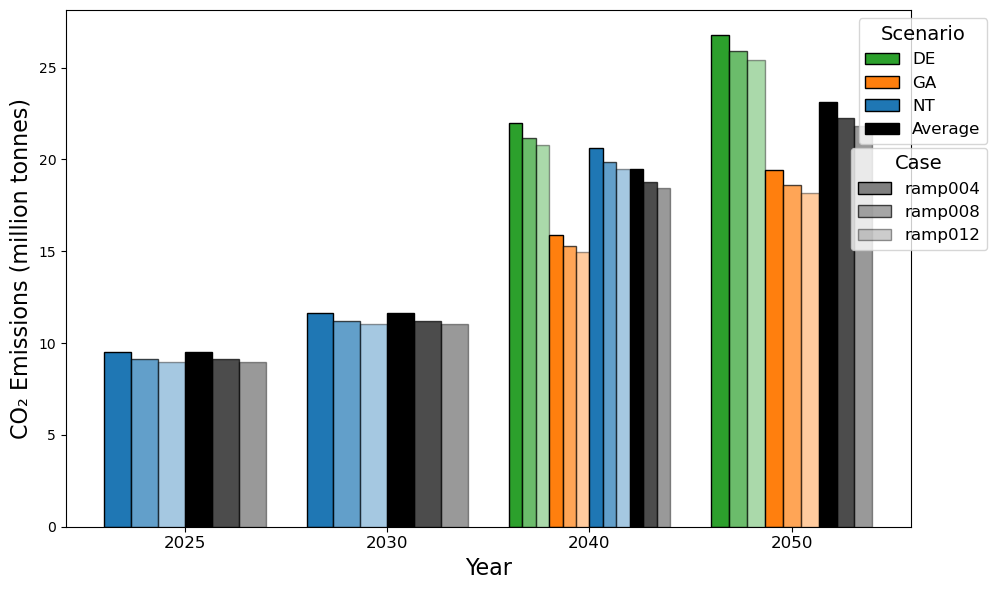

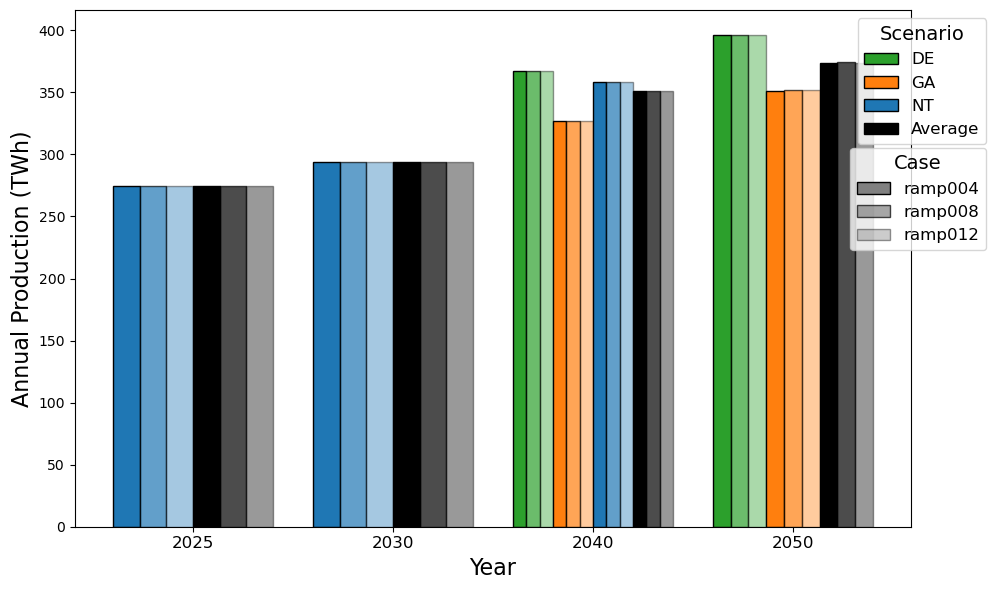

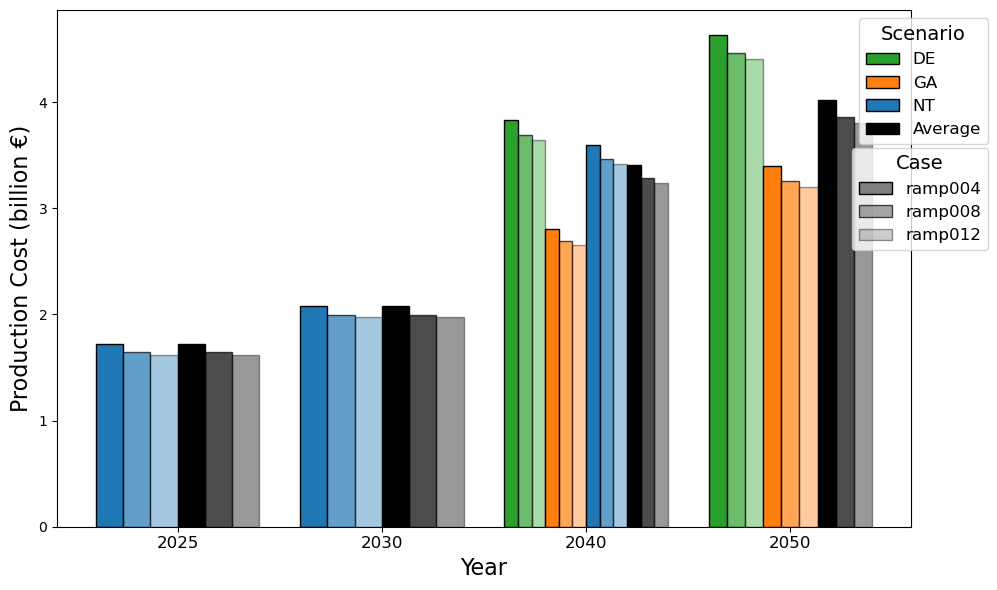

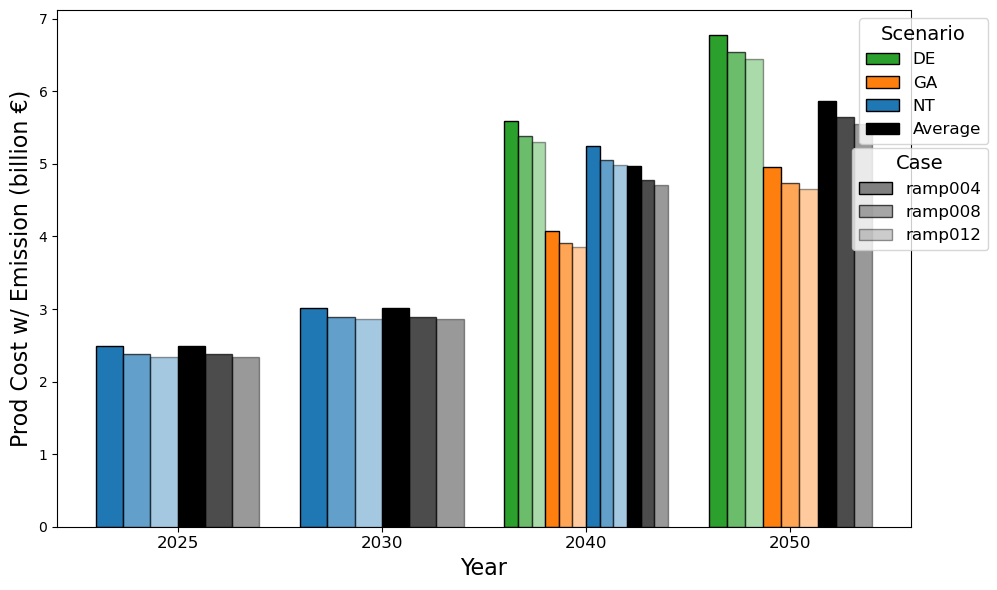

In [57]:
yearly = combined_by_cat["macro"]["yearly_system_costs_by_scenario"]
scenario_colors = {"NT": "#1f77b4", "GA": "#ff7f0e", "DE": "#2ca02c"}
cases = display_names  # ["Base","No Battery"]

# CO₂ Emissions
plot_metric_by_year_scenario_case_with_avg(
    df_yearly=yearly,
    metric="co2_emission",
    ylabel="CO₂ Emissions (million tonnes)",
    scale=1e6,
    scenario_colors=scenario_colors,
    case_labels=cases,
    savefolder=figures_folder,
    fname="co2_emissions_grouped.png",
)

# Annual Production
plot_metric_by_year_scenario_case_with_avg(
    df_yearly=yearly,
    metric="production",
    ylabel="Annual Production (TWh)",
    scale=1e6,
    scenario_colors=scenario_colors,
    case_labels=cases,
    savefolder=figures_folder,
    fname="production_grouped.png",
)

# Production Cost
plot_metric_by_year_scenario_case_with_avg(
    df_yearly=yearly,
    metric="production_cost",
    ylabel="Production Cost (billion €)",
    scale=1e9,
    scenario_colors=scenario_colors,
    case_labels=cases,
    savefolder=figures_folder,
    fname="prod_cost_grouped.png",
)

# Production Cost w/ Emissions
plot_metric_by_year_scenario_case_with_avg(
    df_yearly=yearly,
    metric="production_cost_with_emission",
    ylabel="Prod Cost w/ Emission (billion €)",
    scale=1e9,
    scenario_colors=scenario_colors,
    case_labels=cases,
    savefolder=figures_folder,
    fname="prod_cost_em_grouped.png",
)

In [58]:
yearly = combined_by_cat["macro"]["yearly_system_costs_by_scenario"]

# Transmission Lines

In [59]:
branches_figures_folder = os.path.join(savefolder, "branches", "figures")
os.makedirs(branches_figures_folder, exist_ok=True)
branches_tables_folder = os.path.join(savefolder, "branches", "tables")
os.makedirs(branches_tables_folder, exist_ok=True)

In [60]:
# Helper to print heads of all tables in a dictionary
def print_table_heads(tables_dict, dict_name):
    print(f"\n==== {dict_name} ====")
    for name, df in tables_dict.items():
        print(f"\n{name}:")
        print(df.head())
        print("-" * 60)


# # Print heads for all categories
# print_table_heads(battery_tables, "Battery tables")
# print_table_heads(branches_tables, "Branch tables")
# print_table_heads(extended_tables, "Extended tables")
# print_table_heads(generators_tables, "Generator tables")
# print_table_heads(macro_tables, "Macro tables")
# print_table_heads(duals_tables, "Duals tables")
# print_table_heads(cls_tables, "CLS tables")

In [61]:
def plot_transmission_investments_by_year(
    branches_tables: dict,
    case_labels: list[str],
    savefolder: str = None,
    max_opacity: float = 1.0,
    min_opacity: float = 0.4,
    color: str = "#0082c8",  # Choose your preferred color for Tx
    fname: str = None,
):
    """
    Bar plot of annual new transmission investment (Billion €) for each case, by year.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    from matplotlib.patches import Patch

    # 1. Load and flatten the relevant table
    br_sum = branches_tables["branch_buildout_summary_by_year"].reset_index()

    # 2. Group by run and year, sum investment, convert to Billion €
    inv_tx = (
        br_sum.groupby(["run", "year"])["cost_of_buildout"].sum().unstack(0) / 1e9
    )  # shape: (year, run)

    # 3. Prepare plot parameters
    years = inv_tx.index.tolist()
    n_cases = len(case_labels)
    bar_w = 0.8 / n_cases
    x = np.arange(len(years))

    fig, ax = plt.subplots(figsize=(10, 6))

    # 4. Draw bars, one per run/case
    for i, case in enumerate(case_labels):
        if case not in inv_tx.columns:
            continue
        alpha = (
            max_opacity - (max_opacity - min_opacity) * (i / (n_cases - 1))
            if n_cases > 1
            else max_opacity
        )
        vals = inv_tx[case].values
        ax.bar(
            x + (i - (n_cases - 1) / 2) * bar_w,
            vals,
            bar_w,
            color=color,
            alpha=alpha,
            edgecolor="k",
            label=case,
        )

    # 5. Axes labels and legend
    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel("Investment (Billion €)", fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(years, fontsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Legend for Case
    handles = [
        Patch(
            facecolor=color,
            alpha=max_opacity - (max_opacity - min_opacity) * (i / (n_cases - 1)),
            edgecolor="k",
        )
        for i in range(n_cases)
    ]
    ax.legend(
        handles,
        case_labels,
        title="Case",
        title_fontsize=14,
        fontsize=12,
        loc="upper right",
    )

    plt.tight_layout()
    plt.show()

    if savefolder:
        fname = fname or "annual_transmission_investments.png"
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")

In [62]:
def plot_transmission_capacity_by_year(
    branches_tables: dict,
    case_labels: list[str],
    savefolder: str = None,
    max_opacity: float = 1.0,
    min_opacity: float = 0.4,
    color: str = "#fabd2f",  # Use a distinct color for capacity (change as preferred)
    fname: str = None,
):
    """
    Bar plot of annual new transmission capacity (MW) for each case, by year.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    from matplotlib.patches import Patch

    # 1. Load and flatten the relevant table
    br_sum = branches_tables["branch_buildout_summary_by_year"].reset_index()

    # 2. Group by run and year, sum new capacity (MW)
    cap_tx = (
        br_sum.groupby(["run", "year"])["new_capacity"].sum().unstack(0)
    )  # shape: (year, run)

    # 3. Prepare plot parameters
    years = cap_tx.index.tolist()
    n_cases = len(case_labels)
    bar_w = 0.8 / n_cases
    x = np.arange(len(years))

    fig, ax = plt.subplots(figsize=(10, 6))

    # 4. Draw bars, one per run/case
    for i, case in enumerate(case_labels):
        if case not in cap_tx.columns:
            continue
        alpha = (
            max_opacity - (max_opacity - min_opacity) * (i / (n_cases - 1))
            if n_cases > 1
            else max_opacity
        )
        vals = cap_tx[case].values
        ax.bar(
            x + (i - (n_cases - 1) / 2) * bar_w,
            vals,
            bar_w,
            color=color,
            alpha=alpha,
            edgecolor="k",
            label=case,
        )

    # 5. Axes labels and legend
    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel("New Transmission Capacity (MW)", fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(years, fontsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Legend for Case
    handles = [
        Patch(
            facecolor=color,
            alpha=max_opacity - (max_opacity - min_opacity) * (i / (n_cases - 1)),
            edgecolor="k",
        )
        for i in range(n_cases)
    ]
    ax.legend(
        handles,
        case_labels,
        title="Case",
        title_fontsize=14,
        fontsize=12,
        loc="upper right",
    )

    plt.tight_layout()
    plt.show()

    if savefolder:
        fname = fname or "annual_transmission_capacity.png"
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")

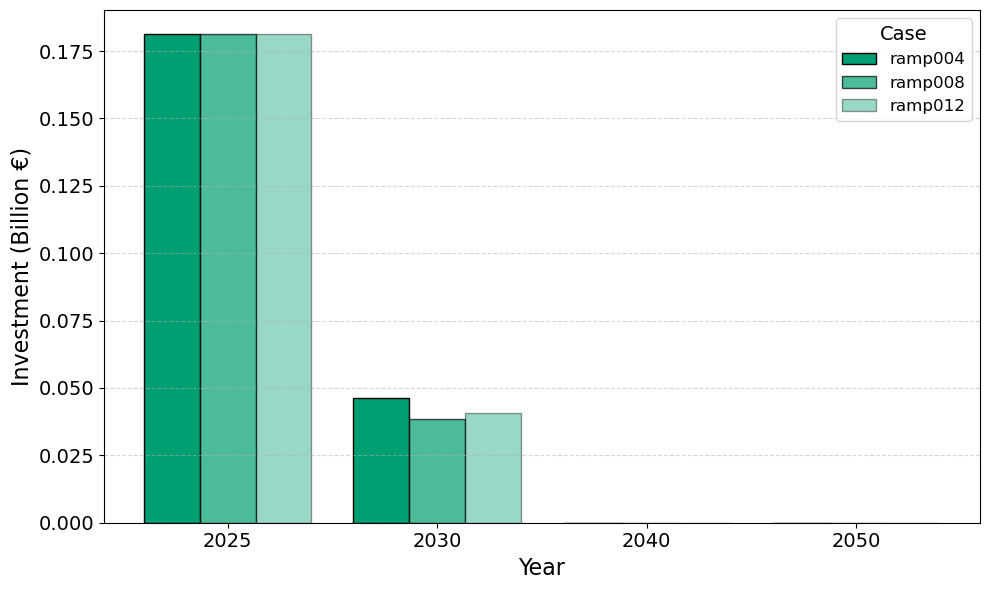

In [63]:
plot_transmission_investments_by_year(
    branches_tables,
    display_names,
    savefolder=branches_figures_folder,
    color=category_colors["Invest Tx"],
)

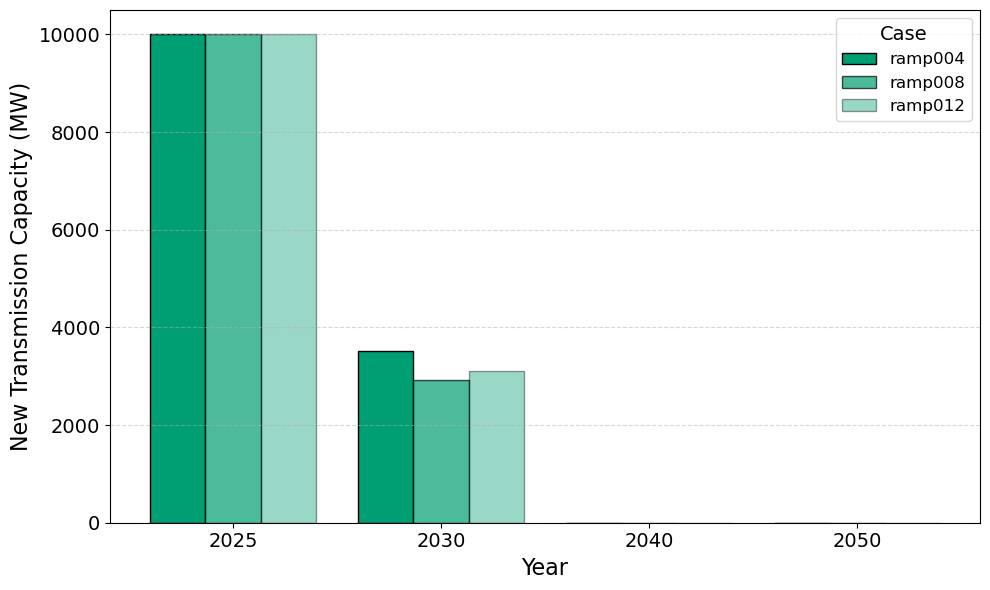

In [64]:
plot_transmission_capacity_by_year(
    branches_tables,
    display_names,
    savefolder=branches_figures_folder,
    color=category_colors["Invest Tx"],
)

In [65]:
def plot_tx_utilization_and_congestion_by_year_scenario(
    branches_tables: dict,
    case_labels: list[str],
    savefolder: str = None,
    max_opacity: float = 1.0,
    min_opacity: float = 0.4,
    utilization_color: str = "#0072b2",  # Blue for utilization
    congestion_color: str = "#d55e00",  # Orange for congestion
    fname: str = None,
):
    """
    Bar plot of avg. transmission utilization and congestion rates (%),
    grouped by year-scenario, side by side for each case.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    from matplotlib.patches import Patch

    # 1. Load and flatten the relevant table
    agg = branches_tables["aggregate_branch_flow_summary"].reset_index()

    # 2. Group: mean utilization/congestion per (run, year, scenario)
    df = (
        agg.groupby(["run", "year", "scenario"])[
            ["utilization_rate", "congestion_rate"]
        ]
        .mean()
        .reset_index()
    )

    # 3. Create combined (year, scenario) labels and sort
    df["year_scen"] = df["year"].astype(str) + "-" + df["scenario"]
    x_labels = df[["year", "scenario"]].drop_duplicates()
    x_labels["year_scen"] = x_labels["year"].astype(str) + "-" + x_labels["scenario"]
    x_labels = x_labels.sort_values(["year", "scenario"])
    x_tick_labels = x_labels["year_scen"].tolist()

    x_pos = np.arange(len(x_tick_labels))
    n_cases = len(case_labels)
    bar_w = (
        0.35 / n_cases
    )  # Utilization and congestion are plotted side by side in pairs
    bar_gap = 0.4  # Gap between utilization/congestion bars for same group

    fig, ax = plt.subplots(figsize=(16, 7))

    # 4. Draw bars
    for i, case in enumerate(case_labels):
        sub = df[df["run"] == case]
        # Create arrays of utilization/congestion (as percentage)
        util_vals = np.zeros(len(x_tick_labels))
        cong_vals = np.zeros(len(x_tick_labels))
        for j, lbl in enumerate(x_tick_labels):
            row = sub[sub["year_scen"] == lbl]
            if not row.empty:
                util_vals[j] = row["utilization_rate"].values[0] * 100
                cong_vals[j] = row["congestion_rate"].values[0] * 100
            else:
                util_vals[j] = np.nan
                cong_vals[j] = np.nan
        alpha = (
            max_opacity - (max_opacity - min_opacity) * (i / (n_cases - 1))
            if n_cases > 1
            else max_opacity
        )
        # Utilization bars
        ax.bar(
            x_pos - bar_gap / 2 + i * bar_w,
            util_vals,
            bar_w,
            color=utilization_color,
            alpha=alpha,
            edgecolor="k",
            label=f"Utilization - {case}" if i == 0 else None,
        )
        # Congestion bars
        ax.bar(
            x_pos + bar_gap / 2 + i * bar_w,
            cong_vals,
            bar_w,
            color=congestion_color,
            alpha=alpha,
            edgecolor="k",
            label=f"Congestion - {case}" if i == 0 else None,
        )

    # 5. Labels and legend
    ax.set_xlabel("Year - Scenario", fontsize=16)
    ax.set_ylabel("Rate (%)", fontsize=16)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_tick_labels, fontsize=14, rotation=30, ha="right")
    ax.tick_params(axis="y", labelsize=14)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Custom legend for case opacity (as per your style)
    util_patch = Patch(facecolor=utilization_color, edgecolor="k", label="Utilization")
    cong_patch = Patch(facecolor=congestion_color, edgecolor="k", label="Congestion")
    case_patches = [
        Patch(
            facecolor="gray",
            alpha=max_opacity - (max_opacity - min_opacity) * (i / (n_cases - 1)),
            edgecolor="k",
        )
        for i in range(n_cases)
    ]
    legend1 = ax.legend(
        [util_patch, cong_patch],
        ["Utilization", "Congestion"],
        title="Metric",
        title_fontsize=14,
        fontsize=12,
        loc="upper right",
    )
    ax.add_artist(legend1)
    ax.legend(
        case_patches,
        case_labels,
        title="Case",
        title_fontsize=14,
        fontsize=12,
        loc="upper right",
        bbox_to_anchor=(1, 0.76),
    )

    plt.tight_layout()
    plt.show()

    if savefolder:
        fname = fname or "utilization_congestion_by_year_scenario.png"
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")

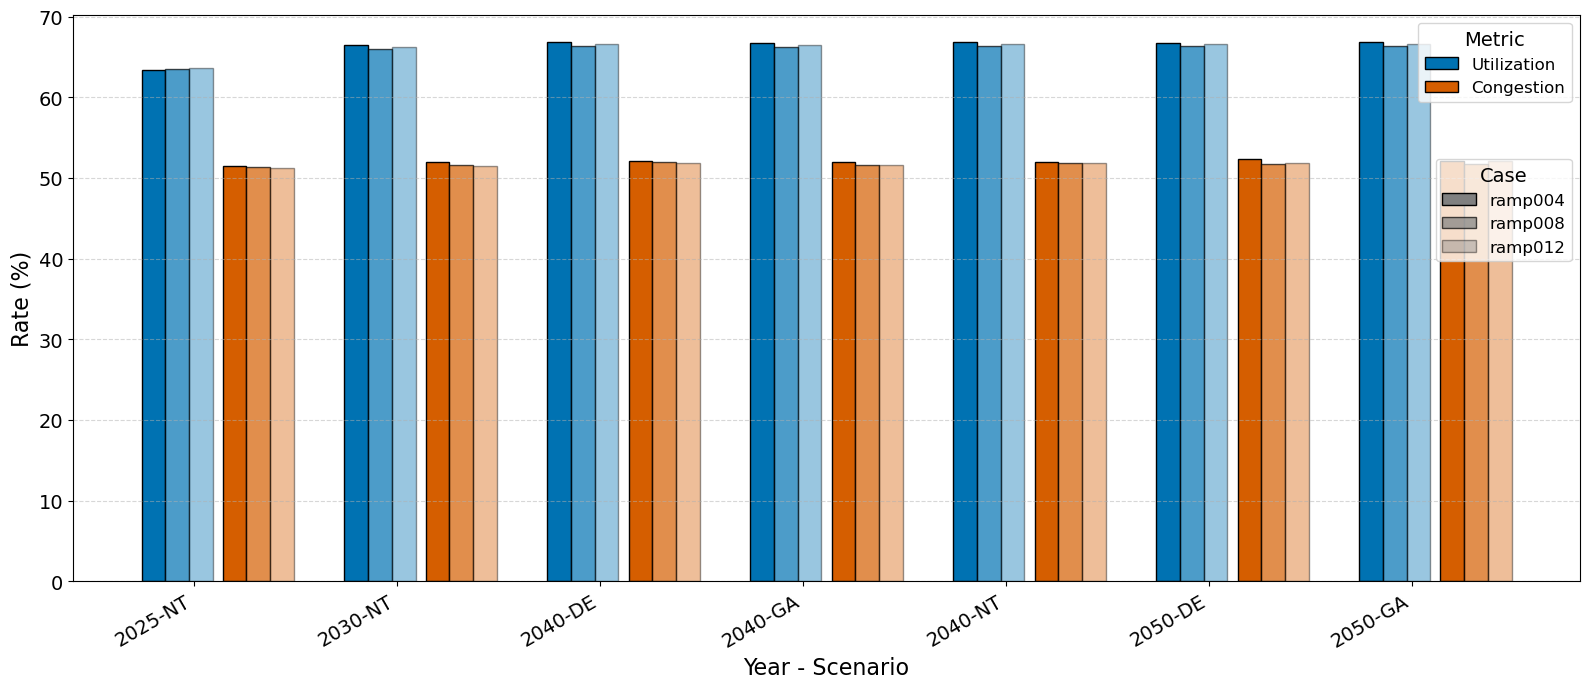

In [66]:
plot_tx_utilization_and_congestion_by_year_scenario(
    branches_tables,
    display_names,
    savefolder=branches_figures_folder,
    utilization_color="#0072b2",  # Or use category_colors if desired
    congestion_color="#d55e00",  # Or use category_colors if desired
)

In [67]:
def save_tx_utilization_congestion_table(
    branches_tables: dict,
    case_labels: list[str],
    savefolder: str = None,
    fname: str = None,
):
    """
    Saves a table of avg. transmission utilization and congestion rates (%) by case, year, scenario.
    Output: CSV table (or optionally Excel/LaTeX) in savefolder.
    """
    import os

    # 1. Load and flatten the relevant table
    agg = branches_tables["aggregate_branch_flow_summary"].reset_index()

    # 2. Group: mean utilization/congestion per (run, year, scenario)
    df = (
        agg.groupby(["run", "year", "scenario"])[
            ["utilization_rate", "congestion_rate"]
        ]
        .mean()
        .reset_index()
    )

    # 3. Reorder and format columns
    df = df[df["run"].isin(case_labels)]
    df["utilization_rate (%)"] = (df["utilization_rate"] * 100).round(2)
    df["congestion_rate (%)"] = (df["congestion_rate"] * 100).round(2)
    df = df[["run", "year", "scenario", "utilization_rate (%)", "congestion_rate (%)"]]
    df = df.rename(columns={"run": "Case", "year": "Year", "scenario": "Scenario"})

    # 4. Sort
    df = df.sort_values(["Case", "Year", "Scenario"])

    # 5. Save as CSV (or Excel/LaTeX)
    if savefolder:
        fname = fname or "utilization_congestion_by_year_scenario.csv"
        df.to_csv(os.path.join(savefolder, fname), index=False)

    return df  # Optionally return for display/inspection

In [68]:
util_cong_table = save_tx_utilization_congestion_table(
    branches_tables,
    display_names,
    savefolder=branches_tables_folder,
)
util_cong_table

,Case,Year,Scenario,utilization_rate (%),congestion_rate (%)
0,ramp004,2025,NT,63.43,51.50
1,ramp004,2030,NT,66.45,52.02
2,ramp004,2040,DE,66.88,52.15
3,ramp004,2040,GA,66.71,51.93
4,ramp004,2040,NT,66.84,51.94
5,ramp004,2050,DE,66.78,52.37
6,ramp004,2050,GA,66.84,52.15
7,ramp008,2025,NT,63.49,51.32
8,ramp008,2030,NT,65.96,51.58
9,ramp008,2040,DE,66.39,51.93


In [69]:
branches_tables["branch_buildout_summary_by_year"].head()

year  potential_capacity  new_capacity  number_possible_buildouts  \
run                                                                            
ramp004 0  2025               95000  10000.000000                         19   
        1  2030               95000   3523.734959                         19   
        2  2040               95000      0.000000                         19   
        3  2050               95000      0.000000                         19   
ramp008 0  2025               95000  10000.000000                         19   

           number_actual_buildouts  cost_of_buildout  
run                                                   
ramp004 0                        2      1.811723e+08  
        1                        1      4.627194e+07  
        2                        0      0.000000e+00  
        3                        0      0.000000e+00  
ramp008 0                        2      1.811723e+08

# Batteries

In [70]:
batteries_figures_folder = os.path.join(savefolder, "batteries", "figures")
os.makedirs(batteries_figures_folder, exist_ok=True)
batteries_tables_folder = os.path.join(savefolder, "batteries", "tables")
os.makedirs(batteries_tables_folder, exist_ok=True)

In [71]:
def plot_battery_capacity_and_investment_dual_axis(
    battery_tables: dict,
    case_label: str,
    savefolder: str = None,
    color_capacity: str = "#0072b2",  # blue (Invest Bat color)
    color_investment: str = "#009e73",  # green (Invest Tx, or pick preferred)
    fname: str = None,
):
    """
    Plot battery energy capacity (MWh) and investment (Billion €) vs year for a single case, dual y-axis.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import os

    # 1. Load table and filter for the selected case/run
    bat_sum = battery_tables["battery_system_summary_by_year"].reset_index()
    sub = bat_sum[bat_sum["run"] == case_label].copy()

    # 2. X values (year)
    years = sub["year"].astype(int)
    capacity = sub["capacity"]  # (assume in MWh)
    investment = sub["investment_cost"] / 1e9  # Billion €

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # 3. Plot Capacity (left y-axis)
    ax1.plot(
        years,
        capacity,
        marker="o",
        color=color_capacity,
        label="Battery Capacity (MWh)",
        linewidth=2,
    )
    ax1.set_xlabel("Year", fontsize=16)
    ax1.set_ylabel("Battery Capacity (MWh)", color=color_capacity, fontsize=16)
    ax1.tick_params(axis="y", labelcolor=color_capacity, labelsize=14)
    ax1.tick_params(axis="x", labelsize=14)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)

    # 4. Plot Investment (right y-axis)
    ax2 = ax1.twinx()
    ax2.plot(
        years,
        investment,
        marker="s",
        color=color_investment,
        label="Battery Investment (B€)",
        linewidth=2,
    )
    ax2.set_ylabel("Battery Investment (B€)", color=color_investment, fontsize=16)
    ax2.tick_params(axis="y", labelcolor=color_investment, labelsize=14)

    # 5. Legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax2.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=14, loc="upper left")

    plt.tight_layout()
    plt.show()

    if savefolder:
        fname = fname or "battery_capacity_investment_dual_axis.png"
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")

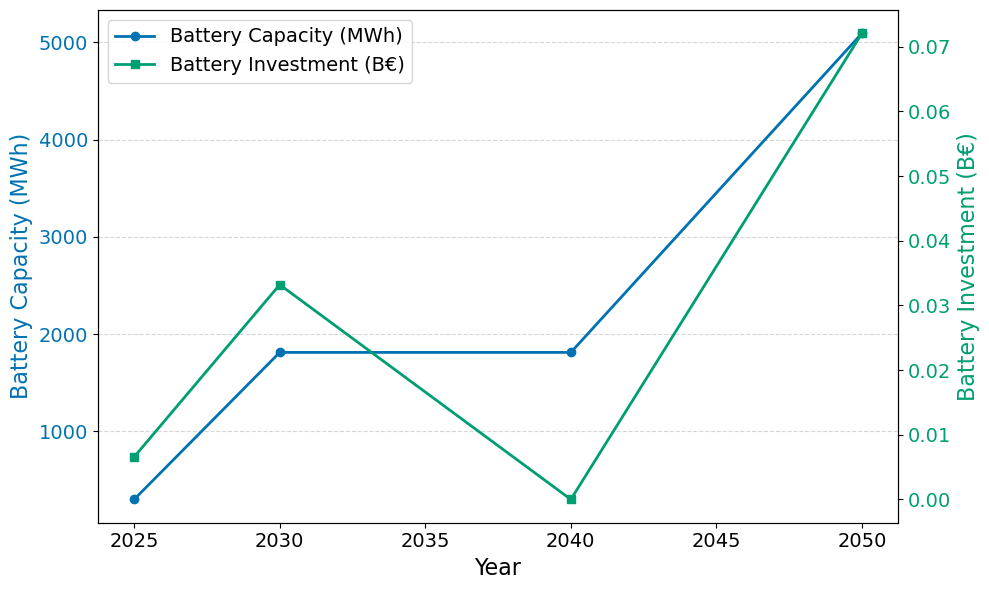

In [72]:
plot_battery_capacity_and_investment_dual_axis(
    battery_tables,
    case_label=display_names[0],  # Assuming first case is the one with batteries
    savefolder=batteries_figures_folder,
    color_capacity=category_colors["Invest Bat"],  # blue
    color_investment=category_colors[
        "Invest Tx"
    ],  # green (or use another color if you prefer)
)

In [73]:
def plot_battery_capacity_and_investment_bar_dual_axis(
    battery_tables: dict,
    case_label: str,
    savefolder: str = None,
    color_capacity: str = "#0072b2",  # blue (Invest Bat)
    color_investment: str = "#009e73",  # green (Invest Tx or pick preferred)
    fname: str = None,
):
    """
    Bar plot: battery energy capacity (MWh) and investment (Billion €) vs year, dual y-axis, for a single case.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import os

    # 1. Load table and filter for selected run
    bat_sum = battery_tables["battery_system_summary_by_year"].reset_index()
    sub = bat_sum[bat_sum["run"] == case_label].copy()

    # 2. X and values
    years = sub["year"].astype(int).values
    capacity = sub["capacity"].values
    investment = (sub["investment_cost"] / 1e9).values  # Billion €

    x = np.arange(len(years))
    bar_w = 0.35

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # 3. Bar: Capacity (left y-axis)
    cap_bars = ax1.bar(
        x - bar_w / 2,
        capacity,
        width=bar_w,
        color=color_capacity,
        edgecolor="k",
        label="Battery Capacity (MWh)",
    )
    ax1.set_xlabel("Year", fontsize=16)
    ax1.set_ylabel("Battery Capacity (MWh)", color=color_capacity, fontsize=16)
    ax1.tick_params(axis="y", labelcolor=color_capacity, labelsize=14)
    ax1.set_xticks(x)
    ax1.set_xticklabels(years, fontsize=14)
    ax1.tick_params(axis="x", labelsize=14)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)

    # 4. Bar: Investment (right y-axis)
    ax2 = ax1.twinx()
    inv_bars = ax2.bar(
        x + bar_w / 2,
        investment,
        width=bar_w,
        color=color_investment,
        edgecolor="k",
        label="Battery Investment (B€)",
    )
    ax2.set_ylabel("Battery Investment (B€)", color=color_investment, fontsize=16)
    ax2.tick_params(axis="y", labelcolor=color_investment, labelsize=14)

    # 5. Custom legend
    from matplotlib.patches import Patch

    legend_handles = [
        Patch(facecolor=color_capacity, edgecolor="k", label="Battery Capacity (MWh)"),
        Patch(
            facecolor=color_investment, edgecolor="k", label="Battery Investment (B€)"
        ),
    ]
    ax1.legend(
        legend_handles,
        ["Battery Capacity (MWh)", "Battery Investment (B€)"],
        fontsize=14,
        loc="upper left",
    )

    plt.tight_layout()
    plt.show()

    if savefolder:
        fname = fname or "battery_capacity_investment_bar_dual_axis.png"
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")

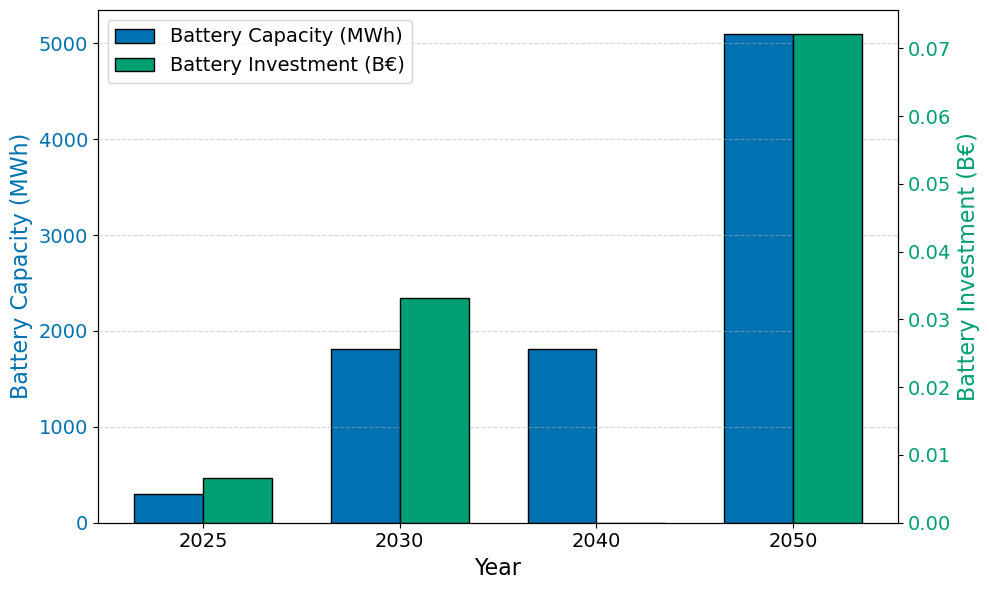

In [74]:
plot_battery_capacity_and_investment_bar_dual_axis(
    battery_tables,
    case_label=display_names[0],
    savefolder=batteries_figures_folder,
    color_capacity=category_colors["Invest Bat"],
    color_investment=category_colors["Invest Tx"],
)

In [75]:
battery_tables["battery_system_summary_by_year"]

year  num_buildout     capacity  investment_cost  cycles_per_year
run                                                                         
ramp004 0  2025             1   299.300981     6.572328e+06       203.822806
        1  2030             1  1811.348424     3.320294e+07       199.243651
        2  2040             0  1811.348424     0.000000e+00        26.071429
        3  2050             1  5093.209464     7.206614e+07       103.612992
ramp008 0  2025             1   399.380974     8.769977e+06       203.822290
        1  2030             1  1030.652089     1.386204e+07       156.142350
        2  2040             0  1030.652089     0.000000e+00        26.071429
        3  2050             1  7390.348138     1.396521e+08       131.402147
ramp012 0  2025             1    21.123842     4.638569e+05       203.822618
        1  2030             1    59.396717     8.404312e+05       169.104879
        2  2040             1   167.013656     2.363152e+06       147.494264
        3  2050             1  8320.383625     1.790392e+08       149.986214

In [76]:
df = battery_tables["battery_system_summary_by_year"]
df["investment_cost_per_capacity"] = df["investment_cost"] / df["capacity"]

print(df[["investment_cost", "capacity", "investment_cost_per_capacity"]])

           investment_cost     capacity  investment_cost_per_capacity
run                                                                  
ramp004 0     6.572328e+06   299.300981                  21958.924940
        1     3.320294e+07  1811.348424                  18330.507738
        2     0.000000e+00  1811.348424                      0.000000
        3     7.206614e+07  5093.209464                  14149.455417
ramp008 0     8.769977e+06   399.380974                  21958.924940
        1     1.386204e+07  1030.652089                  13449.771441
        2     0.000000e+00  1030.652089                      0.000000
        3     1.396521e+08  7390.348138                  18896.550687
ramp012 0     4.638569e+05    21.123842                  21958.924940
        1     8.404312e+05    59.396717                  14149.455417
        2     2.363152e+06   167.013656                  14149.455417
        3     1.790392e+08  8320.383625                  21518.147145


In [77]:
def plot_battery_new_capacity_and_investment_bar_dual_axis_from_extended(
    extended_tables: dict,
    case_label: str,
    savefolder: str = None,
    color_capacity: str = "#0072b2",  # blue (Invest Bat)
    color_investment: str = "#009e73",  # green (Invest Tx or pick preferred)
    fname: str = None,
):
    """
    Bar plot: new battery capacity (MWh) and investment (Billion €) per year, dual y-axis, for a single case.
    Uses extended_tables["extended_batteries"].
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import os

    # 1. Load and filter for selected run
    df = extended_tables["extended_batteries"].reset_index()
    sub = df[df["run"] == case_label].copy()

    # 2. Compute new capacity and investment per year
    # - new_capacity in MWh (already in that unit)
    # - investment: new_capacity / hour_capacity * capital_cost
    grouped = (
        sub.groupby("year")
        .apply(
            lambda d: pd.Series(
                {
                    "new_capacity_MWh": d["new_capacity"].sum(),
                    "investment_BEUR": (
                        (
                            d["new_capacity"] / d["hour_capacity"] * d["capital_cost"]
                        ).sum()
                    )
                    / 1e9,
                }
            )
        )
        .reset_index()
    )
    years = grouped["year"].astype(int).values
    new_capacity = grouped["new_capacity_MWh"].values
    investment = grouped["investment_BEUR"].values

    x = np.arange(len(years))
    bar_w = 0.35

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # 3. Bar: New Capacity (left y-axis)
    cap_bars = ax1.bar(
        x - bar_w / 2,
        new_capacity,
        width=bar_w,
        color=color_capacity,
        edgecolor="k",
        label="New Battery Capacity (MWh)",
    )
    ax1.set_xlabel("Year", fontsize=16)
    ax1.set_ylabel("New Battery Capacity (MWh)", color=color_capacity, fontsize=16)
    ax1.tick_params(axis="y", labelcolor=color_capacity, labelsize=14)
    ax1.set_xticks(x)
    ax1.set_xticklabels(years, fontsize=14)
    ax1.tick_params(axis="x", labelsize=14)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)

    # 4. Bar: Investment (right y-axis)
    ax2 = ax1.twinx()
    inv_bars = ax2.bar(
        x + bar_w / 2,
        investment,
        width=bar_w,
        color=color_investment,
        edgecolor="k",
        label="Battery Investment (B€)",
    )
    ax2.set_ylabel("Battery Investment (B€)", color=color_investment, fontsize=16)
    ax2.tick_params(axis="y", labelcolor=color_investment, labelsize=14)

    # 5. Custom legend
    from matplotlib.patches import Patch

    legend_handles = [
        Patch(
            facecolor=color_capacity, edgecolor="k", label="New Battery Capacity (MWh)"
        ),
        Patch(
            facecolor=color_investment, edgecolor="k", label="Battery Investment (B€)"
        ),
    ]
    ax1.legend(
        legend_handles,
        ["New Battery Capacity (MWh)", "Battery Investment (B€)"],
        fontsize=14,
        loc="upper left",
    )

    plt.tight_layout()
    plt.show()

    if savefolder:
        fname = fname or "battery_new_capacity_investment_bar_dual_axis_extended.png"
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")

C:\Users\tinus\AppData\Local\Temp\ipykernel_6596\2914058012.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


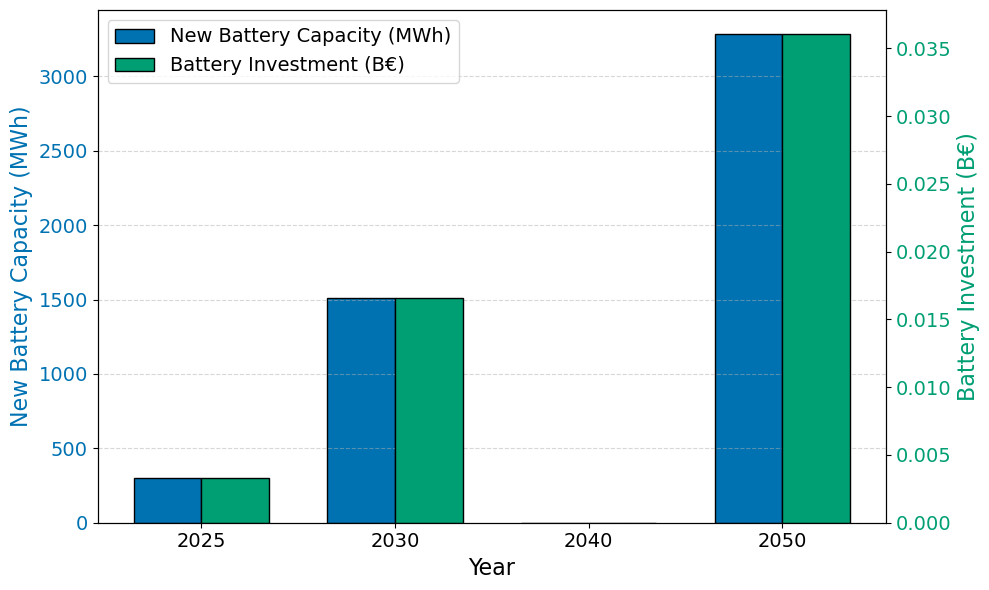

In [78]:
plot_battery_new_capacity_and_investment_bar_dual_axis_from_extended(
    extended_tables,
    case_label=display_names[0],
    savefolder=batteries_figures_folder,
    color_capacity=category_colors["Invest Bat"],
    color_investment=category_colors["Invest Tx"],
)

In [79]:
def plot_battery_new_capacity_and_investment_line_dual_axis_from_extended(
    extended_tables: dict,
    case_label: str,
    savefolder: str = None,
    color_capacity: str = "#0072b2",  # blue (Invest Bat)
    color_investment: str = "#009e73",  # green (Invest Tx or pick preferred)
    fname: str = None,
):
    """
    Line plot: new battery capacity (MWh) and investment (Billion €) per year, dual y-axis, for a single case.
    Uses extended_tables["extended_batteries"].
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import os

    # 1. Load and filter for selected run
    df = extended_tables["extended_batteries"].reset_index()
    sub = df[df["run"] == case_label].copy()

    # 2. Compute new capacity and investment per year
    grouped = (
        sub.groupby("year")
        .apply(
            lambda d: pd.Series(
                {
                    "new_capacity_MWh": d["new_capacity"].sum(),
                    "investment_BEUR": (
                        (
                            d["new_capacity"] / d["hour_capacity"] * d["capital_cost"]
                        ).sum()
                    )
                    / 1e9,
                }
            )
        )
        .reset_index()
    )
    years = grouped["year"].astype(int).values
    new_capacity = grouped["new_capacity_MWh"].values
    investment = grouped["investment_BEUR"].values

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # 3. Line: New Capacity (left y-axis)
    ax1.plot(
        years,
        new_capacity,
        marker="o",
        color=color_capacity,
        linewidth=2,
        label="New Battery Capacity (MWh)",
    )
    ax1.set_xlabel("Year", fontsize=16)
    ax1.set_ylabel("New Battery Capacity (MWh)", color=color_capacity, fontsize=16)
    ax1.tick_params(axis="y", labelcolor=color_capacity, labelsize=14)
    ax1.set_xticks(years)
    ax1.tick_params(axis="x", labelsize=14)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)

    # 4. Line: Investment (right y-axis)
    ax2 = ax1.twinx()
    ax2.plot(
        years,
        investment,
        marker="s",
        color=color_investment,
        linewidth=2,
        label="Battery Investment (B€)",
    )
    ax2.set_ylabel("Battery Investment (B€)", color=color_investment, fontsize=16)
    ax2.tick_params(axis="y", labelcolor=color_investment, labelsize=14)

    # 5. Legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax2.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=14, loc="upper left")

    plt.tight_layout()
    plt.show()

    if savefolder:
        fname = fname or "battery_new_capacity_investment_line_dual_axis_extended.png"
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")

C:\Users\tinus\AppData\Local\Temp\ipykernel_6596\4088430851.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


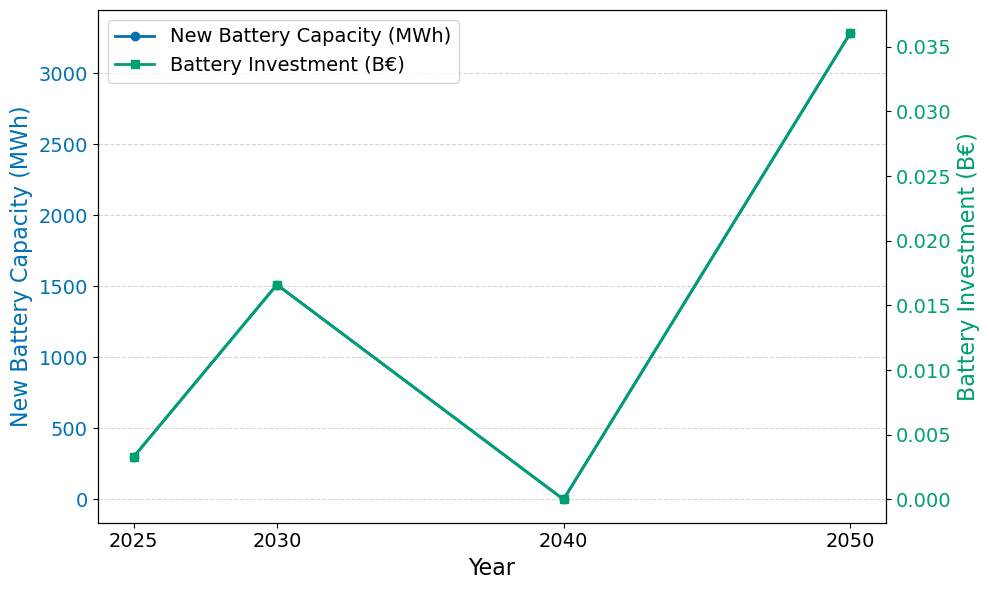

In [80]:
plot_battery_new_capacity_and_investment_line_dual_axis_from_extended(
    extended_tables,
    case_label=display_names[0],
    savefolder=batteries_figures_folder,
    color_capacity=category_colors["Invest Bat"],
    color_investment=category_colors["Invest Tx"],
)

In [81]:
def save_battery_new_capacity_and_investment_table_from_extended(
    extended_tables: dict,
    case_label: str,
    savefolder: str = None,
    fname: str = None,
):
    """
    Saves a table of new battery capacity (MWh) and investment (Billion €) per year for a single case,
    using extended_tables["extended_batteries"].
    """
    import os
    import pandas as pd

    # 1. Load and filter for selected run
    df = extended_tables["extended_batteries"].reset_index()
    sub = df[df["run"] == case_label].copy()

    # 2. Compute new capacity and investment per year
    grouped = (
        sub.groupby("year")
        .apply(
            lambda d: pd.Series(
                {
                    "New Capacity (MWh)": d["new_capacity"].sum(),
                    "Battery Investment (B€)": (
                        (
                            d["new_capacity"] / d["hour_capacity"] * d["capital_cost"]
                        ).sum()
                    )
                    / 1e9,
                }
            )
        )
        .reset_index()
    )
    grouped["year"] = grouped["year"].astype(int)

    # 3. Save as CSV
    if savefolder:
        fname = fname or "battery_new_capacity_investment_by_year_extended.csv"
        grouped.to_csv(os.path.join(savefolder, fname), index=False)

    return grouped  # For inspection/printing in notebook if desired

In [82]:
battery_summary_table = save_battery_new_capacity_and_investment_table_from_extended(
    extended_tables,
    case_label=display_names[0],
    savefolder=batteries_tables_folder,
)
battery_summary_table

C:\Users\tinus\AppData\Local\Temp\ipykernel_6596\786854873.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,year,New Capacity (MWh),Battery Investment (B€)
0,2025,299.300981,0.003286
1,2030,1512.047443,0.016601
2,2040,0.000000,0.000000
3,2050,3281.861040,0.036033


In [83]:
def plot_cycles_per_year_scenario_case_with_average(
    decision_variables_list: list[dict],
    week_weights: dict,
    scenario_colors: dict,
    case_labels: list[str],
    reference_cycle_mwh: float = 320,
    max_opacity: float = 1.0,
    min_opacity: float = 0.4,
    savefolder: str = None,
    fname: str = None,
):
    """
    Grouped bar chart of annual number of reference cycles (discharge/reference_cycle_mwh)
    by year, scenario, case, and average.
    If only one case, omits the case legend.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    import os
    import pandas as pd

    # Step 1: Compute cycles for each case
    all_cycles = []
    for i, dv in enumerate(decision_variables_list):
        df = (
            dv["battery_discharging"]
            .reset_index()
            .rename(columns={"value": "discharge"})
        )
        df["weight"] = df["week"].map(week_weights)
        df["annual_discharge"] = df["discharge"] * df["weight"]

        # Sum to annual discharge per scenario and year
        total = (
            df.groupby(["scenario", "year"])["annual_discharge"]
            .sum()
            .reset_index(name="annual_discharge")
        )
        total["cycles"] = total["annual_discharge"] / reference_cycle_mwh
        total["run"] = case_labels[i]
        all_cycles.append(total[["run", "year", "scenario", "cycles"]])

    df_all = pd.concat(all_cycles, ignore_index=True)

    years = sorted(df_all["year"].unique())
    n_cases = len(case_labels)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Step 2: For each year, pack scenario+case bars with "Average"
    for xi, year in enumerate(years):
        sub_year = df_all[df_all["year"] == year]
        scenarios = sorted(sub_year["scenario"].unique())
        # build dict of values per case & scenario
        vals = {
            case: {
                sc: (
                    sub_year[(sub_year["run"] == case) & (sub_year["scenario"] == sc)][
                        "cycles"
                    ].iloc[0]
                    if not sub_year[
                        (sub_year["run"] == case) & (sub_year["scenario"] == sc)
                    ].empty
                    else 0.0
                )
                for sc in scenarios
            }
            for case in case_labels
        }
        # Per-case average over scenarios (skip zero/NaN for averaging if you wish)
        for case in case_labels:
            arr = np.array(list(vals[case].values()))
            avg = arr.mean() if len(arr) > 0 else 0.0
            vals[case]["Average"] = avg

        levels = scenarios + ["Average"]
        n_lev = len(levels)
        bars = n_lev * n_cases
        total_width = 0.8
        bw = total_width / bars
        center = xi

        for li, lev in enumerate(levels):
            for ci, case in enumerate(case_labels):
                alpha = (
                    max_opacity
                    if n_cases == 1
                    else max_opacity
                    - (max_opacity - min_opacity) * (ci / (n_cases - 1))
                )
                offset = (li * n_cases + ci) - (bars - 1) / 2
                x = center + offset * bw
                h = vals[case][lev]
                color = (
                    "black" if lev == "Average" else scenario_colors.get(lev, "#777777")
                )
                ax.bar(
                    x,
                    h,
                    bw,
                    color=color,
                    alpha=alpha,
                    edgecolor="k",
                    label=case if (xi == 0 and li == 0) else None,
                )

    ax.set_xticks(range(len(years)))
    ax.set_xticklabels([str(y) for y in years], fontsize=12)
    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel(f"Number of {int(reference_cycle_mwh)} MWh Cycles", fontsize=16)

    # Scenario + Average legend
    all_scen = sorted(df_all["scenario"].unique())
    handles = [Patch(facecolor=scenario_colors[s], edgecolor="k") for s in all_scen]
    labels = all_scen[:]
    handles.append(Patch(facecolor="black", edgecolor="k"))
    labels.append("Average")
    leg1 = ax.legend(
        handles,
        labels,
        title="Scenario",
        title_fontsize=14,
        fontsize=12,
        loc="upper left",
        # bbox_to_anchor=(1.00, 1),
    )
    ax.add_artist(leg1)

    # Only show the case legend if there are multiple cases
    if n_cases > 1:
        case_handles = [
            Patch(
                facecolor="gray",
                edgecolor="k",
                alpha=(
                    max_opacity
                    if n_cases == 1
                    else max_opacity
                    - (max_opacity - min_opacity) * (ci / (n_cases - 1))
                ),
            )
            for ci in range(n_cases)
        ]
        ax.legend(
            case_handles,
            case_labels,
            title="Case",
            title_fontsize=14,
            fontsize=12,
            loc="upper left",
            # bbox_to_anchor=(1.0, 0.75),
        )

    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    if savefolder:
        fname = (
            fname
            or f"battery_cycles_{int(reference_cycle_mwh)}MWh_by_year_scenario_case_avg.png"
        )
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")

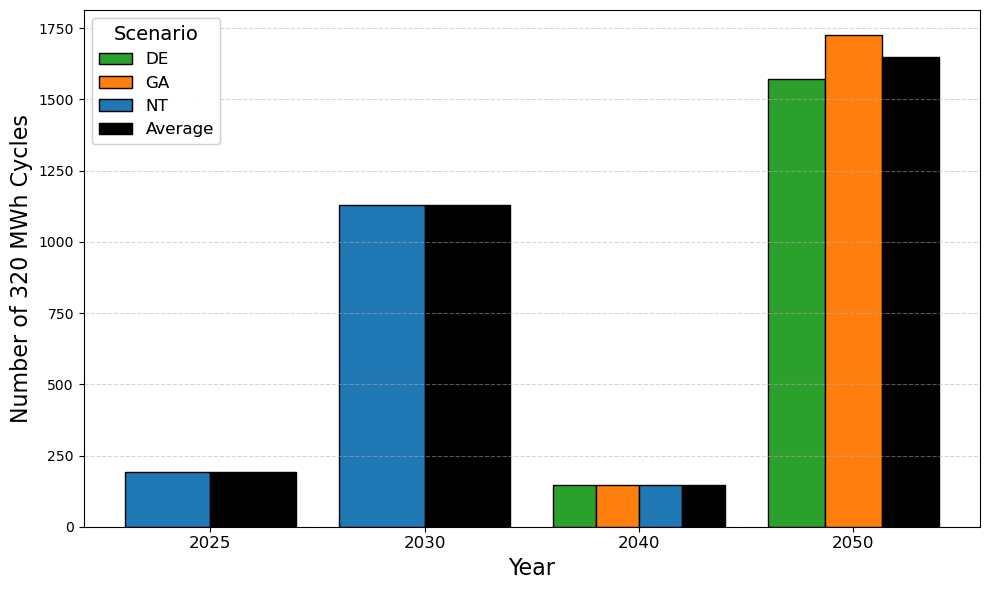

In [84]:
plot_cycles_per_year_scenario_case_with_average(
    [decision_variables_list[0]],
    week_weights,  # same dict for all
    scenario_colors,
    case_labels=[display_names[0]],
    reference_cycle_mwh=320,
    savefolder=batteries_figures_folder,
)

# Duals

In [85]:
duals_figures_folder = os.path.join(savefolder, "duals", "figures")
os.makedirs(duals_figures_folder, exist_ok=True)
duals_tables_folder = os.path.join(savefolder, "duals", "tables")
os.makedirs(duals_tables_folder, exist_ok=True)

In [86]:
for key, value in duals_tables.items():
    print(f"{key}:\n {value.head()}\n")
    print(f"======================================\n")

annual_lmp_overall_average:
            Unnamed: 0  Average_LMP_across_years_€/MWh
run                                                  
ramp004 0           0                       34.527415
ramp008 0           0                       34.092937
ramp012 0           0                       34.561736


annual_lmp_table:
            year         DE         GA         NT    Average
run                                                        
ramp004 0  2025        NaN        NaN  26.651286  26.651286
        1  2030        NaN        NaN  29.818418  29.818418
        2  2040  40.189642  34.675970  39.051254  37.972288
        3  2050  48.999606  38.335733        NaN  43.667670
ramp008 0  2025        NaN        NaN  26.075110  26.075110


dual_nonzero_summary:
                                       dual  total_duals  nonzero_duals  \
run                                                                      
ramp004 0     battery_charge_new_max_duals        51744            424   
        1    

In [87]:
def plot_lmp_by_year_scenario_cases(
    duals_tables: dict,
    case_labels: list[str],
    scenario_colors: dict,
    savefolder: str = None,
    max_opacity: float = 1.0,
    min_opacity: float = 0.4,
    fname: str = None,
):
    """
    Line chart of average LMP by year and scenario, for each case (run).
    """
    import matplotlib.pyplot as plt
    import os

    # Load annual_lmp_table and flatten MultiIndex
    lmp_df = duals_tables["annual_lmp_table"].copy().reset_index()
    scenarios = [c for c in lmp_df.columns if c not in ["run", "year", "Average"]]
    years = sorted(lmp_df["year"].unique())
    n_cases = len(case_labels)

    fig, ax = plt.subplots(figsize=(10, 6))

    # For each case/run, plot each scenario
    for i, case in enumerate(case_labels):
        sub = lmp_df[lmp_df["run"] == case]
        alpha = (
            max_opacity
            if n_cases == 1
            else max_opacity - (max_opacity - min_opacity) * (i / (n_cases - 1))
        )
        for scen in scenarios:
            if scen not in scenario_colors or scen not in sub.columns:
                continue
            ys = sub[scen].values
            xs = sub["year"].values
            label = f"{scen} ({case})"
            ax.plot(
                xs,
                ys,
                color=scenario_colors[scen],
                alpha=alpha,
                linewidth=2,
                marker="o",
                label=label,
            )

    # Axis labels
    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel("Average LMP (€/MWh)", fontsize=16)
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)

    # Legend: avoid duplicates
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(
        by_label.values(),
        by_label.keys(),
        fontsize=14,
        loc="best",
        title="Scenario (Case)",
        title_fontsize=14,
    )

    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    if savefolder:
        fname = fname or "lmp_by_year_scenario_cases.png"
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")

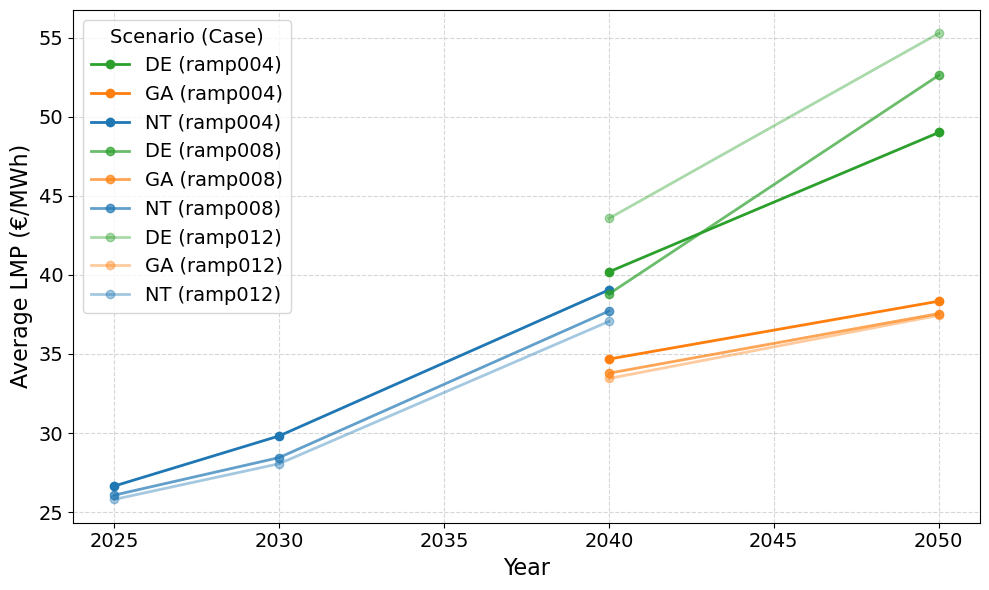

In [88]:
plot_lmp_by_year_scenario_cases(
    duals_tables=duals_tables,
    case_labels=display_names,
    scenario_colors=scenario_colors,
    savefolder=duals_figures_folder,  # <--- as discussed
)

In [89]:
duals_tables.keys()

dict_keys(['annual_lmp_overall_average', 'annual_lmp_table', 'dual_nonzero_summary', 'dual_year_scenario_summary', 'gap_wind_thermal_dual_summary', 'gen_extension_nonzero_duals', 'high_lmp_freq_table_62plus', 'lmp_bucket_frequencies', 'lmp_frequency_table', 'lmp_frequency_table_sorted', 'nodal_price_table', 'top_10_high_lmp_bins'])

In [90]:
duals_tables["lmp_bucket_frequencies"]

bucket      lower      upper  absolute  \
run                                                                
ramp004 0            non-binding  -0.000100   0.000100         0   
        1  gap_non-binding_solar   0.000100   0.009000         0   
        2                  solar   0.009000   0.011000         0   
        3         gap_solar_wind   0.011000   0.013500         0   
        4                   wind   0.013500   0.016500     18131   
        5       gap_wind_thermal   0.016500  49.857273       101   
        6                thermal  49.857273  62.172437     33105   
        7                  other        NaN        NaN       407   
ramp008 0            non-binding  -0.000100   0.000100         0   
        1  gap_non-binding_solar   0.000100   0.009000         0   
        2                  solar   0.009000   0.011000         0   
        3         gap_solar_wind   0.011000   0.013500         0   
        4                   wind   0.013500   0.016500     18992   
        5       gap_wind_thermal   0.016500  49.857273       126   
        6                thermal  49.857273  62.172437     32186   
        7                  other        NaN        NaN       440   
ramp012 0            non-binding  -0.000100   0.000100         0   
        1  gap_non-binding_solar   0.000100   0.009000         0   
        2                  solar   0.009000   0.011000        22   
        3         gap_solar_wind   0.011000   0.013500         0   
        4                   wind   0.013500   0.016500     19286   
        5       gap_wind_thermal   0.016500  49.857273       129   
        6                thermal  49.857273  62.172437     31856   
        7                  other        NaN        NaN       451   

           relative_percent  
run                          
ramp004 0          0.000000  
        1          0.000000  
        2          0.000000  
        3          0.000000  
        4         35.039811  
        5          0.195192  
        6         63.978432  
        7          0.786565  
ramp008 0          0.000000  
        1          0.000000  
        2          0.000000  
        3          0.000000  
        4         36.703772  
        5          0.243506  
        6         62.202381  
        7          0.850340  
ramp012 0          0.000000  
        1          0.000000  
        2          0.042517  
        3          0.000000  
        4         37.271954  
        5          0.249304  
        6         61.564626  
        7          0.871599

In [91]:
def plot_lmp_bucket_percentages_by_case(
    duals_tables: dict,
    case_labels: list[str],
    savefolder: str = None,
    max_opacity: float = 1.0,
    min_opacity: float = 0.4,
    fname: str = None,
    grey_cases: bool = False,  # Set to True for all-grey bars by case
):
    import matplotlib.pyplot as plt
    import numpy as np
    import os

    # Define colors
    color_solar = "#f9d002"
    color_on = "#235ebc"
    color_off = "#6895dd"
    wind_rgb = (
        (int(color_on[1:3], 16) + int(color_off[1:3], 16)) // 2,
        (int(color_on[3:5], 16) + int(color_off[3:5], 16)) // 2,
        (int(color_on[5:7], 16) + int(color_off[5:7], 16)) // 2,
    )
    color_wind = "#{:02x}{:02x}{:02x}".format(*wind_rgb)
    color_thermal = "#b20101"
    color_gap = "#888888"
    color_other = "black"
    color_grey = "#AAAAAA"

    freq_table = duals_tables["lmp_bucket_frequencies"].copy().reset_index()

    # Filter buckets with at least one nonzero count in any case
    mask_nonzero = freq_table.groupby("bucket")["absolute"].sum() > 0
    nonzero_buckets = mask_nonzero[mask_nonzero].index.tolist()
    freq_table = freq_table[freq_table["bucket"].isin(nonzero_buckets)]

    # Sort buckets by lower bound
    bucket_sorter = freq_table.groupby("bucket")["lower"].min().sort_values()
    sorted_buckets = bucket_sorter.index.tolist()

    # Labels/colors for buckets
    bucket_labels, bar_colors, bar_buckets = [], [], []
    for key in sorted_buckets:
        row = freq_table[freq_table["bucket"] == key].iloc[0]
        low, up = row["lower"], row["upper"]
        if key == "solar":
            bucket_labels.append(f"Solar\n{(low+up)/2:.3f}")
            bar_colors.append(color_solar)
        elif key == "wind":
            bucket_labels.append(f"Wind\n{(low+up)/2:.3f}")
            bar_colors.append(color_wind)
        elif key == "thermal":
            bucket_labels.append(f"Thermal\n{(low+up)/2:.2f}")
            bar_colors.append(color_thermal)
        elif str(key).startswith("gap"):
            bucket_labels.append(f"{low:.2f}-{up:.2f}")
            bar_colors.append(color_gap)
        elif str(key).startswith(">") or key == "other":
            bucket_labels.append(f">{freq_table['upper'].max():.2f} €/MWh")
            bar_colors.append(color_other)
        else:
            bucket_labels.append(f"{key}\n{(low+up)/2:.2f}")
            bar_colors.append(color_gap)
        bar_buckets.append(key)

    n_buckets = len(bucket_labels)
    n_cases = len(case_labels)
    x = np.arange(n_buckets)
    bar_w = 0.8 / n_cases

    fig, ax = plt.subplots(figsize=(10, 6))

    max_height = 0
    for ci, case in enumerate(case_labels):
        sub = freq_table[freq_table["run"] == case].set_index("bucket")
        alpha = (
            max_opacity
            if n_cases == 1
            else max_opacity - (max_opacity - min_opacity) * (ci / (n_cases - 1))
        )
        heights = [
            sub.loc[b, "relative_percent"] if b in sub.index else 0.0
            for b in bar_buckets
        ]
        # Color logic
        color_list = [color_grey] * n_buckets if grey_cases else bar_colors
        bars = ax.bar(
            x + (ci - (n_cases - 1) / 2) * bar_w,
            heights,
            bar_w,
            color=color_list,
            edgecolor="black",
            alpha=alpha,
            label=case,
        )
        max_height = max(max_height, max(heights))
        # Bold text
        for xi, h in enumerate(heights):
            if h > 0:
                ax.text(
                    x[xi] + (ci - (n_cases - 1) / 2) * bar_w,
                    h,  # increased to 3% for space
                    f"{h:.1f}%",
                    ha="center",
                    va="bottom",
                    fontsize=12,
                    fontweight="bold",
                    color="black",
                )

    # Y-axis with a little more margin
    ax.set_ylim(0, max_height * 1.05)
    ax.set_xlabel("LMP Bucket [€/MWh]", fontsize=16)
    ax.set_ylabel("Frequency (%)", fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(bucket_labels, fontsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Legend for cases
    case_handles = [
        Patch(
            facecolor="gray",
            edgecolor="k",
            alpha=(
                max_opacity
                if n_cases == 1
                else max_opacity - (max_opacity - min_opacity) * (ci / (n_cases - 1))
            ),
        )
        for ci in range(n_cases)
    ]
    ax.legend(
        case_handles,
        case_labels,
        title="Case",
        title_fontsize=14,
        fontsize=12,
        loc="upper right",
    )

    plt.tight_layout()
    plt.show()

    if savefolder:
        fname = fname or "lmp_bucket_percentages_by_case.png"
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")

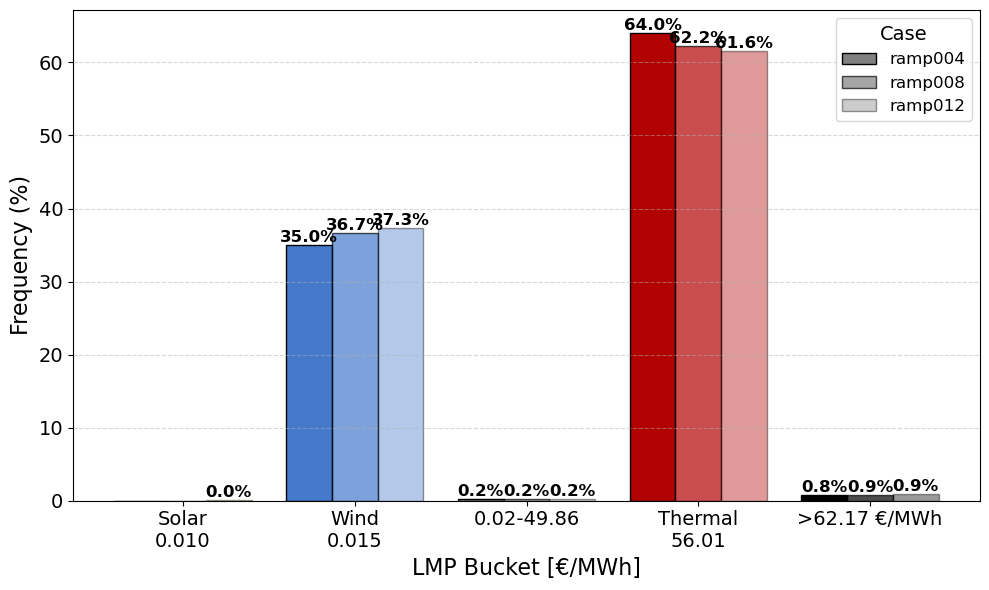

In [92]:
plot_lmp_bucket_percentages_by_case(
    duals_tables=duals_tables,
    case_labels=display_names,
    savefolder=duals_figures_folder,
)

In [93]:
def plot_lmp_bucket_percentages_by_year_scenario_case(
    duals_tables: dict[str, pd.DataFrame],
    case_labels: list[str],
    savefolder: str | None = None,
    max_opacity: float = 1.0,
    min_opacity: float = 0.4,
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    import os

    # --- Custom colors for LMP buckets ---
    color_solar = "#f9d002"
    color_on = "#235ebc"
    color_off = "#6895dd"
    wind_rgb = (
        (int(color_on[1:3], 16) + int(color_off[1:3], 16)) // 2,
        (int(color_on[3:5], 16) + int(color_off[3:5], 16)) // 2,
        (int(color_on[5:7], 16) + int(color_off[5:7], 16)) // 2,
    )
    color_wind = "#{:02x}{:02x}{:02x}".format(*wind_rgb)
    color_thermal = "#b20101"
    color_gap = "#888888"
    color_other = "black"

    # --- Case greys (as before) ---
    case_greys = [
        "#666666",  # Base
        "#bbbbbb",  # No Battery
        "#cccccc",  # For any additional cases
    ]

    # --- Combine tables, robustly get year/scenario if present in index ---
    freq_tables = []
    for (run, df), case in zip(
        duals_tables["lmp_bucket_frequencies"].groupby("run"), case_labels
    ):
        # If year/scenario are index, move them to columns
        df = df.copy()
        if isinstance(df.index, pd.MultiIndex):
            idx_names = df.index.names
            for idx in ["year", "scenario"]:
                if idx in idx_names and idx not in df.columns:
                    df[idx] = df.index.get_level_values(idx)
        elif "year" not in df.columns:
            # If not present at all, add dummy year/scenario (0)
            df["year"] = 0
            df["scenario"] = "NA"
        df["Case"] = case
        freq_tables.append(df.reset_index(drop=True))
    freq_table = pd.concat(freq_tables, ignore_index=True)

    # Defensive: If year/scenario still missing, add them as 0/NA
    for col in ("year", "scenario"):
        if col not in freq_table.columns:
            freq_table[col] = 0 if col == "year" else "NA"

    # Now get all unique (year, scenario) combinations
    combs = (
        freq_table[["year", "scenario"]]
        .drop_duplicates()
        .dropna()
        .sort_values(["year", "scenario"])
        .values
    )
    print(combs)

    for year, scenario in combs:
        print(f"Plotting for year={year}, scenario={scenario}")

        # Filter data for this year/scenario and nonzero buckets
        mask = (freq_table["year"] == year) & (freq_table["scenario"] == scenario)
        mask_nonzero = freq_table[mask].groupby("bucket")["absolute"].sum() > 0
        nonzero_buckets = mask_nonzero[mask_nonzero].index.tolist()
        ft = freq_table[mask & freq_table["bucket"].isin(nonzero_buckets)]

        # Sort buckets numerically (put "other" last)
        def bucket_sort_key(row):
            if pd.isna(row["lower"]):
                return 1e12
            return float(row["lower"])

        ft["sort_key"] = ft.apply(bucket_sort_key, axis=1)
        sorted_buckets = ft.sort_values("sort_key")["bucket"].unique()

        labels, bar_colors = [], []
        for b in sorted_buckets:
            sub = ft[ft["bucket"] == b].iloc[0]
            low, up = sub["lower"], sub["upper"]
            if b == "solar":
                labels.append(f"Solar\n{((low+up)/2):.3f}")
                bar_colors.append(color_solar)
            elif b == "wind":
                labels.append(f"Wind\n{((low+up)/2):.3f}")
                bar_colors.append(color_wind)
            elif b == "thermal":
                labels.append(f"Thermal\n{((low+up)/2):.2f}")
                bar_colors.append(color_thermal)
            elif isinstance(b, str) and b.startswith("gap"):
                labels.append(f"{low:.2f}-{up:.2f}")
                bar_colors.append(color_gap)
            elif b == "other":
                max_upper = ft[~ft["upper"].isna()]["upper"].max()
                labels.append(f">{max_upper:.2f} €/MWh")
                bar_colors.append(color_other)
            else:
                mid = (low + up) / 2 if not pd.isna(low) and not pd.isna(up) else 0
                labels.append(f"{b}\n{mid:.2f}")
                bar_colors.append(color_gap)

        n_cases = len(case_labels)
        n_buckets = len(sorted_buckets)
        bar_w = 0.8 / n_cases
        x = np.arange(n_buckets)

        fig, ax = plt.subplots(figsize=(10, 6))
        for ci, case in enumerate(case_labels):
            dfc = ft[ft["Case"] == case]
            heights = [
                (
                    dfc[dfc["bucket"] == b]["relative_percent"].values[0]
                    if b in dfc["bucket"].values
                    else 0
                )
                for b in sorted_buckets
            ]
            color = case_greys[ci % len(case_greys)]
            alpha = max_opacity if ci == 0 else min_opacity
            bars = ax.bar(
                x + (ci - (n_cases - 1) / 2) * bar_w,
                heights,
                bar_w,
                color=bar_colors,
                edgecolor="black",
                alpha=alpha,
                label=case,
                zorder=3,
            )
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        height + 0.03 * max(heights),
                        f"{height:.1f}%",
                        ha="center",
                        va="bottom",
                        fontsize=12,
                        fontweight="bold",
                        zorder=4,
                    )
        # Styling
        ax.set_xlabel("LMP Bucket [€/MWh]", fontsize=16)
        ax.set_ylabel("Frequency (%)", fontsize=16)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=14)
        ax.tick_params(axis="y", labelsize=14)
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        y_max = max(ft["relative_percent"].max() * 1.13, 1)
        ax.set_ylim(0, y_max)

        # Consistent legend for cases (grey rectangles)
        handles = [
            Patch(
                facecolor=case_greys[ci % len(case_greys)],
                edgecolor="black",
                alpha=max_opacity if ci == 0 else min_opacity,
            )
            for ci in range(n_cases)
        ]
        ax.legend(
            handles,
            case_labels,
            title="Case",
            title_fontsize=14,
            fontsize=12,
            loc="upper right",
        )

        plt.tight_layout()
        plt.show()

        # Save
        if savefolder:
            fname = f"lmp_bucket_percentages_{year}_{scenario}.png"
            fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")

[[0 'NA']]
Plotting for year=0, scenario=NA


C:\Users\tinus\AppData\Local\Temp\ipykernel_6596\1466994932.py:84: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ft["sort_key"] = ft.apply(bucket_sort_key, axis=1)


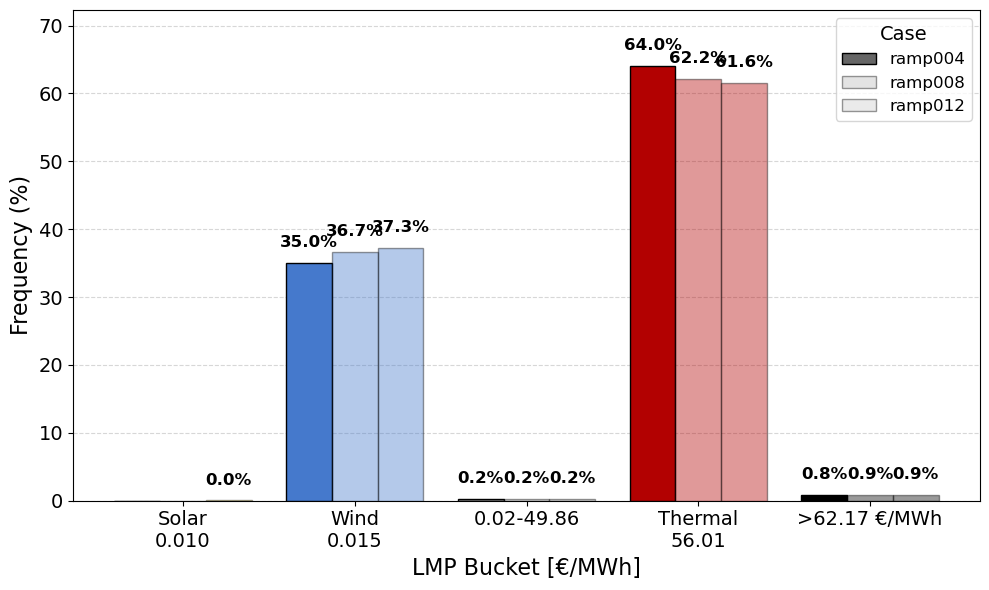

In [94]:
plot_lmp_bucket_percentages_by_year_scenario_case(
    duals_tables=duals_tables,
    case_labels=display_names,
    savefolder=duals_figures_folder,
)